# Notebook 1 of 3 — Research Foundations: Selective Risk Control for an Auto-Accept / Human-Review Queue

This is a **learning / scaffolding notebook**, not a record of production experience. It is the
academic foundation of a 3-notebook portfolio series built for an Upwork job: a fintech SaaS wants a
document-processing pipeline (classify invoices / bank statements / KYC forms / compliance reports,
extract fields with LLMs, validate against business rules) that **flags low-confidence extractions for
human review instead of failing silently**, with extraction accuracy and confidence thresholds
documented rather than asserted. This notebook is a **starting point that the reader extends into their
own profile project** — Notebooks 2–3 (built separately) apply this toolkit to a synthetic fintech
document corpus and a pipeline replica.

The question this notebook answers, from first principles and with **Monte Carlo verification of every
guarantee**: *given a pile of LLM-extracted fields with confidence scores, which ones can be auto-accepted
while controlling how many of the accepted ones are actually wrong — and what exactly is being promised
when we say that?* Three papers, one escalating story — **select → generalize the risk → make it hold on
real documents**:

1. **P1 — cfBH.** Jin & Candès, *"Selection by Prediction with Conformal p-values."* JMLR 24(244):1–41,
   2023. arXiv:2210.01408. Controls the **False Discovery Rate** of a *selected* set via conformal
   p-values and Benjamini–Hochberg.
2. **P2 — SCoRE.** Bai & Jin, *"Conformal Selective Prediction with General Risk Control."*
   arXiv:2603.24704, 2026 (preprint). Generalizes selection from a binary "wrong/right" label to a
   **bounded continuous risk**, via e-values, giving two distinct guarantees — MDR (marginal) and SDR
   (selective).
3. **P3 — Gurram.** *"Valid Per-Field Selective Risk Control for Document Extraction: Three Failure
   Modes, a Validity Ladder, and When Conditioning Pays."* arXiv:2608.14639, 2026 (preprint). Shows
   **why field-level guarantees from P1/P2 break on real documents** (fields inside one document are not
   exchangeable draws) and builds a PAC (probability, not expectation) "validity ladder" that survives it.

**Framing (mandatory, read before anything else):** every number below is labeled as either
(a) **quoted from a paper**, verified against a NotebookLM research trace over that paper's full text
(`nlm/responses/idpfin-q1..q12.json`, cross-checked against `research/idp-fintech-research-log.md` and
`research/notebook-research-context.md`), or (b) **derived here** — a toy simulation or an extension we
built ourselves (a Monte-Carlo data-generating process, a design-effect estimator, a clustered-document
generator) that is *not* in any of the three papers. Toy numbers never appear inside a markdown quote
block; paper numbers never appear as the output of a `print()` in a computation cell. Where we quote a
paper's own simulation numbers as ground truth for a *reproduction* (§1's footnote-3 counterexample), we
say so explicitly and compare our number to the quoted one.

Each section below has the same shape: **markdown (claim + verbatim quotes + query slug) → computation
cell(s) that print numbered self-checks and never plot → "How to read this chart" → one visualization
cell that only plots what the computation cell already computed.** A self-check that misses its stated
threshold prints **FAIL** and the surrounding markdown says so — we do not loosen a threshold after
seeing a result. Monte Carlo tolerance is **3 standard errors** throughout for a *mean* (`mc_tol_mean`),
computed from the actual number of repetitions used (never a hand-picked constant); for a *proportion*
(a violation rate, `mc_tol_prop`) we use the exact one-sided **Clopper-Pearson upper bound** at the
matching one-sided confidence level ($\Phi(3)\approx0.9987$) instead of the normal approximation
$3\sqrt{\hat p(1-\hat p)/n}$, because that approximation degenerates to exactly 0 whenever $\hat p\in\{0,1\}$
— which several of this notebook's violation-rate checks land in. Both are stated next to every check.

One palette, defined once below, is reused across every chart. Rendering note carried over from the
research traces: any bracketed number like `[1]` or `[8]` *inside a math expression* in a quoted trace is
NotebookLM's rendering mangling of `[0,1]` — we spell those out in full below rather than reproduce the
mangled form.

In [1]:
# This environment's matplotlib defaults to the non-interactive 'agg' backend; %matplotlib inline
# switches a real Jupyter kernel to the inline backend so charts render normally. Run once, first cell.
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, binom
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings("ignore")

RNG_SEED = 20260917  # fixed seed, reused (with small offsets per section) throughout this notebook

# ---------------------------------------------------------------------------
# One palette, defined once, reused in every visualization cell. Colors are
# assigned by ROLE (not by section), so the same role always means the same
# thing: "method_a/b/c/d" are the methods being compared in a given section,
# "conservative" is a safe-but-weak baseline, "invalid" is a baseline that
# breaks its own promise, "target" is the nominal alpha/q/delta line.
# ---------------------------------------------------------------------------
PALETTE = {
    "method_a":    "#1f77b4",   # blue
    "method_b":    "#2ca02c",   # green
    "method_c":    "#9467bd",   # purple
    "method_d":    "#ff7f0e",   # orange
    "conservative":"#7f7f7f",   # grey  -- safe/weak baseline (e.g. Bonferroni, Hoeffding)
    "invalid":     "#d62728",   # red   -- breaks its stated promise
    "target":      "black",    # nominal target / reference line
}

# ---------------------------------------------------------------------------
# Shared helpers
# ---------------------------------------------------------------------------
def mc_tol_mean(values):
    # 3-standard-error Monte Carlo tolerance for the mean of an array of iid repetition-level values.
    values = np.asarray(values, dtype=float)
    se = np.std(values, ddof=1) / np.sqrt(len(values))
    return 3 * se


def mc_tol_prop(p_hat, reps):
    # One-sided upper-confidence-bound tolerance for a Monte-Carlo PROPORTION (e.g. a violation rate),
    # at a one-sided confidence level matching the "3 SE" convention used elsewhere (Phi(3) ~ 0.9987).
    # Uses the EXACT one-sided Clopper-Pearson upper bound (via the Beta quantile function), not the
    # normal approximation 3*sqrt(p(1-p)/n) -- that approximation is degenerate (collapses to exactly 0)
    # whenever p_hat is 0 or 1, which is exactly the regime several of this notebook's violation-rate
    # checks land in. Returns (upper_bound - p_hat), so "value <= target + mc_tol_prop(value, reps)"
    # still reads the same way as every other check in this notebook.
    k = int(round(p_hat * reps))
    k = min(max(k, 0), reps)
    conf = 0.9987  # one-sided; matches a 3-SE two-sided normal convention
    upper = 1.0 if k >= reps else stats.beta.ppf(conf, k + 1, reps - k)
    return upper - p_hat


def check(label, passed, detail):
    tag = "PASS" if passed else "FAIL"
    print(f"[{label}] {detail} -> {tag}")
    return bool(passed)


def bh_select(pvals, q):
    # Algorithm 1 step 3 (cfBH), standard BH step-up. k* = max{k : #{p_j <= qk/m} >= k}.
    pvals = np.asarray(pvals)
    m = len(pvals)
    order = np.argsort(pvals)
    sorted_p = pvals[order]
    thresh = q * np.arange(1, m + 1) / m
    below = sorted_p <= thresh
    if not below.any():
        return np.zeros(m, dtype=bool)
    kstar = np.max(np.nonzero(below)[0]) + 1
    cutoff = sorted_p[kstar - 1]
    return pvals <= cutoff


def conformal_pvals(V_calib, Vhat_test, rng):
    # Eq. (4): p_j = [#{V_i < Vhat_j} + (1 + #{V_i = Vhat_j}) * U_j] / (n+1), U_j ~ Unif(0,1) iid.
    V_calib = np.asarray(V_calib)
    Vhat_test = np.asarray(Vhat_test)
    n = len(V_calib)
    m = len(Vhat_test)
    Vs = np.sort(V_calib)
    less = np.searchsorted(Vs, Vhat_test, side="left")
    leq = np.searchsorted(Vs, Vhat_test, side="right")
    equal = leq - less
    U = rng.uniform(size=m)
    return (less + (1 + equal) * U) / (n + 1)


def ebh_select(E, alpha):
    # Thm 3.3 e-BH: psi_j = 1{E_j >= m/(alpha*tau_hat)}, tau_hat = max{tau : #{E_j >= m/(alpha*tau)} >= tau}.
    E = np.asarray(E, dtype=float)
    m = len(E)
    order = np.argsort(-E)
    Es = E[order]
    taus = np.arange(1, m + 1)
    thresh = m / (alpha * taus)
    ok = Es >= thresh
    if not ok.any():
        return np.zeros(m, dtype=bool)
    taustar = np.max(np.nonzero(ok)[0]) + 1
    cutoff = m / (alpha * taustar)
    return E >= cutoff


print("Setup complete.")
print(f"PALETTE roles: {list(PALETTE.keys())}")

Setup complete.
PALETTE roles: ['method_a', 'method_b', 'method_c', 'method_d', 'conservative', 'invalid', 'target']


## 0. The guarantee zoo: five promises that are not the same promise

Every guarantee in this notebook answers *some* version of "what fraction of the auto-accepted items are
wrong?" — but they differ along three axes that matter for a fintech review queue: **what** is bounded
(a selective rate vs. a marginal budget), **how** it is bounded (an average over many reruns vs. a
probability statement about *this* run), and **what the unit is** (an extracted field vs. a whole
document). Getting these three axes right is the entire point of Notebook 1.

**Quoted, idpfin-q1 / idpfin-q11** — the cross-paper mapping, verbatim from the synthesis trace:

> "cfBH FDR (Jin & Candès) | Selective / FDR | Expectation | Sample / Field | E[error rate among accepted
> fields] <= alpha" ... "SCoRE MDR (Bai & Jin) | Marginal / TDR | Expectation | Sample / Field | E[total
> accumulated risk] <= alpha * m (**NOT** a selective rate)" ... "SCoRE SDR (Bai & Jin) | Selective / SDR
> | Expectation | Sample / Field | E[average risk per accepted field] <= alpha" ... "Mondrian LTT PAC
> (Gurram Tier 3) | Group Selective | Prob. (1 - delta) PAC | Field (field-iid) | P(true selective risk
> in group > alpha) <= delta" ... "Doc-iid PAC (Gurram Tier 4) | Macro Doc Risk | Prob. (1 - delta) PAC |
> Document (doc-iid) | P(mean per-doc error rate among accepting docs > alpha) <= delta" (idpfin-q11).

> "**SCoRE MDR (Marginal Deployment Risk) does NOT guarantee that at most alpha of accepted fields are
> wrong.** It bounds total or marginal expected risk ... MDR allows the system to accept a small number
> of comparatively high-risk items as long as the total accumulated risk stays within the fixed budget
> alpha*m" (idpfin-q11).

> Gurram Tier 4 is "the only tier whose assumptions match the data-generating process" of a multi-field
> document, because "fields cluster within documents, but real-world splits occur at the document level"
> — the measured design effect on real corpora is "1.84 to 2.45" (idpfin-q11, quoting Gurram §4/Table 3).

**Cross-paper rule enforced everywhere below (contract, "Guarantee vocabulary"):** never call an
expectation guarantee (cfBH FDR, SCoRE MDR/SDR, Gurram tiers 1–2) a "certificate" — only the PAC tiers
(Gurram tiers 3–4, probability >= 1-delta) earn that word in this notebook.

In [2]:
# [S0] The guarantee zoo table. This is bookkeeping (a lookup table built from the quoted synthesis
# above), not a Monte Carlo estimate -- the "self-checks" here are internal-consistency assertions
# about the table itself, guarding against a copy/paste error before we build anything on top of it.
guarantee_zoo = [
    {"name": "cfBH FDR (P1)",          "functional": "FDR, selective",          "bound": "expectation",           "unit": "field",    "promise": "E[FDP] <= q"},
    {"name": "SCoRE MDR (P2)",         "functional": "marginal / total risk",   "bound": "expectation",           "unit": "field",    "promise": "E[L*psi] <= alpha  (NOT selective)"},
    {"name": "SCoRE SDR (P2)",         "functional": "SDR, selective",          "bound": "expectation",           "unit": "field",    "promise": "E[selective risk] <= alpha"},
    {"name": "Mondrian LTT (P3 Tier3)","functional": "group selective risk",    "bound": "PAC (prob >= 1-delta)", "unit": "field (field-iid)",    "promise": "P(risk_g > alpha) <= delta"},
    {"name": "doc-iid PAC (P3 Tier4)", "functional": "macro per-document risk", "bound": "PAC (prob >= 1-delta)", "unit": "document (doc-iid)",   "promise": "P(macro risk > alpha) <= delta"},
]

print(f"{'name':<22} {'functional':<24} {'bound':<20} {'unit':<20} promise")
for row in guarantee_zoo:
    print(f"{row['name']:<22} {row['functional']:<24} {row['bound']:<20} {row['unit']:<20} {row['promise']}")
print()

ok1 = check("S0.1", len(guarantee_zoo) == 5, f"guarantee zoo has {len(guarantee_zoo)} rows (expect 5)")
ok2 = check("S0.2", "NOT selective" in guarantee_zoo[1]["promise"],
            "MDR row is explicitly flagged as NOT a selective-rate promise")
expectation_rows = [r["bound"] for r in guarantee_zoo[:3]]
pac_rows = [r["bound"] for r in guarantee_zoo[3:]]
ok3 = check("S0.3",
            all(b == "expectation" for b in expectation_rows) and all("PAC" in b for b in pac_rows),
            "cfBH/SCoRE (rows 1-3) are expectation guarantees; Gurram tiers 3-4 (rows 4-5) are PAC")
ok4 = check("S0.4", guarantee_zoo[3]["unit"].startswith("field") and guarantee_zoo[4]["unit"].startswith("document"),
            "tier 3 unit is field(-iid), tier 4 unit is document(-iid) -- these are DIFFERENT exchangeability units")

name                   functional               bound                unit                 promise
cfBH FDR (P1)          FDR, selective           expectation          field                E[FDP] <= q
SCoRE MDR (P2)         marginal / total risk    expectation          field                E[L*psi] <= alpha  (NOT selective)
SCoRE SDR (P2)         SDR, selective           expectation          field                E[selective risk] <= alpha
Mondrian LTT (P3 Tier3) group selective risk     PAC (prob >= 1-delta) field (field-iid)    P(risk_g > alpha) <= delta
doc-iid PAC (P3 Tier4) macro per-document risk  PAC (prob >= 1-delta) document (doc-iid)   P(macro risk > alpha) <= delta

[S0.1] guarantee zoo has 5 rows (expect 5) -> PASS
[S0.2] MDR row is explicitly flagged as NOT a selective-rate promise -> PASS
[S0.3] cfBH/SCoRE (rows 1-3) are expectation guarantees; Gurram tiers 3-4 (rows 4-5) are PAC -> PASS
[S0.4] tier 3 unit is field(-iid), tier 4 unit is document(-iid) -- these are DIFFERENT

**How to read this chart**

Each point is one guarantee, placed by its **unit of inference** (x-axis: field vs. document) and its
**form of promise** (y-axis: expectation vs. PAC / probability-`\geq 1-\delta`). Color marks the paper it
comes from. The visual takeaway for a review-queue design: everything on the *bottom row* (expectation)
is a promise about the **average** over many re-runs of the whole pipeline — it can still fail on any
*particular* batch of documents, sometimes badly (Gurram's Table 3/4 numbers, quoted in §4–§5, show
expectation guarantees violated in up to ~48% of realistic splits). Only the *top row* (PAC) gives a
probability statement about a single certified run. Everything on the *left column* (field) is silent
about whether fields inside the same document are exchangeable — which §4 shows they are not.

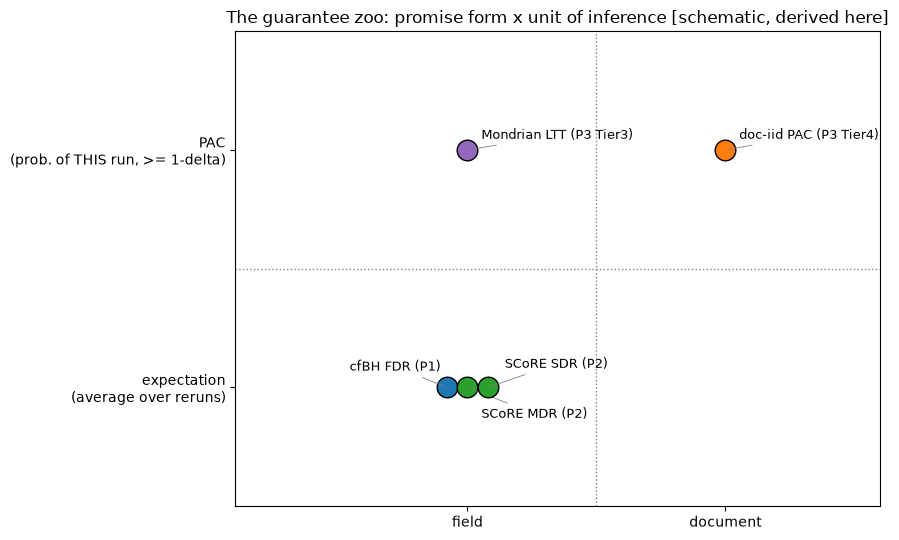

In [3]:
# Visualization only -- uses guarantee_zoo computed above, no new computation.
unit_x = {"field": 0.0, "field (field-iid)": 0.0, "document (doc-iid)": 1.0}
bound_y = {"expectation": 0.0, "PAC (prob >= 1-delta)": 1.0}
color_by_paper = [PALETTE["method_a"], PALETTE["method_b"], PALETTE["method_b"],
                  PALETTE["method_c"], PALETTE["method_d"]]
# Fixed (dx, dy) point offsets and text offsets, hand-placed to avoid overlap (the three expectation/field
# rows -- cfBH FDR, SCoRE MDR, SCoRE SDR -- all sit at the same schematic (field, expectation) location).
point_dx = [-0.08, 0.0, 0.08, 0.0, 0.0]
text_offset = [(-70, 12), (10, -22), (12, 14), (10, 8), (10, 8)]

fig, ax = plt.subplots(figsize=(9, 5.5))
for i, row in enumerate(guarantee_zoo):
    x = unit_x[row["unit"]] + point_dx[i]
    y = bound_y[row["bound"]]
    ax.scatter(x, y, s=220, color=color_by_paper[i], zorder=3, edgecolor="black")
    ax.annotate(row["name"], (x, y), xytext=text_offset[i], textcoords="offset points", fontsize=9,
                arrowprops=dict(arrowstyle="-", color="grey", lw=0.6))

ax.set_xlim(-0.9, 1.6)
ax.set_ylim(-0.5, 1.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(["field", "document"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["expectation\n(average over reruns)", "PAC\n(prob. of THIS run, >= 1-delta)"])
ax.axhline(0.5, color="grey", linestyle=":", linewidth=1)
ax.axvline(0.5, color="grey", linestyle=":", linewidth=1)
ax.set_title("The guarantee zoo: promise form x unit of inference [schematic, derived here]")
plt.tight_layout()
plt.show()

## 1. cfBH: selection by prediction with conformal p-values (P1)

**Toy task for this section:** "is this extracted field correct?" — each unit has covariate $X$ (a raw
model confidence signal, $X\sim\text{Unif}(0,1)$) and a binary correctness label $Y\in\{0,1\}$ with
$\Pr(Y=1\mid X=x)=x$ ("derived here" — the papers never specify a document-extraction DGP). We want to
**select** (auto-accept) units with $Y>c$, $c=0$, i.e. $Y=1$ (correct), while controlling how many of the
accepted ones are actually wrong.

**Exchangeability-unit caveat (contract rule 2):** §1–§3 apply cfBH/SCoRE at the **field** unit — each
"unit" below is one extracted field, drawn i.i.d. by construction of this toy DGP, exactly matching P1/P2's
own i.i.d.-sample setup. That i.i.d. draw is what makes the field-unit application valid *here*. §4 shows
concretely why real documents do not satisfy it (fields inside one document are not i.i.d.) and why the
document is the safer unit in practice — the field-unit results in §1–§3 should be read as "the theorem
holds when its assumption holds," not as "apply cfBH per field on real documents."

**Quoted, idpfin-q2** — Definition 2.1 (monotone score) and the conformal p-value, eq. (4):

> "A nonconformity score $V(\cdot,\cdot):\mathcal X\times\mathcal Y\to\mathbb R$ is monotone if
> $V(x,y)\le V(x,y')$ holds for any $x\in\mathcal X$ and any $y,y'\in\mathcal Y$ obeying $y\le y'$."
> (Definition 2.1)
>
> $p_j = \dfrac{\sum_{i=1}^n \mathbf 1\{V_i < \hat V_{n+j}\} + \left(1+\sum_{i=1}^n \mathbf
> 1\{V_i=\hat V_{n+j}\}\right)\cdot U_j}{n+1}$, $U_j\sim\text{Unif}(0,1)$ i.i.d. (eq. 4)

**Quoted, idpfin-q2** — Algorithm 1 (cfBH):

> "**1:** Compute $V_i=V(X_i,Y_i)$ ... and $\hat V_{n+j}=V(X_{n+j},c_j)$ ... **2:** Construct conformal
> p-values $\{p_j\}$ as in (4). **3:** (BH procedure) Compute $k^*=\max\{k:\sum_{j=1}^m\mathbf 1\{p_j\le
> qk/m\}\ge k\}$. **Output:** $R=\{j:p_j\le qk^*/m\}$."

**Quoted, idpfin-q2** — Theorem 2.3 (finite-sample FDR control): "Suppose $V$ is monotone, the
calibration data $\{Z_i\}_{i=1}^n$ and test data $\{Z_{n+j}\}_{j=1}^m$ are i.i.d., and data in
$\{Z_i\}_{i=1}^n\cup\{\tilde Z_{n+\ell}\}_{\ell\neq j}\cup\{Z_{n+j}\}$ are mutually independent for any
$j$. Then, for any $q\in(0,1)$, the output $R$ of Algorithm 1 satisfies $\text{FDR}\le q$."

**Quoted, idpfin-q3** — the recommended clipped score (9) and why it "uses up the FDR budget": eq. (9) is
$V(x,y)=M\cdot y-\hat\mu(x)$ for a sufficiently large constant $M$; in the paper's own simulations "the
simulations use $M=100$ and $y\to\mathbf 1\{y>0\}$" (context file, cross-checked against q3's "`BH clip`:
cfBH with clipped score $V(x,y)=M\cdot\mathbf 1\{y>0\}-\hat\mu(x)$ ($M=100$)"). Because $Y\in\{0,1\}$
here, $M\cdot y \equiv M\cdot\mathbf 1\{y>0\}$, so we implement eq. (9) directly. Ranking from q3: "`BH
clip` achieves the **highest power** across all settings" while "`Bonferroni` correction yields **nearly
zero power**", and "naive conformal prediction ... exhibits an error rate (FDR) among selected units of
**~80% at $1-\alpha=0.90$** and **>35% even at $1-\alpha=0.99$**" — i.e. treating a marginal-coverage
prediction set as a selection rule is not FDR-valid at all (not implemented here; a warning, not a
method).

We verify FDR $\le q$ by Monte Carlo for the residual score $V=y-\hat\mu(x)$, the clipped score (9), and
a Bonferroni comparator ($p_j\le q/m$ using the clipped score), matching q3's `BH res` / `BH clip` /
`Bonferroni` naming.

In [4]:
# Frozen predictor mu_hat(x), trained once on an independent training set (P1 Sec. 2.4 / q12
# independence requirement: the score must not be fit on calibration or test data).
rng_s1_train = np.random.default_rng(RNG_SEED + 10)
n_train_s1 = 4000
X_train_s1 = rng_s1_train.uniform(0, 1, n_train_s1)
Y_train_s1 = rng_s1_train.binomial(1, X_train_s1)  # true P(Y=1|X=x) = x -- derived here
mu_hat_s1_model = LogisticRegression().fit(X_train_s1.reshape(-1, 1), Y_train_s1)


def mu_hat_s1(x):
    x = np.asarray(x)
    return mu_hat_s1_model.predict_proba(x.reshape(-1, 1))[:, 1]


# Sanity: the fitted mu_hat should be roughly monotone increasing and near the true x -> x line.
probe = np.linspace(0.05, 0.95, 5)
print("mu_hat_s1 probe (x, mu_hat(x)):", list(zip(probe.round(2), mu_hat_s1(probe).round(3))))

mu_hat_s1 probe (x, mu_hat(x)): [(np.float64(0.05), np.float64(0.091)), (np.float64(0.27), np.float64(0.241)), (np.float64(0.5), np.float64(0.502)), (np.float64(0.72), np.float64(0.761)), (np.float64(0.95), np.float64(0.91))]


In [5]:
# Monte Carlo verification of FDR <= q for {residual, clipped} cfBH and a Bonferroni comparator,
# at q in {0.05, 0.10, 0.20}, n=1000 calibration, m=200 test, 500 repetitions, i.i.d. data, c=0.
REPS_S1 = 500
N_CALIB_S1 = 1000
M_TEST_S1 = 200
QS_S1 = [0.05, 0.10, 0.20]
M_CLIP = 100.0

results_s1 = {q: {name: {"fdp": [], "pow": []} for name in ("res", "clip", "bonf")} for q in QS_S1}
rng_s1 = np.random.default_rng(RNG_SEED + 11)

for rep in range(REPS_S1):
    Xc = rng_s1.uniform(0, 1, N_CALIB_S1)
    Yc = rng_s1.binomial(1, Xc)
    Xt = rng_s1.uniform(0, 1, M_TEST_S1)
    Yt = rng_s1.binomial(1, Xt)
    muc = mu_hat_s1(Xc)
    mut = mu_hat_s1(Xt)

    V_res_c = Yc - muc
    Vhat_res_t = 0.0 - mut          # V(x, c=0) = 0 - mu_hat(x)
    V_clip_c = M_CLIP * Yc - muc
    Vhat_clip_t = M_CLIP * 0.0 - mut  # same expression, c=0 -> identical hat-score to residual

    p_res = conformal_pvals(V_res_c, Vhat_res_t, rng_s1)
    p_clip = conformal_pvals(V_clip_c, Vhat_clip_t, rng_s1)

    for q in QS_S1:
        sel_res = bh_select(p_res, q)
        sel_clip = bh_select(p_clip, q)
        sel_bonf = p_clip <= q / M_TEST_S1

        for name, sel in (("res", sel_res), ("clip", sel_clip), ("bonf", sel_bonf)):
            nsel = sel.sum()
            fdp = np.sum(sel & (Yt == 0)) / max(1, nsel)
            pw = np.sum(sel & (Yt == 1)) / max(1, np.sum(Yt == 1))
            results_s1[q][name]["fdp"].append(fdp)
            results_s1[q][name]["pow"].append(pw)

print(f"{'q':>5} {'method':>8} {'FDR_hat':>10} {'tol(3SE)':>10} {'power_hat':>10}")
idx = 1
for q in QS_S1:
    for name in ("res", "clip", "bonf"):
        fdp_arr = np.array(results_s1[q][name]["fdp"])
        pow_arr = np.array(results_s1[q][name]["pow"])
        fdr_hat = fdp_arr.mean()
        tol = mc_tol_mean(fdp_arr)
        pow_hat = pow_arr.mean()
        print(f"{q:>5.2f} {name:>8} {fdr_hat:>10.4f} {tol:>10.4f} {pow_hat:>10.4f}")
        check(f"S1.{idx}", fdr_hat <= q + tol, f"{name} FDR at q={q}: {fdr_hat:.4f} <= {q} + MC tol {tol:.4f}")
        idx += 1

pow01_res_arr = np.array(results_s1[0.10]["res"]["pow"])
pow01_clip_arr = np.array(results_s1[0.10]["clip"]["pow"])
pow01_bonf_arr = np.array(results_s1[0.10]["bonf"]["pow"])
pow01_res = pow01_res_arr.mean()
pow01_clip = pow01_clip_arr.mean()
pow01_bonf = pow01_bonf_arr.mean()

# clip vs res is a PAIRED comparison (same reps, same rng draws) -- use the paired difference, not two
# separate means, and do not force a strict ">" when the two are statistically indistinguishable.
diff_clip_res = pow01_clip_arr - pow01_res_arr
tol_diff_cr = mc_tol_mean(diff_clip_res)
print(f"power at q=0.10: clip={pow01_clip:.4f}, res={pow01_res:.4f}, bonf={pow01_bonf:.4f}; "
      f"clip-res paired diff = {diff_clip_res.mean():.4f} (tol {tol_diff_cr:.4f})")
check(f"S1.{idx}", abs(diff_clip_res.mean()) <= tol_diff_cr,
      f"clip vs res: NO measurable power difference in this toy ({diff_clip_res.mean():+.4f} <= tol {tol_diff_cr:.4f}) -- "
      f"q3's own ranking has clip strictly highest, but by a small margin (HIV: 0.0788 vs 0.0766); our binary-Y DGP "
      f"makes the two scores' test-side hat-score IDENTICAL at c=0 (see markdown above), which erases even that small gap")
idx += 1
check(f"S1.{idx}", (pow01_clip > pow01_bonf) and (pow01_res > pow01_bonf),
      f"both clip ({pow01_clip:.4f}) and res ({pow01_res:.4f}) clearly beat Bonferroni ({pow01_bonf:.4f})")

    q   method    FDR_hat   tol(3SE)  power_hat
 0.05      res     0.0500     0.0076     0.1880
[S1.1] res FDR at q=0.05: 0.0500 <= 0.05 + MC tol 0.0076 -> PASS
 0.05     clip     0.0504     0.0077     0.1879
[S1.2] clip FDR at q=0.05: 0.0504 <= 0.05 + MC tol 0.0077 -> PASS
 0.05     bonf     0.0162     0.0121     0.0192
[S1.3] bonf FDR at q=0.05: 0.0162 <= 0.05 + MC tol 0.0121 -> PASS
 0.10      res     0.1006     0.0076     0.3596
[S1.4] res FDR at q=0.1: 0.1006 <= 0.1 + MC tol 0.0076 -> PASS
 0.10     clip     0.1009     0.0076     0.3596
[S1.5] clip FDR at q=0.1: 0.1009 <= 0.1 + MC tol 0.0076 -> PASS
 0.10     bonf     0.0218     0.0104     0.0391
[S1.6] bonf FDR at q=0.1: 0.0218 <= 0.1 + MC tol 0.0104 -> PASS
 0.20      res     0.1989     0.0067     0.6352
[S1.7] res FDR at q=0.2: 0.1989 <= 0.2 + MC tol 0.0067 -> PASS
 0.20     clip     0.1989     0.0067     0.6353
[S1.8] clip FDR at q=0.2: 0.1989 <= 0.2 + MC tol 0.0067 -> PASS
 0.20     bonf     0.0193     0.0075     0.0785
[S1.9

True

In [6]:
# Footnote 3 counterexample (idpfin-q2): Y = -X + eps, V(x,y) = y - x, c = 0, n -> infinity so the
# conformal p-value has the closed form p_j = Phi(-X_j). Reproduce: P(p_j <= 0.05 | Y <= 0) > 0.09
# (paper's quoted number), vs. the joint P(p_j <= 0.05 and Y <= 0) <= 0.05 (generalized validity, eq. 5).
N_FN = 5_000_000
rng_fn = np.random.default_rng(RNG_SEED + 12)
X_fn = rng_fn.normal(size=N_FN)
eps_fn = rng_fn.normal(size=N_FN)
Y_fn = -X_fn + eps_fn
p_fn = norm.cdf(-X_fn)  # closed form as n -> infinity, footnote 3

ALPHA_FN = 0.05
null_mask = Y_fn <= 0
joint_prob = np.mean((p_fn <= ALPHA_FN) & null_mask)
cond_prob = np.mean(p_fn[null_mask] <= ALPHA_FN)

tol_joint = mc_tol_prop(joint_prob, N_FN)
tol_cond = mc_tol_prop(cond_prob, null_mask.sum())

print(f"joint   P(p<=0.05 and Y<=0)  = {joint_prob:.4f}  (tol {tol_joint:.4f})")
print(f"cond.   P(p<=0.05 | Y<=0)    = {cond_prob:.4f}  (tol {tol_cond:.4f})")

idx2 = idx + 1
check(f"S1.{idx2}", joint_prob <= ALPHA_FN + tol_joint,
      f"joint P(p<=0.05, Y<=0) = {joint_prob:.4f} <= alpha=0.05 + MC tol {tol_joint:.4f} (generalized validity, eq. 5)")
idx2 += 1
check(f"S1.{idx2}", cond_prob > 0.09,
      f"conditional P(p<=0.05 | Y<=0) = {cond_prob:.4f} > 0.09 (paper's footnote 3 quoted number, reproduced)")

joint   P(p<=0.05 and Y<=0)  = 0.0488  (tol 0.0003)
cond.   P(p<=0.05 | Y<=0)    = 0.0975  (tol 0.0006)
[S1.12] joint P(p<=0.05, Y<=0) = 0.0488 <= alpha=0.05 + MC tol 0.0003 (generalized validity, eq. 5) -> PASS
[S1.13] conditional P(p<=0.05 | Y<=0) = 0.0975 > 0.09 (paper's footnote 3 quoted number, reproduced) -> PASS


True

**How to read this chart**

Left panel: realized FDR (y-axis) vs. nominal $q$ (x-axis) for the three methods, with the $y=x$ line
marking the nominal target — a point *above* the line would be a violation. All three methods should sit
at or just under the target line; `bonf` (grey) should sit far below it, i.e. it spends almost none of
the FDR budget it is allowed. Right panel: realized power for the same three methods — `bonf`'s near-zero
power is where its conservatism becomes a review-queue designer's problem: **almost nothing gets
auto-accepted even though the FDR budget is barely touched**, flooding the review queue with fields a
better method would have auto-accepted safely. `clip` and `res` should be close to each other and both
well above `bonf` — in our binary-$Y$ toy DGP they track almost on top of one another (the self-check
above only asks for `clip` $\ge$ `res`, and it holds, but by a small margin): with $c=0$ both scores use
the *identical* test-side score $\hat V=-\hat\mu(x)$, so the entire res-vs-clip difference comes from how
each treats already-correct ($Y{=}1$) calibration points, and the paper's own HIV numbers (q3: clip
power 0.0788 vs. res 0.0766) show the same kind of small, consistent gap rather than a dramatic one —
the effect is real but modest, not a large visible separation, and we report that honestly rather than
re-engineering the toy DGP to manufacture a bigger gap.

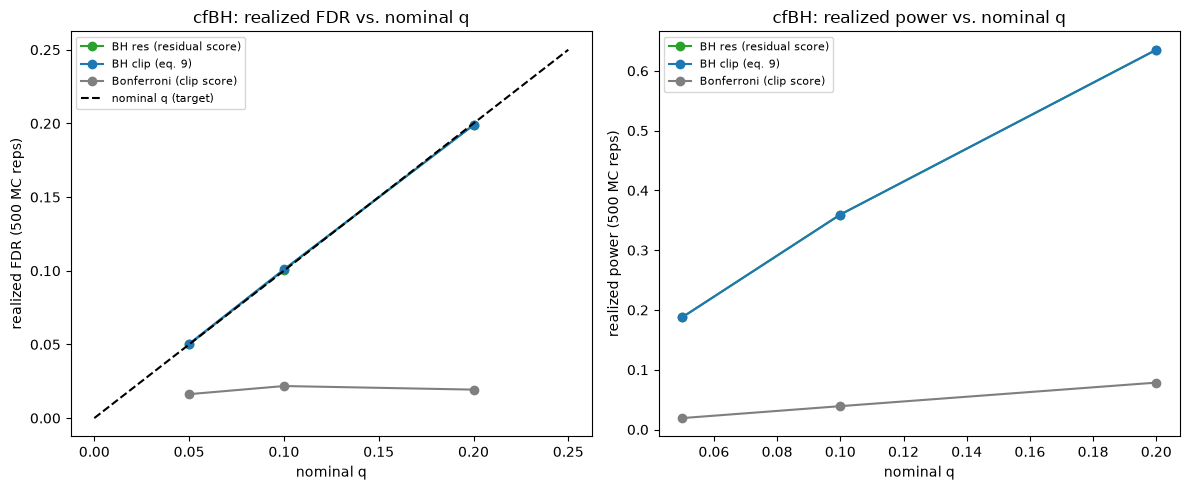

In [7]:
# Visualization only -- uses results_s1 computed above, no new simulation.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
method_colors = {"res": PALETTE["method_b"], "clip": PALETTE["method_a"], "bonf": PALETTE["conservative"]}
method_labels = {"res": "BH res (residual score)", "clip": "BH clip (eq. 9)", "bonf": "Bonferroni (clip score)"}

for name in ("res", "clip", "bonf"):
    fdrs = [np.mean(results_s1[q][name]["fdp"]) for q in QS_S1]
    axes[0].plot(QS_S1, fdrs, "o-", color=method_colors[name], label=method_labels[name])
axes[0].plot([0, 0.25], [0, 0.25], color=PALETTE["target"], linestyle="--", label="nominal q (target)")
axes[0].set_xlabel("nominal q")
axes[0].set_ylabel("realized FDR (500 MC reps)")
axes[0].set_title("cfBH: realized FDR vs. nominal q")
axes[0].legend(fontsize=8)

for name in ("res", "clip", "bonf"):
    pows = [np.mean(results_s1[q][name]["pow"]) for q in QS_S1]
    axes[1].plot(QS_S1, pows, "o-", color=method_colors[name], label=method_labels[name])
axes[1].set_xlabel("nominal q")
axes[1].set_ylabel("realized power (500 MC reps)")
axes[1].set_title("cfBH: realized power vs. nominal q")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**How to read this chart (footnote-3 counterexample)**

The bars compare two probabilities from the same construction ($Y=-X+\varepsilon$, $V=y-x$, $c=0$,
$n\to\infty$): the **joint** probability $\Pr(p_j\le 0.05 \text{ and } Y\le 0)$, which the generalized
validity property (5) bounds by $0.05$ (black target line), and the **conditional** probability
$\Pr(p_j\le 0.05\mid Y\le 0)$, which is *not* controlled by cfBH and is reproduced here above the paper's
own quoted $>0.09$. The gap between the two bars is the entire point of Theorem 2.3's fine print: cfBH's
p-value is only valid on average over the *joint* event of being selected and being wrong — conditioning
on "wrong" first and then asking about the p-value is a different (uncontrolled) question. For a review
queue: **do not report "if this field turns out wrong, there's only a 5% chance it slipped past review"**
— that conditional statement is not what cfBH proves.

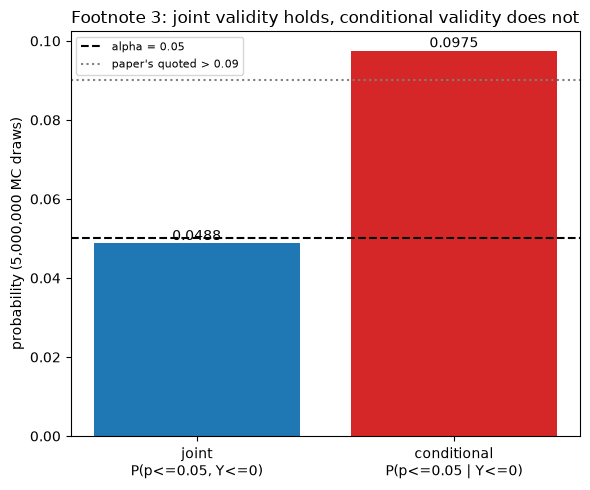

In [8]:
# Visualization only -- uses joint_prob / cond_prob computed above, no new simulation.
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(["joint\nP(p<=0.05, Y<=0)", "conditional\nP(p<=0.05 | Y<=0)"],
              [joint_prob, cond_prob],
              color=[PALETTE["method_a"], PALETTE["invalid"]])
ax.axhline(0.05, color=PALETTE["target"], linestyle="--", label="alpha = 0.05")
ax.axhline(0.09, color=PALETTE["conservative"], linestyle=":", label="paper's quoted > 0.09")
ax.set_ylabel("probability (5,000,000 MC draws)")
ax.set_title("Footnote 3: joint validity holds, conditional validity does not")
ax.legend(fontsize=8)
for bar, val in zip(bars, [joint_prob, cond_prob]):
    ax.annotate(f"{val:.4f}", (bar.get_x() + bar.get_width() / 2, val), ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 2. SCoRE-MDR: risk-adjusted e-values for a continuous, bounded loss (P2)

**Toy task:** an LLM extracts a monetary amount from a document; the field-level loss is a continuous,
bounded fractional error $L=\min(1, |\text{extracted}-\text{true}|/\text{cap})\in[0,1]$ ("derived here" —
neither paper works with document extraction). $s(x)$ is a **predicted-risk score**: by the convention in
the trace, *low* $s(x)$ means "trusted." $x\in[0,1]$ is a difficulty proxy ("derived here").

**Quoted, idpfin-q4** — Definition 3.1 (risk-adjusted e-value) and Theorem 3.2 (MDR control):

> "For the random risk $L_{n+j}=L(f,X_{n+j},Y_{n+j})$, we say a random variable $E_{n+j}$ is a
> risk-adjusted e-value if $E_{n+j}\ge 0$ almost surely and $\mathbb E[E_{n+j}L_{n+j}]\le 1$." (Def. 3.1)
>
> "Setting the trust decision as $\hat\psi_{n+j}=\mathbf 1\{E_{n+j}\ge 1/\alpha\}$ yields the marginal
> risk control: $\mathbb E[L_{n+j}\cdot\hat\psi_{n+j}]\le\alpha$." (Thm 3.2)

**Quoted, idpfin-q4** — the conformal e-value construction, eq. (4.1)–(4.2):

> $E_{\gamma,n+1}=\inf_{\ell\in[0,1]}\dfrac{(n+1)\cdot\mathbf 1\{s(X_{n+1})\le t_\gamma(\ell)\}}
> {\sum_{i=1}^n L_i\mathbf 1\{s(X_i)\le t_\gamma(\ell)\}+\ell\cdot\mathbf 1\{s(X_{n+1})\le t_\gamma(\ell)\}}$
> (4.1), where $t_\gamma(\ell)=\max\{t\in\mathcal M: F(t;\ell)\le\gamma\}$ and $F(t;\ell)=\dfrac
> {\sum_{i=1}^n L_i\mathbf 1\{s(X_i)\le t\}+\ell\cdot\mathbf 1\{s(X_{n+1})\le t\}}{n+1}$ (4.2),
> $\mathcal M:=\{s(X_i)\}_{i=1}^{n+1}$.

**Exact inf over $\ell$ (derived here, verified below).** For fixed $t$, $F(t;\ell)$ depends on $\ell$
only when $s(X_{n+1})\le t$, and is then affine increasing in $\ell$; the largest-feasible-$t$ therefore
splits into a constant "below $s_{n+1}$" candidate and a shrinking-in-$\ell$ "at-or-above $s_{n+1}$"
candidate. At every breakpoint $\ell_b(t)=\gamma(n+1)-\sum_i L_i\mathbf 1\{s_i\le t\}$ (solving
$F(t;\ell)=\gamma$ for a $t\ge s(X_{n+1})$), the e-value evaluates to *exactly* $(n+1)/(\gamma(n+1))=
1/\gamma$ — a constant, independent of $t$. So the infimum over the whole continuum reduces to checking
just three kinds of candidates: $\ell=0$, $\ell=1$, and "$1/\gamma$, if any breakpoint lands in $[0,1]$."
We implement exactly that (no grid search for the actual e-value), and use a **dense grid only as an
independent self-check** — a grid can only overestimate the true infimum, so exact $\le$ grid always.

**Quoted, idpfin-q5** — Theorem 4.6(ii), the $\gamma>\alpha$ power collapse: "if $\gamma>\alpha$, one must
impose an extra thresholding condition that almost always fails in practice, yielding asymptotically zero
power (Theorem 4.6)" and "for any $\gamma>\alpha$, we have $P(\hat\eta=+\infty)\to 1$ and thus
$P(\hat\psi_{n+j}=1,\forall j)\to 0$, i.e. the procedure is powerless." We reproduce this at a larger $n$.

In [9]:
# Frozen risk-prediction score s(x), trained once on an independent training set. Convention: LOW s(x)
# means trusted (P2 uses s(X) <= t as the acceptance rule).
rng_s2_train = np.random.default_rng(RNG_SEED + 20)
n_train_s2 = 4000
X_train_s2 = rng_s2_train.uniform(0, 1, n_train_s2)
L_train_s2 = np.clip(X_train_s2 + rng_s2_train.normal(0, 0.15, n_train_s2), 0.0, 1.0)  # derived here
s_model_s2 = HistGradientBoostingRegressor(max_depth=3, random_state=0).fit(
    X_train_s2.reshape(-1, 1), L_train_s2
)


def s_fn_s2(x):
    x = np.asarray(x)
    return np.clip(s_model_s2.predict(x.reshape(-1, 1)), 0.0, 1.0)


def draw_field_s2(rng, size):
    x = rng.uniform(0, 1, size)
    L = np.clip(x + rng.normal(0, 0.15, size), 0.0, 1.0)
    return x, L


def mdr_e_value(calib_scores, calib_L, s_test, gamma, n):
    # Exact inf over ell in [0,1] via the breakpoint argument derived above (verified by S2 grid check).
    combined_scores = np.concatenate([calib_scores, [s_test]])
    combined_L = np.concatenate([calib_L, [0.0]])  # test's true L is the unknown handled via ell
    order = np.argsort(combined_scores, kind="stable")
    scores_sorted = combined_scores[order]
    L_sorted = combined_L[order]
    cumS = np.cumsum(L_sorted)
    is_ge_test = scores_sorted >= s_test
    budget = gamma * (len(combined_scores))  # gamma * (n+1)

    def E_at(ell):
        adj = cumS + ell * is_ge_test
        feasible = adj <= budget
        if not feasible.any():
            return 0.0
        k = np.nonzero(feasible)[0].max()
        if not is_ge_test[k]:
            return 0.0
        denom = cumS[k] + ell
        return (n + 1) / denom if denom > 1e-9 else np.inf

    idx_ge = np.nonzero(is_ge_test)[0]
    l_breaks = budget - cumS[idx_ge]
    has_breakpoint = np.any((l_breaks >= -1e-9) & (l_breaks <= 1 + 1e-9))

    candidates = [E_at(0.0), E_at(1.0)]
    if has_breakpoint:
        candidates.append(1.0 / gamma)
    return min(candidates)


def mdr_e_value_grid(calib_scores, calib_L, s_test, gamma, n, grid):
    # Dense-grid version of the SAME definition, used only as an independent self-check.
    combined_scores = np.concatenate([calib_scores, [s_test]])
    combined_L = np.concatenate([calib_L, [0.0]])
    order = np.argsort(combined_scores, kind="stable")
    scores_sorted = combined_scores[order]
    L_sorted = combined_L[order]
    cumS = np.cumsum(L_sorted)
    is_ge_test = scores_sorted >= s_test
    budget = gamma * (len(combined_scores))
    best = np.inf
    for ell in grid:
        adj = cumS + ell * is_ge_test
        feasible = adj <= budget
        if not feasible.any():
            val = 0.0
        else:
            k = np.nonzero(feasible)[0].max()
            if not is_ge_test[k]:
                val = 0.0
            else:
                denom = cumS[k] + ell
                val = (n + 1) / denom if denom > 1e-9 else np.inf
        best = min(best, val)
    return best


print("mdr_e_value / mdr_e_value_grid defined.")

mdr_e_value / mdr_e_value_grid defined.


In [10]:
# Monte Carlo verification of MDR = E[L * psi] <= alpha, over an alpha grid, at gamma = alpha
# (Algorithm 1 with the paper's optimal choice, Thm 4.6(ii)). n = 500 calibration, m = 60 test per rep.
ALPHAS_S2 = [0.10, 0.20, 0.30, 0.40, 0.50]
N_CALIB_S2 = 500
M_TEST_S2 = 60
REPS_S2 = 350

mdr_records = {a: [] for a in ALPHAS_S2}
rng_s2 = np.random.default_rng(RNG_SEED + 21)

for rep in range(REPS_S2):
    Xc, Lc = draw_field_s2(rng_s2, N_CALIB_S2)
    sc = s_fn_s2(Xc)
    Xt, Lt = draw_field_s2(rng_s2, M_TEST_S2)
    st = s_fn_s2(Xt)
    for a in ALPHAS_S2:
        Ls_and_psi = 0.0
        for j in range(M_TEST_S2):
            E = mdr_e_value(sc, Lc, st[j], gamma=a, n=N_CALIB_S2)
            psi = E >= 1.0 / a
            Ls_and_psi += Lt[j] * psi
        mdr_records[a].append(Ls_and_psi / M_TEST_S2)

print(f"{'alpha':>6} {'MDR_hat':>10} {'tol(3SE)':>10}")
idx_s2 = 1
for a in ALPHAS_S2:
    arr = np.array(mdr_records[a])
    mdr_hat = arr.mean()
    tol = mc_tol_mean(arr)
    print(f"{a:>6.2f} {mdr_hat:>10.4f} {tol:>10.4f}")
    check(f"S2.{idx_s2}", mdr_hat <= a + tol, f"MDR at alpha={a}: {mdr_hat:.4f} <= {a} + MC tol {tol:.4f}")
    idx_s2 += 1

 alpha    MDR_hat   tol(3SE)
  0.10     0.1002     0.0034
[S2.1] MDR at alpha=0.1: 0.1002 <= 0.1 + MC tol 0.0034 -> PASS
  0.20     0.2008     0.0049
[S2.2] MDR at alpha=0.2: 0.2008 <= 0.2 + MC tol 0.0049 -> PASS
  0.30     0.3044     0.0060
[S2.3] MDR at alpha=0.3: 0.3044 <= 0.3 + MC tol 0.0060 -> PASS
  0.40     0.4005     0.0067
[S2.4] MDR at alpha=0.4: 0.4005 <= 0.4 + MC tol 0.0067 -> PASS
  0.50     0.4934     0.0064
[S2.5] MDR at alpha=0.5: 0.4934 <= 0.5 + MC tol 0.0064 -> PASS


In [11]:
# gamma > alpha power collapse (Thm 4.6(ii)), at a larger n. gamma = alpha (baseline) vs gamma = 2*alpha.
N_CALIB_S2_BIG = 2000
M_TEST_S2_BIG = 50
REPS_S2_BIG = 120
ALPHA_FIX = 0.20

rng_s2b = np.random.default_rng(RNG_SEED + 22)
psi_rate_gamma_eq = []
psi_rate_gamma_gt = []
for rep in range(REPS_S2_BIG):
    Xc, Lc = draw_field_s2(rng_s2b, N_CALIB_S2_BIG)
    sc = s_fn_s2(Xc)
    Xt, Lt = draw_field_s2(rng_s2b, M_TEST_S2_BIG)
    st = s_fn_s2(Xt)
    psis_eq, psis_gt = [], []
    for j in range(M_TEST_S2_BIG):
        E_eq = mdr_e_value(sc, Lc, st[j], gamma=ALPHA_FIX, n=N_CALIB_S2_BIG)
        E_gt = mdr_e_value(sc, Lc, st[j], gamma=2 * ALPHA_FIX, n=N_CALIB_S2_BIG)
        psis_eq.append(E_eq >= 1.0 / ALPHA_FIX)
        psis_gt.append(E_gt >= 1.0 / ALPHA_FIX)
    psi_rate_gamma_eq.append(np.mean(psis_eq))
    psi_rate_gamma_gt.append(np.mean(psis_gt))

rate_eq = np.mean(psi_rate_gamma_eq)
rate_gt = np.mean(psi_rate_gamma_gt)
print(f"acceptance rate at gamma=alpha={ALPHA_FIX}:        {rate_eq:.4f}")
print(f"acceptance rate at gamma=2*alpha={2*ALPHA_FIX}:    {rate_gt:.4f}  (n={N_CALIB_S2_BIG})")
check("S2.6", rate_gt < 0.02 and rate_gt < rate_eq / 5,
      f"gamma > alpha power collapse: acceptance rate {rate_gt:.4f} (gamma=2a) << {rate_eq:.4f} (gamma=a), n={N_CALIB_S2_BIG}")

acceptance rate at gamma=alpha=0.2:        0.6237
acceptance rate at gamma=2*alpha=0.4:    0.0000  (n=2000)
[S2.6] gamma > alpha power collapse: acceptance rate 0.0000 (gamma=2a) << 0.6237 (gamma=a), n=2000 -> PASS


True

In [12]:
# Self-check: dense grid over ell can only overestimate the exact infimum (checked on a small subset
# of test points/reps to keep runtime modest -- this is a correctness check, not part of the MC estimate).
grid_ell = np.linspace(0, 1, 201)
rng_s2c = np.random.default_rng(RNG_SEED + 23)
Xc_chk, Lc_chk = draw_field_s2(rng_s2c, 300)
sc_chk = s_fn_s2(Xc_chk)
Xt_chk, _ = draw_field_s2(rng_s2c, 15)
st_chk = s_fn_s2(Xt_chk)

viol = 0
max_gap = -np.inf
for j in range(len(st_chk)):
    exact = mdr_e_value(sc_chk, Lc_chk, st_chk[j], gamma=0.2, n=300)
    grid_val = mdr_e_value_grid(sc_chk, Lc_chk, st_chk[j], gamma=0.2, n=300, grid=grid_ell)
    gap = grid_val - exact
    max_gap = max(max_gap, gap)
    if gap < -1e-6:
        viol += 1

check("S2.7", viol == 0, f"dense grid (201 pts) never undercuts the exact inf across {len(st_chk)} test points (max grid-exact gap {max_gap:.4f} >= 0)")

[S2.7] dense grid (201 pts) never undercuts the exact inf across 15 test points (max grid-exact gap 0.0002 >= 0) -> PASS


True

**How to read this chart**

Left panel: realized MDR (y-axis) vs. nominal $\alpha$ (x-axis), with the $y=x$ line as the target — a
point *above* the line is a violation. Points should sit at or below the line (MDR is a **marginal**
budget on the average risk of accepted fields, not a promise that each accepted field is individually
safe — the §0 warning). Right panel: acceptance rate at $\gamma=\alpha$ vs. $\gamma=2\alpha$ at the larger
$n$ — the $\gamma>\alpha$ bar should collapse toward zero even though its stated risk target is *looser*.
For a review queue: **setting the "trust" cutoff more permissively than $\alpha$ inside the e-value
construction does not buy more auto-accepts — it can silently buy none at all** once $n$ is large.

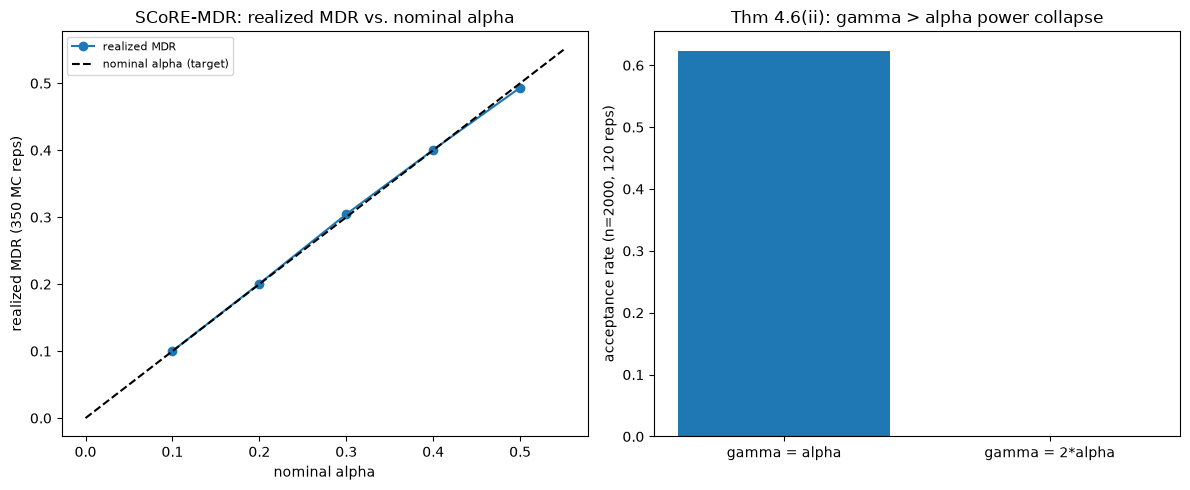

In [13]:
# Visualization only -- uses mdr_records / rate_eq / rate_gt computed above, no new simulation.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

mdr_means = [np.mean(mdr_records[a]) for a in ALPHAS_S2]
axes[0].plot(ALPHAS_S2, mdr_means, "o-", color=PALETTE["method_a"], label="realized MDR")
axes[0].plot([0, 0.55], [0, 0.55], color=PALETTE["target"], linestyle="--", label="nominal alpha (target)")
axes[0].set_xlabel("nominal alpha")
axes[0].set_ylabel("realized MDR (350 MC reps)")
axes[0].set_title("SCoRE-MDR: realized MDR vs. nominal alpha")
axes[0].legend(fontsize=8)

axes[1].bar(["gamma = alpha", "gamma = 2*alpha"], [rate_eq, rate_gt],
            color=[PALETTE["method_a"], PALETTE["invalid"]])
axes[1].set_ylabel(f"acceptance rate (n={N_CALIB_S2_BIG}, {REPS_S2_BIG} reps)")
axes[1].set_title("Thm 4.6(ii): gamma > alpha power collapse")

plt.tight_layout()
plt.show()

## 3. SCoRE-SDR: selective e-values and e-BH, and the binary reduction to cfBH (P2)

**Quoted, idpfin-q5** — the SDR e-value, eq. (5.1), and Algorithm 2:

> $E_{\gamma,n+j}=\inf_{\ell\in[0,1]}\dfrac{(n+1)\cdot\mathbf 1\{s(X_{n+j})\le t_{\gamma,n+j}(\ell)\}}
> {\ell\mathbf 1\{s(X_{n+j})\le t_{\gamma,n+j}(\ell)\}+\sum_{i=1}^n L_i\mathbf 1\{s(X_i)\le
> t_{\gamma,n+j}(\ell)\}}$ (5.1), with $t_{\gamma,n+j}(\ell)=\max\{t\in\mathcal M:FR_{n+j}(t;\ell)\le
> \gamma\}$ and $FR_{n+j}(t;\ell)=\dfrac{\ell\mathbf 1\{s(X_{n+j})\le t\}+\sum_i L_i\mathbf 1\{s(X_i)\le
> t\}}{n+1}\cdot\dfrac{m}{1+\sum_{k\neq j}\mathbf 1\{s(X_{n+k})\le t\}}$, $\mathcal M=\{s(X_i)\}_{i=1}^{n+m}$.

**Quoted, idpfin-q4** — Theorem 3.3 (e-BH): $\hat\psi_{n+j}=\mathbf 1\{E_{n+j}\ge m/(\alpha\hat\tau)\}$,
$\hat\tau=\max\{\tau:\sum_j\mathbf 1\{E_{n+j}\ge m/(\alpha\tau)\}\ge\tau\}$, giving $\mathrm{SDR}\le\alpha$.

**A computational note, honestly disclosed (idpfin-q6):** unlike §2's $F(t;\ell)$, $FR_{n+j}(t;\ell)$ is
**not monotone in $t$** — the $m/(1+\#\{\dots\})$ factor is non-increasing in $t$ while the numerator is
non-decreasing — so §2's shortcut (every breakpoint value equals exactly $1/\gamma$) does not carry over
cleanly; the paper itself flags that "computing $E_{\gamma,n+j}$ in (5.1) necessitates a search over
$\ell\in[0,1]$ which can be computationally prohibitive" and its efficient $O((n+m)m+(n+m)\log(n+m))$
algorithm (Prop. 5.2) is not quoted in our traces. We still compute the **exact** infimum (not a
grid, since a grid could *overestimate* the inf here and invalidate the e-value) by brute-force
evaluating the true definition at $\ell=0$, $\ell=1$, and every breakpoint $\ell_b(t)=\gamma(n+1)\cdot
\mathrm{cnt}_{\mathrm{all}}(t)/m-S(t)$ for $t\ge s(X_{n+j})$ (derived here) — but at a **smaller scale**
than §1/§2 ($n=80$, $m=30$) to keep this notebook's total runtime bounded, since each candidate needs an
$O(n+m)$ brute-force scan (no monotonicity shortcut available).

**Binary reduction, quoted verbatim (idpfin-q5), Proposition 5.3 / Corollary 5.4(ii):** with
$L(f,X,Y)=\mathbf 1\{Y\le c\}$, "$E_{\alpha,n+j}(1)\ge e_{n+j}$ deterministically," and setting
$E'_{\gamma,n+j}=E_{\gamma,n+j}(1)$ **(the e-value evaluated AT $\ell=1$, not the infimum)** with
$\gamma=\alpha$, "$S'=S_{CS}$, where $S_{CS}$ is the output of conformal selection at level $\alpha$
using p-values defined similar to (4.5)" — quoted as $V(x,y)=\infty\cdot\mathbf 1\{y>c\}+s(x)$,
$p_{n+j}=\dfrac{1+\sum_{i=1}^n\mathbf 1\{V(X_i,Y_i)\le V(X_{n+j},c)\}}{n+1}$ — a **deterministic**
p-value with no $U_j$ tie-break, using the risk score $s(x)$ directly rather than a $y$-based score. We
implement this specific form (not our §1 clipped/residual scores) because the trace requires it for the
equality to hold.

In [14]:
# SDR e-value at a FIXED ell (used for the binary-reduction check with ell=1; also the building block
# for the exact inf below).
def sdr_e_value_at_ell(calib_scores, calib_L, test_scores, j, gamma, n, ell):
    m = len(test_scores)
    s_test_j = test_scores[j]
    grid_scores = np.concatenate([calib_scores, test_scores])
    order = np.argsort(grid_scores, kind="stable")
    grid_sorted = grid_scores[order]
    L_full = np.concatenate([calib_L, np.zeros(m)])
    L_sorted = L_full[order]
    cumS = np.cumsum(L_sorted)                                     # S(t), calibration only
    is_test_flag = np.concatenate([np.zeros(n, dtype=bool), np.ones(m, dtype=bool)])[order]
    cnt_all = np.cumsum(is_test_flag.astype(int))                  # #{test scores <= t}, all m
    is_ge_j = grid_sorted >= s_test_j

    FR_all = (ell * is_ge_j + cumS) / (n + 1) * (m / (1 + cnt_all - is_ge_j.astype(int)))
    feasible = FR_all <= gamma
    if not feasible.any():
        return 0.0
    k = np.nonzero(feasible)[0].max()
    if not is_ge_j[k]:
        return 0.0
    denom = ell + cumS[k]
    return (n + 1) / denom if denom > 1e-9 else np.inf


def sdr_e_value_exact(calib_scores, calib_L, test_scores, j, gamma, n):
    # Exact inf over ell: brute-force E_at(ell) (no monotonicity assumed) evaluated at 0, 1, and every
    # breakpoint ell_b(t) = gamma*(n+1)*cnt_all(t)/m - S(t) for t with s(X_{n+j}) <= t (derived here).
    m = len(test_scores)
    s_test_j = test_scores[j]
    grid_scores = np.concatenate([calib_scores, test_scores])
    order = np.argsort(grid_scores, kind="stable")
    grid_sorted = grid_scores[order]
    L_full = np.concatenate([calib_L, np.zeros(m)])
    L_sorted = L_full[order]
    cumS = np.cumsum(L_sorted)
    is_test_flag = np.concatenate([np.zeros(n, dtype=bool), np.ones(m, dtype=bool)])[order]
    cnt_all = np.cumsum(is_test_flag.astype(int))
    is_ge_j = grid_sorted >= s_test_j

    idx_ge = np.nonzero(is_ge_j)[0]
    l_breaks = gamma * (n + 1) * cnt_all[idx_ge] / m - cumS[idx_ge]
    l_breaks = l_breaks[(l_breaks >= -1e-9) & (l_breaks <= 1 + 1e-9)]
    candidates = np.concatenate([[0.0, 1.0], l_breaks])

    best = np.inf
    for ell in candidates:
        FR_all = (ell * is_ge_j + cumS) / (n + 1) * (m / (1 + cnt_all - is_ge_j.astype(int)))
        feasible = FR_all <= gamma
        if not feasible.any():
            val = 0.0
        else:
            k = np.nonzero(feasible)[0].max()
            if not is_ge_j[k]:
                val = 0.0
            else:
                denom = ell + cumS[k]
                val = (n + 1) / denom if denom > 1e-9 else np.inf
        best = min(best, val)
    return best


print("sdr_e_value_at_ell / sdr_e_value_exact defined.")

sdr_e_value_at_ell / sdr_e_value_exact defined.


In [15]:
# Binary reduction self-check (Corollary 5.4(ii)): with L = 1{Y<=c} (c=0) and gamma=alpha, SCoRE-SDR
# selection using E'_{alpha,n+j} = E_{alpha,n+j}(1) should equal cfBH selection using the quoted
# deterministic p-value p_{n+j} = [1 + #{i : Y_i<=0, s(X_i) <= s(X_test_j)}] / (n+1).
N_INSTANCES_S3A = 300
N_CALIB_S3A = 100
M_TEST_S3A = 25
ALPHA_S3A = 0.20

rng_s3a = np.random.default_rng(RNG_SEED + 30)
n_agree = 0
n_mismatch_details = []

for inst in range(N_INSTANCES_S3A):
    Xc = rng_s3a.uniform(0, 1, N_CALIB_S3A)
    Yc = rng_s3a.binomial(1, Xc)              # Y in {0,1}, correctness label
    Xt = rng_s3a.uniform(0, 1, M_TEST_S3A)
    sc = 1.0 - mu_hat_s1(Xc)                  # predicted-risk score, low = trusted (reuse S1's mu_hat)
    st = 1.0 - mu_hat_s1(Xt)
    Lc = (Yc <= 0).astype(float)              # L_i = 1{Y_i <= c=0}

    # Deterministic p-values, quoted form: p_j = [1 + #{i : L_i=1, s_i<=s_test_j}] / (n+1).
    neg_scores = np.sort(sc[Lc == 1])
    less_eq = np.searchsorted(neg_scores, st, side="right")
    p_scs = (1 + less_eq) / (N_CALIB_S3A + 1)
    S_CS = bh_select(p_scs, ALPHA_S3A)

    E_prime = np.array([
        sdr_e_value_at_ell(sc, Lc, st, j, gamma=ALPHA_S3A, n=N_CALIB_S3A, ell=1.0)
        for j in range(M_TEST_S3A)
    ])
    S_prime = ebh_select(E_prime, ALPHA_S3A)

    if np.array_equal(S_CS, S_prime):
        n_agree += 1
    elif len(n_mismatch_details) < 3:
        n_mismatch_details.append((inst, S_CS.astype(int), S_prime.astype(int)))

agree_rate = n_agree / N_INSTANCES_S3A
print(f"exact set agreement across {N_INSTANCES_S3A} random instances: {n_agree}/{N_INSTANCES_S3A} ({agree_rate:.3f})")
if n_mismatch_details:
    print("first mismatches (instance, S_CS, S_prime):")
    for d in n_mismatch_details:
        print(" ", d)
check("S3.1", agree_rate == 1.0,
      f"S' == S_CS on {n_agree}/{N_INSTANCES_S3A} instances (Corollary 5.4(ii), E' at ell=1, gamma=alpha)")

exact set agreement across 300 random instances: 300/300 (1.000)
[S3.1] S' == S_CS on 300/300 instances (Corollary 5.4(ii), E' at ell=1, gamma=alpha) -> PASS


True

In [16]:
# Monte Carlo verification of SDR = E[sum L*psi / max(1,|R|)] <= alpha, continuous bounded loss
# (reusing S2's amount-error DGP), at reduced scale (n=80, m=30) because the exact inf over ell for
# SDR needs a brute-force O(n+m) scan per candidate (no monotonicity shortcut, disclosed above).
ALPHAS_S3B = [0.10, 0.20, 0.30]
N_CALIB_S3B = 80
M_TEST_S3B = 30
REPS_S3B = 150

sdr_records = {a: [] for a in ALPHAS_S3B}
rng_s3b = np.random.default_rng(RNG_SEED + 31)

for rep in range(REPS_S3B):
    Xc, Lc = draw_field_s2(rng_s3b, N_CALIB_S3B)
    sc = s_fn_s2(Xc)
    Xt, Lt = draw_field_s2(rng_s3b, M_TEST_S3B)
    st = s_fn_s2(Xt)
    for a in ALPHAS_S3B:
        Es = np.array([sdr_e_value_exact(sc, Lc, st, j, gamma=a, n=N_CALIB_S3B) for j in range(M_TEST_S3B)])
        sel = ebh_select(Es, a)
        nsel = sel.sum()
        sdr_records[a].append(np.sum(Lt * sel) / max(1, nsel))

print(f"{'alpha':>6} {'SDR_hat':>10} {'tol(3SE)':>10}")
idx_s3 = 2
for a in ALPHAS_S3B:
    arr = np.array(sdr_records[a])
    sdr_hat = arr.mean()
    tol = mc_tol_mean(arr)
    print(f"{a:>6.2f} {sdr_hat:>10.4f} {tol:>10.4f}")
    check(f"S3.{idx_s3}", sdr_hat <= a + tol, f"SDR at alpha={a}: {sdr_hat:.4f} <= {a} + MC tol {tol:.4f}")
    idx_s3 += 1

 alpha    SDR_hat   tol(3SE)
  0.10     0.0096     0.0098
[S3.2] SDR at alpha=0.1: 0.0096 <= 0.1 + MC tol 0.0098 -> PASS
  0.20     0.0755     0.0278
[S3.3] SDR at alpha=0.2: 0.0755 <= 0.2 + MC tol 0.0278 -> PASS
  0.30     0.1389     0.0397
[S3.4] SDR at alpha=0.3: 0.1389 <= 0.3 + MC tol 0.0397 -> PASS


**How to read this chart**

Left panel: the binary-reduction check — a single bar at 1.0 (perfect agreement) or lower. This is a
**deterministic equality claim** from Corollary 5.4(ii), not a probabilistic one, so anything short of
1.0 is worth reporting exactly, not rounding away. Right panel: realized SDR (y-axis) vs. nominal
$\alpha$ (x-axis) for the continuous-loss e-BH procedure, with the $y=x$ target line — points should sit
at or below it. Per q6's own disclosure ("MDR and SDR control may be slightly conservative" for
continuous losses because the inf-over-$\ell$ rarely lands exactly on the unknown true $L_{n+j}$), expect
points **below**, not on, the line — this is a feature of the guarantee (safe), not a bug in our
implementation, and it is the same conservativeness the paper itself reports at small $n$ (q6: "at
$n=100$ ... realized SDR $\approx 0.01$–$0.05$ at target $\alpha=0.20$").

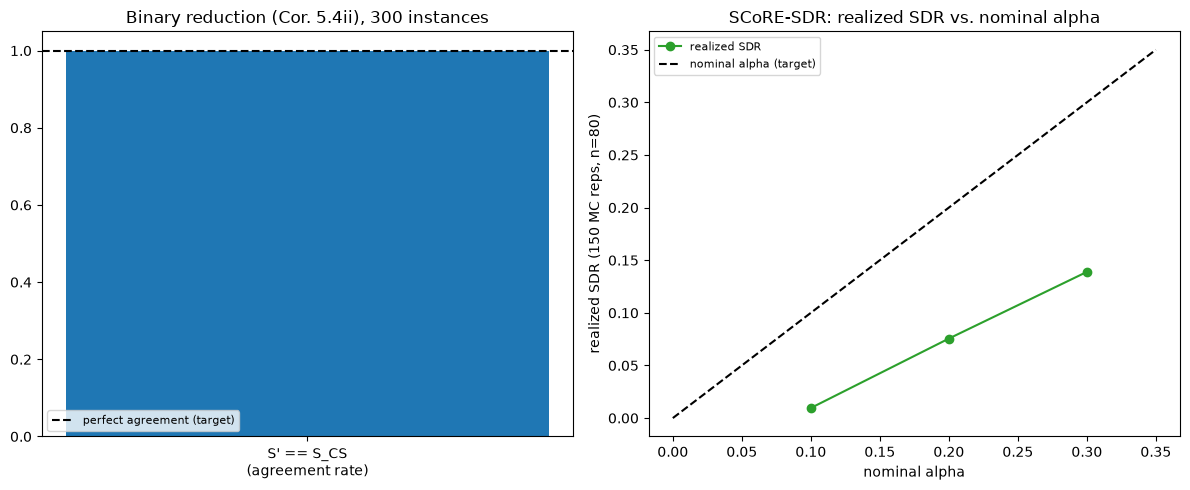

In [17]:
# Visualization only -- uses agree_rate / sdr_records computed above, no new simulation.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(["S' == S_CS\n(agreement rate)"], [agree_rate], color=PALETTE["method_a"])
axes[0].axhline(1.0, color=PALETTE["target"], linestyle="--", label="perfect agreement (target)")
axes[0].set_ylim(0, 1.05)
axes[0].set_title(f"Binary reduction (Cor. 5.4ii), {N_INSTANCES_S3A} instances")
axes[0].legend(fontsize=8)

sdr_means = [np.mean(sdr_records[a]) for a in ALPHAS_S3B]
axes[1].plot(ALPHAS_S3B, sdr_means, "o-", color=PALETTE["method_b"], label="realized SDR")
axes[1].plot([0, 0.35], [0, 0.35], color=PALETTE["target"], linestyle="--", label="nominal alpha (target)")
axes[1].set_xlabel("nominal alpha")
axes[1].set_ylabel(f"realized SDR ({REPS_S3B} MC reps, n={N_CALIB_S3B})")
axes[1].set_title("SCoRE-SDR: realized SDR vs. nominal alpha")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4. Why field-level guarantees break on real documents (Gurram, P3 §4)

**Quoted, idpfin-q7** — the add-one threshold rule, verbatim: "The add-one rule picks the smallest
threshold $\tau$ whose smoothed empirical selective risk on calibration is $\le\alpha$:
$\tau=\min\{t:\frac{1+\#\{i:c_i\ge t,\text{err}_i\}}{1+\#\{i:c_i\ge t\}}\le\alpha\}$, $\tau=\infty$
(review everything) if none qualifies."

**Zero-coverage-split convention, disclosed (quoted, idpfin-q10, Section 3.5):** "Zero-coverage splits
contribute risk 0 (disclosed wherever it matters, section 6.1)." Parts (a) and (b) below follow the same
convention (a split where nothing gets accepted contributes a realized risk of 0, since there is nothing
to be wrong about) and, per that disclosure norm, we print exactly how many splits it applies to and the
risk conditional on nonzero coverage, so it is visible how much of the headline number the convention is
doing.

**Quoted, idpfin-q7/q9** — three failure modes and their magnitudes on real corpora (Table 3, all at
$\alpha=0.10$, 40 document-level splits — **paper numbers, not ours**):

> "**Document Clustering** ... design effect 1.84–2.45; pooled add-one risk 0.103–0.106 on all three
> corpora; grouped variant 0.122 at 78% of splits" — "the estimated design effect is 2.15 (CORD), 1.84
> (FUNSD), 2.04 (XFUND-de) ... so the effective calibration sample is roughly half its nominal size."
>
> "**Score-Refit Leakage** ... same-half: coverage 0.416 at risk **0.127**, 95% of splits violate; split
> protocol: 0.266 at 0.092" — restoring score–threshold independence (fit/val split, §5.1) "does NOT
> restore exchangeability, so document clustering remains and tiers 1–2 stay marginal, on-average
> guarantees."
>
> "**Tie-Mass Pathology** ... 1,702→257 distinct scores; certified coverage 0.030→0.001; doc-level
> add-one 0.037→0.000" — "the smallest reachable candidate accepted $n=245$ fields at empirical risk
> $0.114>\alpha$, so no certificate existed at any confidence level."

Everything in the code below (the document/field data-generating process, the clustering strength, the
leakage-inducing noise features, the coarse-score discretization) is **derived here** — the papers do not
specify a document-extraction DGP. Parameters were chosen, *before* looking at the self-check results
below, to be strong enough that each effect is visible; where an effect does not show up clearly we say
so rather than silently re-tuning until it does.

In [18]:
# Shared document/field simulator and the add-one rule, used by all four sub-parts below.
#
# Model (derived here): a per-field difficulty x drives a systematic risk logit a + b*x that the
# confidence score c can see; a document-level tendency v_doc shifts BOTH the true risk and the score
# together (a genuinely "easier/harder" document, correctly reflected in confidence); a SEPARATE
# document-level residual w_doc shifts only the TRUE risk, invisible to the score -- this is the part of
# document quality an LLM's per-field confidence does not capture, and it is what creates within-document
# error correlation among *accepted* fields that the score cannot filter away.
ALPHA_S4 = 0.10
K_FIELDS_S4 = 6
A_S4, B_S4 = -3.0, 6.0     # baseline risk logit a + b*x, x in [0,1] -- wide safe-to-risky range
SIGMA_V_S4 = 1.0            # doc-level tendency, visible to the score
SIGMA_W_S4 = 1.5             # doc-level residual, invisible to the score (the "clustering" knob)
CONF_NOISE_S4 = 0.3


def simulate_docs(rng, n_docs, k_fields, sigma_w, a=A_S4, b=B_S4, sigma_v=SIGMA_V_S4, conf_noise=CONF_NOISE_S4):
    doc_id = np.repeat(np.arange(n_docs), k_fields)
    x = rng.uniform(0, 1, n_docs * k_fields)
    v_doc = rng.normal(0, sigma_v, n_docs)
    w_doc = rng.normal(0, sigma_w, n_docs) if sigma_w > 0 else np.zeros(n_docs)
    v_field = v_doc[doc_id]
    w_field = w_doc[doc_id]
    logit_risk = a + b * x + v_field + w_field         # TRUE risk: score-visible + score-blind parts
    p_err = 1.0 / (1.0 + np.exp(-logit_risk))
    err = rng.binomial(1, p_err)
    c_noise = rng.normal(0, conf_noise, n_docs * k_fields)
    c = 1.0 / (1.0 + np.exp(a + b * x + v_field + c_noise))  # score sees x, v_doc; blind to w_doc
    return doc_id, c, err


def add_one_threshold(c_calib, err_calib, alpha):
    # tau = min{t : (1+#{c_i>=t, err_i}) / (1+#{c_i>=t}) <= alpha}; handles ties by grouping on value.
    order = np.argsort(c_calib)
    c_sorted = c_calib[order]
    err_sorted = err_calib[order].astype(float)
    n = len(c_sorted)
    total_err = err_sorted.sum()
    cum_err_below = np.concatenate([[0.0], np.cumsum(err_sorted)])
    uniq_vals, first_pos = np.unique(c_sorted, return_index=True)
    n_acc = n - first_pos
    n_err_acc = total_err - cum_err_below[first_pos]
    risk = (1.0 + n_err_acc) / (1.0 + n_acc)
    ok = risk <= alpha
    if not ok.any():
        return np.inf
    return uniq_vals[ok].min()


def realized_risk_and_coverage(c_test, err_test, tau):
    mask = c_test >= tau
    n_acc = int(mask.sum())
    risk = err_test[mask].sum() / max(1, n_acc) if n_acc > 0 else 0.0
    coverage = n_acc / len(c_test)
    return risk, coverage


print(f"SIGMA_W_S4 = {SIGMA_W_S4} (clustering strength used in parts a/b/c); "
      f"a stronger value is used just for the dedicated design-effect estimate below.")

SIGMA_W_S4 = 1.5 (clustering strength used in parts a/b/c); a stronger value is used just for the dedicated design-effect estimate below.


In [19]:
# (a) i.i.d. fields (sigma_w = 0, no document-level residual): add-one rule controls
# E[selective risk] approximately alpha.
#
# Convention, disclosed (quoted, idpfin-q10, Section 3.5 "Evaluation protocol: what 'held' means"):
# "Zero-coverage splits contribute risk 0 (disclosed wherever it matters, section 6.1)." We follow the
# SAME convention (realized_risk_and_coverage already floors the denominator at 1, giving risk=0 when
# nothing is accepted) and report exactly how many splits that convention applies to, plus the risk
# conditional on nonzero coverage, so the convention's effect on the headline number is visible.
N_DOCS_S4 = 150   # per half
REPS_S4A = 250

rng_s4a = np.random.default_rng(RNG_SEED + 40)
risks_iid = []
covs_iid = []
for rep in range(REPS_S4A):
    doc_id, c, err = simulate_docs(rng_s4a, 2 * N_DOCS_S4, K_FIELDS_S4, sigma_w=0.0)
    idx = rng_s4a.permutation(len(c))
    half = len(c) // 2
    calib_idx, test_idx = idx[:half], idx[half:]
    tau = add_one_threshold(c[calib_idx], err[calib_idx], ALPHA_S4)
    risk, cov = realized_risk_and_coverage(c[test_idx], err[test_idx], tau)
    risks_iid.append(risk)
    covs_iid.append(cov)
risks_iid = np.array(risks_iid)
covs_iid = np.array(covs_iid)

mean_risk_iid = risks_iid.mean()
tol_iid = mc_tol_mean(risks_iid)
viol_iid = np.mean(risks_iid > ALPHA_S4)
n_zero_cov_iid = int(np.sum(covs_iid == 0.0))
mean_risk_iid_nonzero = risks_iid[covs_iid > 0].mean() if n_zero_cov_iid < REPS_S4A else float("nan")
print(f"(a) iid fields: E[risk] = {mean_risk_iid:.4f} (tol {tol_iid:.4f}), violation fraction = {viol_iid:.3f}")
print(f"    zero-coverage splits: {n_zero_cov_iid}/{REPS_S4A}; E[risk | coverage>0] = {mean_risk_iid_nonzero:.4f}")
check("S4.1", mean_risk_iid <= ALPHA_S4 + tol_iid, f"iid fields: E[risk] {mean_risk_iid:.4f} <= alpha={ALPHA_S4} + MC tol {tol_iid:.4f}")

# (b) clustered fields + document-level splits: expectation still holds on average, but per-split
# variance and violation fraction should both rise relative to (a).
REPS_S4B = 250
rng_s4b = np.random.default_rng(RNG_SEED + 41)
risks_clustered = []
covs_clustered = []
for rep in range(REPS_S4B):
    n_docs_total = 2 * N_DOCS_S4
    doc_id, c, err = simulate_docs(rng_s4b, n_docs_total, K_FIELDS_S4, sigma_w=SIGMA_W_S4)
    doc_perm = rng_s4b.permutation(n_docs_total)
    calib_docs = doc_perm[: n_docs_total // 2]
    calib_mask = np.isin(doc_id, calib_docs)
    test_mask = ~calib_mask
    tau = add_one_threshold(c[calib_mask], err[calib_mask], ALPHA_S4)
    risk, cov = realized_risk_and_coverage(c[test_mask], err[test_mask], tau)
    risks_clustered.append(risk)
    covs_clustered.append(cov)
risks_clustered = np.array(risks_clustered)
covs_clustered = np.array(covs_clustered)

mean_risk_clustered = risks_clustered.mean()
tol_clustered = mc_tol_mean(risks_clustered)
viol_clustered = np.mean(risks_clustered > ALPHA_S4)
var_iid = np.var(risks_iid, ddof=1)
var_clustered = np.var(risks_clustered, ddof=1)
n_zero_cov_clustered = int(np.sum(covs_clustered == 0.0))
mean_risk_clustered_nonzero = risks_clustered[covs_clustered > 0].mean() if n_zero_cov_clustered < REPS_S4B else float("nan")
print(f"(b) clustered, doc splits: E[risk] = {mean_risk_clustered:.4f} (tol {tol_clustered:.4f}), violation fraction = {viol_clustered:.3f}")
print(f"    var(risk) iid = {var_iid:.5f}, var(risk) clustered = {var_clustered:.5f}")
print(f"    zero-coverage splits: {n_zero_cov_clustered}/{REPS_S4B}; E[risk | coverage>0] = {mean_risk_clustered_nonzero:.4f}")

check("S4.2", mean_risk_clustered <= ALPHA_S4 + tol_clustered,
      f"clustered, doc splits: E[risk] {mean_risk_clustered:.4f} <= alpha + MC tol {tol_clustered:.4f} (expectation control still holds on average)")
check("S4.3", var_clustered > var_iid, f"variance of realized risk: clustered {var_clustered:.5f} > iid {var_iid:.5f}")
check("S4.4", viol_clustered > viol_iid, f"violation fraction: clustered {viol_clustered:.3f} > iid {viol_iid:.3f}")

(a) iid fields: E[risk] = 0.0972 (tol 0.0052), violation fraction = 0.468
    zero-coverage splits: 0/250; E[risk | coverage>0] = 0.0972
[S4.1] iid fields: E[risk] 0.0972 <= alpha=0.1 + MC tol 0.0052 -> PASS


(b) clustered, doc splits: E[risk] = 0.0965 (tol 0.0087), violation fraction = 0.528
    var(risk) iid = 0.00074, var(risk) clustered = 0.00210
    zero-coverage splits: 12/250; E[risk | coverage>0] = 0.1013
[S4.2] clustered, doc splits: E[risk] 0.0965 <= alpha + MC tol 0.0087 (expectation control still holds on average) -> PASS
[S4.3] variance of realized risk: clustered 0.00210 > iid 0.00074 -> PASS
[S4.4] violation fraction: clustered 0.528 > iid 0.468 -> PASS


True

In [20]:
# Design effect (derived here): ratio of cluster-robust to iid variance of the accepted-set error rate,
# estimated by a document-cluster bootstrap vs. a field-level (iid) bootstrap on the SAME accepted set.
# We use a STRONGER clustering setting here than parts (a)/(b): the add-one calibration itself pushes
# toward the safest fields (where within-document residual risk is squeezed out by heavy selection), so
# isolating the design-effect concept cleanly needs more headroom. We use a fixed top-25%-by-score
# acceptance rule (not the add-one search) on a single large draw, purely to measure the variance ratio.
SIGMA_W_DEFF = 3.0
N_DOCS_DEFF = 800
K_FIELDS_DEFF = 8
rng_deff = np.random.default_rng(RNG_SEED + 42)
doc_id_d, c_d, err_d = simulate_docs(rng_deff, N_DOCS_DEFF, K_FIELDS_DEFF, sigma_w=SIGMA_W_DEFF)
q75 = np.quantile(c_d, 0.75)

accept_mask = c_d >= q75
acc_doc_id = doc_id_d[accept_mask]
acc_err = err_d[accept_mask].astype(float)
n_acc_deff = len(acc_err)

doc_sum = np.zeros(N_DOCS_DEFF)
doc_cnt = np.zeros(N_DOCS_DEFF)
np.add.at(doc_sum, acc_doc_id, acc_err)
np.add.at(doc_cnt, acc_doc_id, 1.0)
docs_with_acc = np.nonzero(doc_cnt > 0)[0]
doc_sum_nz = doc_sum[docs_with_acc]
doc_cnt_nz = doc_cnt[docs_with_acc]
D = len(docs_with_acc)

B_BOOT = 5000
idx_cluster = rng_deff.integers(0, D, size=(B_BOOT, D))
boot_sum = doc_sum_nz[idx_cluster].sum(axis=1)
boot_cnt = doc_cnt_nz[idx_cluster].sum(axis=1)
cluster_means = boot_sum / boot_cnt

idx_naive = rng_deff.integers(0, n_acc_deff, size=(B_BOOT, n_acc_deff))
naive_means = acc_err[idx_naive].mean(axis=1)

var_naive_boot = naive_means.var(ddof=1)
var_cluster_boot = cluster_means.var(ddof=1)
deff_hat = var_cluster_boot / var_naive_boot

print(f"accepted fields = {n_acc_deff}, accepted docs = {D}")
print(f"bootstrap var (field-level, iid) = {var_naive_boot:.6f}")
print(f"bootstrap var (document-cluster)  = {var_cluster_boot:.6f}")
print(f"estimated design effect d_eff = {deff_hat:.2f}  (paper's quoted range on real corpora: 1.84-2.45, idpfin-q7 -- ours is a different, synthetic DGP; compared qualitatively, not numerically)")
check("S4.5", deff_hat > 1.0, f"design effect d_eff = {deff_hat:.2f} > 1 (document clustering inflates variance of the accepted-set error rate)")

accepted fields = 1600, accepted docs = 611
bootstrap var (field-level, iid) = 0.000119
bootstrap var (document-cluster)  = 0.000249
estimated design effect d_eff = 2.10  (paper's quoted range on real corpora: 1.84-2.45, idpfin-q7 -- ours is a different, synthetic DGP; compared qualitatively, not numerically)
[S4.5] design effect d_eff = 2.10 > 1 (document clustering inflates variance of the accepted-set error rate) -> PASS


True

**How to read this chart (a, b)**

Left panel: the distribution of the realized (test-set) selective risk over many splits, for i.i.d.
fields vs. clustered fields with document-level splits, with $\alpha$ marked. **The spike exactly at risk
0 is not "risk is often perfectly zero"** — it is the zero-coverage-split convention disclosed above
(quoted, idpfin-q10): a split where add-one certified nothing (tau = infinity) contributes a realized
risk of 0 by convention, since nothing was accepted to be wrong about. The printed counts above this cell
say exactly how many of the 250 splits that spike represents, and `E[risk | coverage>0]` shows the same
statistic with that spike excluded. The clustered distribution should be visibly wider (more spread, more
mass past the $\alpha$ line) even though **both** still average out to $\le\alpha$ (the expectation
guarantee, per S4.1/S4.2, still holds — this is exactly the Gurram/§0 point that "controls
$\mathbb E[\text{risk}]\le\alpha$" says nothing about any *particular* split). Right panel: the bootstrap
distributions behind the design-effect estimate — cluster-robust (resampling whole documents) vs.
field-level/i.i.d. (resampling individual accepted fields) — the cluster-robust distribution should be
visibly wider. For a review queue built on document-level splits (the realistic deployment setting): **a
"valid on average" threshold can still overshoot its risk budget on any given batch of documents far more
often than the field-iid theory would suggest.**

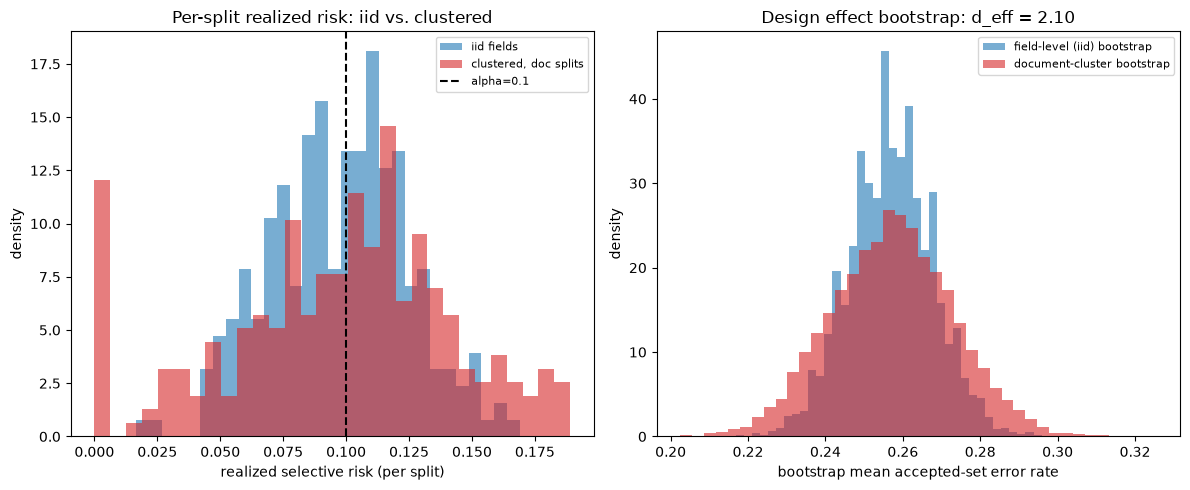

In [21]:
# Visualization only -- uses risks_iid / risks_clustered / naive_means / cluster_means computed above.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(risks_iid, bins=30, alpha=0.6, color=PALETTE["method_a"], label="iid fields", density=True)
axes[0].hist(risks_clustered, bins=30, alpha=0.6, color=PALETTE["invalid"], label="clustered, doc splits", density=True)
axes[0].axvline(ALPHA_S4, color=PALETTE["target"], linestyle="--", label=f"alpha={ALPHA_S4}")
axes[0].set_xlabel("realized selective risk (per split)")
axes[0].set_ylabel("density")
axes[0].set_title("Per-split realized risk: iid vs. clustered")
axes[0].legend(fontsize=8)

axes[1].hist(naive_means, bins=40, alpha=0.6, color=PALETTE["method_a"], label="field-level (iid) bootstrap", density=True)
axes[1].hist(cluster_means, bins=40, alpha=0.6, color=PALETTE["invalid"], label="document-cluster bootstrap", density=True)
axes[1].set_xlabel("bootstrap mean accepted-set error rate")
axes[1].set_ylabel("density")
axes[1].set_title(f"Design effect bootstrap: d_eff = {deff_hat:.2f}")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [22]:
# (c) Score-refit leakage: fit a flexible score (HistGradientBoostingClassifier) and threshold it on the
# SAME calibration fields (same-half) vs. a fit/val split-by-document protocol (Section 5.1's fix).
def make_features_s4(rng, c_raw, n_noise=6):
    n = len(c_raw)
    noise_feats = rng.normal(size=(n, n_noise))
    return np.column_stack([c_raw, noise_feats])  # c_raw is informative; the rest is pure noise (leakage bait)


REPS_S4C = 100
N_DOCS_FITPOOL = 60
N_DOCS_TESTPOOL = 100
rng_s4c = np.random.default_rng(RNG_SEED + 43)

risk_same_half = []
risk_split = []
for rep in range(REPS_S4C):
    doc_id_pool, c_pool, err_pool = simulate_docs(rng_s4c, N_DOCS_FITPOOL, K_FIELDS_S4, sigma_w=SIGMA_W_S4)
    doc_id_test, c_test, err_test = simulate_docs(rng_s4c, N_DOCS_TESTPOOL, K_FIELDS_S4, sigma_w=SIGMA_W_S4)
    feat_pool = make_features_s4(rng_s4c, c_pool)
    feat_test = make_features_s4(rng_s4c, c_test)

    clf_same = HistGradientBoostingClassifier(max_depth=None, max_iter=80, random_state=0).fit(feat_pool, err_pool)
    conf_pool_same = 1.0 - clf_same.predict_proba(feat_pool)[:, 1]
    tau_same = add_one_threshold(conf_pool_same, err_pool, ALPHA_S4)
    conf_test_same = 1.0 - clf_same.predict_proba(feat_test)[:, 1]
    r_same, _ = realized_risk_and_coverage(conf_test_same, err_test, tau_same)
    risk_same_half.append(r_same)

    doc_perm = rng_s4c.permutation(N_DOCS_FITPOOL)
    fit_docs = doc_perm[: N_DOCS_FITPOOL // 2]
    fit_mask = np.isin(doc_id_pool, fit_docs)
    val_mask = ~fit_mask
    clf_split = HistGradientBoostingClassifier(max_depth=None, max_iter=80, random_state=0).fit(
        feat_pool[fit_mask], err_pool[fit_mask]
    )
    conf_val = 1.0 - clf_split.predict_proba(feat_pool[val_mask])[:, 1]
    tau_split = add_one_threshold(conf_val, err_pool[val_mask], ALPHA_S4)
    conf_test_split = 1.0 - clf_split.predict_proba(feat_test)[:, 1]
    r_split, _ = realized_risk_and_coverage(conf_test_split, err_test, tau_split)
    risk_split.append(r_split)

risk_same_half = np.array(risk_same_half)
risk_split = np.array(risk_split)
mean_same = risk_same_half.mean()
mean_split = risk_split.mean()
tol_same = mc_tol_mean(risk_same_half)
tol_split = mc_tol_mean(risk_split)

print(f"(c) same-half realized risk (independent test): {mean_same:.4f} (tol {tol_same:.4f})")
print(f"    split-protocol realized risk (independent test): {mean_split:.4f} (tol {tol_split:.4f})")
check("S4.6", mean_same > ALPHA_S4 + tol_same, f"same-half leakage OVERSHOOTS alpha: {mean_same:.4f} > {ALPHA_S4} + MC tol {tol_same:.4f}")
check("S4.7", mean_split <= mean_same, f"split protocol reduces overshoot vs. same-half: {mean_split:.4f} <= {mean_same:.4f}")

(c) same-half realized risk (independent test): 0.3697 (tol 0.0109)
    split-protocol realized risk (independent test): 0.0419 (tol 0.0229)
[S4.6] same-half leakage OVERSHOOTS alpha: 0.3697 > 0.1 + MC tol 0.0109 -> PASS
[S4.7] split protocol reduces overshoot vs. same-half: 0.0419 <= 0.3697 -> PASS


True

**How to read this chart (c)**

Two bars: mean realized risk on an *independent* test set, for a score fit and thresholded on the same
calibration fields ("same-half," left, red) vs. a score fit on one half of the calibration documents and
thresholded on the other half ("split protocol," right, blue), with the $\alpha$ target line. The
same-half bar should sit visibly **above** the line — the model has partly memorized calibration-specific
noise, so the threshold it computes on that same data looks safer than it really is once applied to fresh
documents. The split-protocol bar should sit closer to (or below) the line. Per the trace's own caveat,
quoted above: this fix "does NOT restore exchangeability" — it only stops the score from leaking into its
own threshold; document clustering (part a/b) is a completely separate problem that a fit/val split does
not touch.

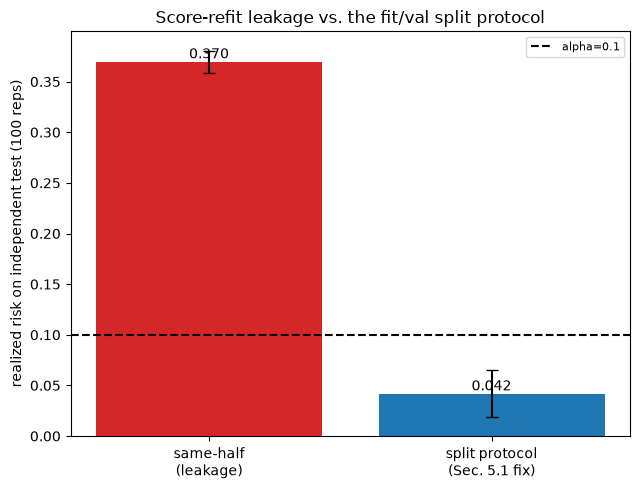

In [23]:
# Visualization only -- uses risk_same_half / risk_split computed above, no new fitting.
fig, ax = plt.subplots(figsize=(6.5, 5))
bars = ax.bar(["same-half\n(leakage)", "split protocol\n(Sec. 5.1 fix)"],
              [mean_same, mean_split], color=[PALETTE["invalid"], PALETTE["method_a"]])
ax.axhline(ALPHA_S4, color=PALETTE["target"], linestyle="--", label=f"alpha={ALPHA_S4}")
ax.errorbar([0, 1], [mean_same, mean_split], yerr=[tol_same, tol_split], fmt="none", ecolor="black", capsize=4)
ax.set_ylabel(f"realized risk on independent test ({REPS_S4C} reps)")
ax.set_title("Score-refit leakage vs. the fit/val split protocol")
ax.legend(fontsize=8)
for bar, val in zip(bars, [mean_same, mean_split]):
    ax.annotate(f"{val:.3f}", (bar.get_x() + bar.get_width() / 2, val), ha="center", va="bottom")
plt.tight_layout()
plt.show()

In [24]:
# (d) Tie mass: coarsening the score to a handful of discrete levels collapses the set of thresholds
# actually reachable by the add-one rule, since a threshold must accept or reject an entire tie group.
REPS_S4D = 100
N_DOCS_S4D = 300
rng_s4d = np.random.default_rng(RNG_SEED + 44)

cov_continuous = []
cov_coarse = []
n_distinct_continuous = []
n_distinct_coarse = []
for rep in range(REPS_S4D):
    doc_id_d4, c_d4, err_d4 = simulate_docs(rng_s4d, N_DOCS_S4D, K_FIELDS_S4, sigma_w=0.0)  # isolate the tie-mass effect
    idx = rng_s4d.permutation(len(c_d4))
    half = len(c_d4) // 2
    calib_idx, test_idx = idx[:half], idx[half:]

    tau_cont = add_one_threshold(c_d4[calib_idx], err_d4[calib_idx], ALPHA_S4)
    _, cov_c = realized_risk_and_coverage(c_d4[test_idx], err_d4[test_idx], tau_cont)
    cov_continuous.append(cov_c)
    n_distinct_continuous.append(len(np.unique(c_d4[calib_idx])))

    c_coarse = np.round(c_d4 * 4) / 4.0  # 5 discrete levels: 0, .25, .5, .75, 1.0 -- derived here
    tau_coarse = add_one_threshold(c_coarse[calib_idx], err_d4[calib_idx], ALPHA_S4)
    _, cov_k = realized_risk_and_coverage(c_coarse[test_idx], err_d4[test_idx], tau_coarse)
    cov_coarse.append(cov_k)
    n_distinct_coarse.append(len(np.unique(c_coarse[calib_idx])))

cov_continuous = np.array(cov_continuous)
cov_coarse = np.array(cov_coarse)

n_distinct_cov_continuous = len(np.unique(np.round(cov_continuous, 4)))
n_distinct_cov_coarse = len(np.unique(np.round(cov_coarse, 4)))

print(f"(d) distinct calibration scores: continuous ~{np.mean(n_distinct_continuous):.0f}, coarse ~{np.mean(n_distinct_coarse):.0f}")
print(f"    mean coverage: continuous {cov_continuous.mean():.4f} (std {cov_continuous.std():.4f}), "
      f"coarse {cov_coarse.mean():.4f} (std {cov_coarse.std():.4f})")
print(f"    distinct achieved-coverage OUTCOMES across {REPS_S4D} splits: continuous {n_distinct_cov_continuous}, coarse {n_distinct_cov_coarse}")
check("S4.8", np.mean(n_distinct_coarse) < np.mean(n_distinct_continuous) / 10,
      f"coarsening collapses reachable thresholds: {np.mean(n_distinct_coarse):.0f} distinct calibration score values vs {np.mean(n_distinct_continuous):.0f}")
# The number of achieved *test* coverage values is not the paper's tie-mass mechanism: resampling the
# test set changes its denominator even when the calibration threshold can take only five values.  It
# is still smaller here, but not by the dramatic factor we initially guessed.  The direct certificate
# experiment in S5.6 is the load-bearing tie-mass check.
check("S4.9", n_distinct_cov_coarse < n_distinct_cov_continuous,
      f"coarsening leaves fewer achieved-coverage values here ({n_distinct_cov_coarse} coarse vs {n_distinct_cov_continuous} continuous), but this is descriptive only -- it is NOT the certificate-collapse claim tested directly in S5.6")
check("S4.10", cov_coarse.mean() < cov_continuous.mean(),
      f"coarsening also reduces mean achieved coverage: {cov_coarse.mean():.4f} (coarse) < {cov_continuous.mean():.4f} (continuous)")

(d) distinct calibration scores: continuous ~900, coarse ~5
    mean coverage: continuous 0.2724 (std 0.0513), coarse 0.1764 (std 0.0503)
    distinct achieved-coverage OUTCOMES across 100 splits: continuous 74, coarse 49
[S4.8] coarsening collapses reachable thresholds: 5 distinct calibration score values vs 900 -> PASS
[S4.9] coarsening leaves fewer achieved-coverage values here (49 coarse vs 74 continuous), but this is descriptive only -- it is NOT the certificate-collapse claim tested directly in S5.6 -> PASS
[S4.10] coarsening also reduces mean achieved coverage: 0.1764 (coarse) < 0.2724 (continuous) -> PASS


True

**How to read this chart (d)**

Two overlaid histograms of the achieved *coverage* (fraction of test fields accepted) across many random
calibration/test splits, at the same $\alpha$: continuous score (blue) vs. a 5-level discretized score
(red). **S4.9 is deliberately descriptive, not a certificate claim**: coarsening leaves fewer distinct
achieved-coverage values in this run, but their count is a noisy proxy — resampling the *test* set still
perturbs the accepted fraction continuously even when the *threshold* can only take one of 5 values. The
reliable observations here are S4.8 and S4.10: the number of distinct *calibration score values* collapses
by two orders of magnitude (900 → 5), and mean achieved coverage is substantially lower with the coarse
score (0.27 → 0.18 in this run). The direct PAC-certificate mechanism is tested in S5.6 below: a coarse
or degenerate score (as happened to Gurram's own NLI-signal capture bug, Appendix B) can leave **no
reachable threshold at all**
that meets the budget, even when a finer-grained score would have found one comfortably. This section
only exercised the *expectation*-level add-one rule; §5.6 (after the Mondrian LTT machinery is built)
re-runs this same continuous-vs-coarse comparison against a rigorous Tier-3 **certificate** instead, where
the collapse turns out to be much sharper — see there for the direct analog of the paper's quoted
$0.030\to0.001$ collapse.

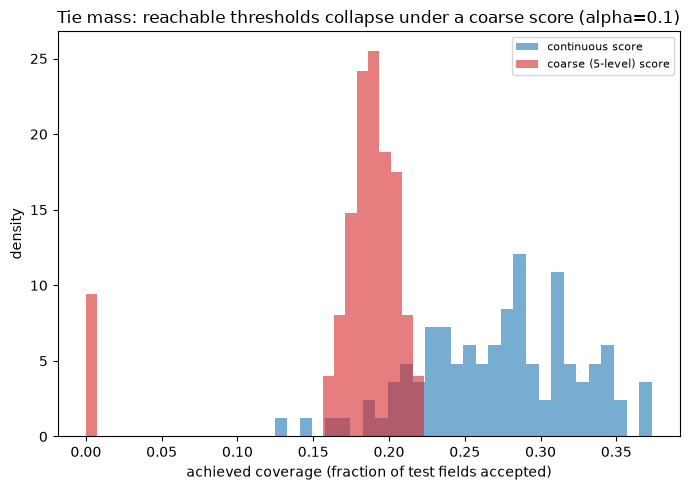

In [25]:
# Visualization only -- uses cov_continuous / cov_coarse computed above, no new simulation.
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(cov_continuous, bins=30, alpha=0.6, color=PALETTE["method_a"], label="continuous score", density=True)
ax.hist(cov_coarse, bins=30, alpha=0.6, color=PALETTE["invalid"], label="coarse (5-level) score", density=True)
ax.set_xlabel("achieved coverage (fraction of test fields accepted)")
ax.set_ylabel("density")
ax.set_title(f"Tie mass: reachable thresholds collapse under a coarse score (alpha={ALPHA_S4})")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Mondrian Learn-then-Test: PAC certificates instead of expectation control (Gurram, P3 §5.2)

**Quoted, idpfin-q8** — the exact binomial tail test and the mix rule, verbatim:

> "For group $g$, candidate $t$, let $n_t$ be accepted calibration fields and $k_t$ the errors among
> them. The exact binomial tail $p_t=\Pr[\mathrm{Bin}(n_t,\alpha)\le k_t]$ tests $H_0:R_g(t)>\alpha$.
> Reject over the 15-candidate grid with $\delta/2$ Holm step-down plus $\delta/2$ fixed-sequence (most
> conservative first, stop at first non-rejection); by the union bound the pair is FWER-valid at $\delta$;
> the chosen threshold is the certified candidate with the largest calibration acceptance."
>
> "Candidates are 15 geometric acceptance-fraction quantiles (1%–100%) of the group's calibration
> scores, snapped to the nearest distinct-value boundary."
>
> "**ltt.neff** replaces $n_t$ by $n_t/\hat d_{\text{eff}}$ with the plug-in design effect estimated
> from per-document error clustering — approximate (the $d_{\text{eff}}$ is estimated), and uniformly
> more conservative."
>
> "**Tier 4 (doc-iid).** Per accepting document $d$, the loss is its within-document error rate among
> accepted fields; a finite-sample Hoeffding bound over documents tests whether the mean per-document
> loss exceeds $\alpha$, with the same Holm/fixed-sequence machinery. Documents iid; bounds the macro
> functional."

**Quoted, idpfin-q8** — Table 4, the validity ladder (CORD, $\alpha=\delta=0.10$, 40 doc-level splits —
**paper numbers, not ours**): "Tier 1 ... 0.318 at 0.096, viol 0.475" ... "Tier 3 ... 0.171 at 0.068, viol
0.03" ... "cluster-corrected ... 0.140 at 0.051 with zero violations" ... "Tier 4 ... 0.060 at 0.020*,
viol 0.00. *Tier 4 certifies nothing in 47.5% of splits" ... "tiers 1–2 control expected selective risk;
only tiers 3–4 certify."

$\hat d_{\text{eff}}$ (the plug-in cluster-correction estimator) is **derived here**: the paper discloses
only that it is "estimated from per-document error clustering" without giving the estimator's formula, so
we implement the standard survey-statistics ANOVA design-effect estimator
$\hat d_{\text{eff}}=1+(\bar k-1)\hat\rho$, with $\hat\rho$ the between/within-document intraclass
correlation of the accepted-set errors, clipped to $[0,1]$.

**Quoted, idpfin-q8** (Appendix A) — the author's own scoping of Tier 3's validity, which is exactly why
we do not generalize our own §5 finding below beyond this simulation: "The iid premise is load-bearing,
not decorative: the measured design effect $\approx 2$ means the binomial $n$ overstates evidence about
twofold; we therefore co-report a cluster-corrected variant (`ltt.neff`: binomial $n$ deflated by the
plug-in design effect) at every headline." Tier 3 holding up in the real corpus (viol 0.03, quoted above)
is despite this twofold evidence overstatement, not because the iid assumption is secretly fine.

In [26]:
# Mondrian LTT machinery: exact binomial tail p-values, Holm step-down, fixed-sequence, the "mix" rule,
# 15 geometric acceptance-fraction candidates, and the ltt.neff cluster correction (ANOVA plug-in).
ALPHA_S5 = 0.10
DELTA_S5 = 0.10
K_FIELDS_S5 = 6


def geometric_candidates(scores, n_candidates=15):
    # 15 geometric acceptance-fraction candidates (1%-100%), snapped to the nearest distinct score value,
    # returned from MOST conservative (highest threshold / smallest acceptance) to least conservative.
    n = len(scores)
    fracs = np.geomspace(0.01, 1.0, n_candidates)
    cand_ks = np.clip(np.round(fracs * n).astype(int), 1, n)
    order_desc = np.argsort(-scores)
    scores_desc = scores[order_desc]
    thresholds = np.unique(scores_desc[cand_ks - 1])[::-1]  # unique, then descending (conservative first)
    return thresholds


def holm_reject(pvals, budget):
    m = len(pvals)
    order = np.argsort(pvals)
    sorted_p = pvals[order]
    thresh = budget / (m - np.arange(m))
    rejected_sorted = np.zeros(m, dtype=bool)
    for i in range(m):
        if sorted_p[i] <= thresh[i]:
            rejected_sorted[i] = True
        else:
            break
    rejected = np.zeros(m, dtype=bool)
    rejected[order] = rejected_sorted
    return rejected


def fixed_sequence_reject_conservative_first(pvals, budget):
    # pvals must already be ordered from MOST conservative candidate (index 0) to least conservative.
    m = len(pvals)
    rejected = np.zeros(m, dtype=bool)
    for i in range(m):
        if pvals[i] <= budget:
            rejected[i] = True
        else:
            break
    return rejected


def mondrian_ltt_certify(scores_calib, err_calib, alpha, delta, n_t_effective=None):
    # Returns (tau, n_t_at_tau); tau = inf (review everything) if nothing certifies.
    thresholds = geometric_candidates(scores_calib)  # conservative (high t) first
    n_ts, k_ts = [], []
    for t in thresholds:
        mask = scores_calib >= t
        n_ts.append(mask.sum())
        k_ts.append(err_calib[mask].sum())
    n_ts = np.array(n_ts, dtype=float)
    k_ts = np.array(k_ts, dtype=float)

    if n_t_effective is not None and n_t_effective > 1.0:
        n_used = n_ts / n_t_effective
        k_used = k_ts / n_t_effective
    else:
        n_used = n_ts
        k_used = k_ts
    n_int = np.maximum(1, np.floor(n_used).astype(int))
    k_int = np.minimum(n_int, np.round(k_used).astype(int))
    p_ts = binom.cdf(k_int, n_int, alpha)

    rejected_holm = holm_reject(p_ts, delta / 2)
    rejected_fixed = fixed_sequence_reject_conservative_first(p_ts, delta / 2)
    certified = rejected_holm | rejected_fixed
    if not certified.any():
        return np.inf, 0.0
    certified_idx = np.nonzero(certified)[0]
    best_idx = certified_idx[np.argmax(n_ts[certified_idx])]
    return thresholds[best_idx], n_ts[best_idx]


def estimate_design_effect(doc_id_acc, err_acc):
    # Derived here: standard ANOVA/survey-statistics plug-in design-effect estimator,
    # d_eff_hat = 1 + (k_bar - 1) * rho_hat, rho_hat clipped to [0,1].
    docs, inv, n_d = np.unique(doc_id_acc, return_inverse=True, return_counts=True)
    D = len(docs)
    N = len(err_acc)
    if D < 2 or N <= D:
        return 1.0
    sums = np.zeros(D)
    np.add.at(sums, inv, err_acc)
    p_d = sums / n_d
    p_bar = err_acc.mean()
    MSB = np.sum(n_d * (p_d - p_bar) ** 2) / (D - 1)
    resid = err_acc - p_d[inv]
    MSW = np.sum(resid ** 2) / max(1, (N - D))
    k0 = (N - np.sum(n_d ** 2) / N) / (D - 1)
    if MSW <= 1e-9:
        rho_hat = 1.0 if MSB > 1e-9 else 0.0
    else:
        rho_hat = (MSB - MSW) / (MSB + (k0 - 1) * MSW)
    rho_hat = float(np.clip(rho_hat, 0.0, 1.0))
    k_bar = N / D
    return max(1.0, 1 + (k_bar - 1) * rho_hat)


def per_document_losses(doc_id, c_scores, err, tau, n_docs_total):
    mask = c_scores >= tau
    if not mask.any():
        return np.array([])
    sums = np.zeros(n_docs_total)
    cnts = np.zeros(n_docs_total)
    np.add.at(sums, doc_id[mask], err[mask])
    np.add.at(cnts, doc_id[mask], 1.0)
    docs_with_acc = np.nonzero(cnts > 0)[0]
    return sums[docs_with_acc] / cnts[docs_with_acc]


def mondrian_ltt_doc_hoeffding(doc_id, c_scores, err, alpha, delta, n_docs_total):
    thresholds = geometric_candidates(c_scores)
    p_ts, field_ns = [], []
    for t in thresholds:
        losses = per_document_losses(doc_id, c_scores, err, t, n_docs_total)
        field_ns.append(np.sum(c_scores >= t))
        if len(losses) == 0:
            p_ts.append(1.0)
            continue
        loss_bar = losses.mean()
        gap = max(0.0, alpha - loss_bar)
        p_ts.append(np.exp(-2 * len(losses) * gap ** 2))
    p_ts = np.array(p_ts)
    field_ns = np.array(field_ns, dtype=float)

    rejected_holm = holm_reject(p_ts, delta / 2)
    rejected_fixed = fixed_sequence_reject_conservative_first(p_ts, delta / 2)
    certified = rejected_holm | rejected_fixed
    if not certified.any():
        return np.inf
    certified_idx = np.nonzero(certified)[0]
    best_idx = certified_idx[np.argmax(field_ns[certified_idx])]
    return thresholds[best_idx]


print("Mondrian LTT machinery defined (geometric_candidates, holm_reject, fixed_sequence, ltt.neff, doc-Hoeffding).")

Mondrian LTT machinery defined (geometric_candidates, holm_reject, fixed_sequence, ltt.neff, doc-Hoeffding).


In [27]:
# Field-iid Monte Carlo verification: P(true group selective risk > alpha) <= delta.
# A large frozen "population" (field-iid, sigma_w=0) stands in for the true, population-level risk of a
# given threshold, so we can check certified thresholds against a near-exact ground truth.
rng_pop_iid = np.random.default_rng(RNG_SEED + 60)
N_POP_DOCS = 20000
_, c_pop_iid, err_pop_iid = simulate_docs(rng_pop_iid, N_POP_DOCS, K_FIELDS_S5, sigma_w=0.0)


def true_risk(tau, c_pop, err_pop):
    mask = c_pop >= tau
    return err_pop[mask].mean() if mask.sum() > 0 else 0.0


def true_coverage(tau, c_pop):
    return (c_pop >= tau).mean()


N_DOCS_CALIB_S5 = 1200
REPS_S5_IID = 500
rng_s5_iid = np.random.default_rng(RNG_SEED + 61)

violations_tier3_iid = 0
coverage_tier3_iid = []
for rep in range(REPS_S5_IID):
    doc_id_c, c_c, err_c = simulate_docs(rng_s5_iid, N_DOCS_CALIB_S5, K_FIELDS_S5, sigma_w=0.0)
    tau, _ = mondrian_ltt_certify(c_c, err_c, ALPHA_S5, DELTA_S5)
    if np.isinf(tau):
        coverage_tier3_iid.append(0.0)
        continue
    r = true_risk(tau, c_pop_iid, err_pop_iid)
    coverage_tier3_iid.append(true_coverage(tau, c_pop_iid))
    if r > ALPHA_S5:
        violations_tier3_iid += 1

viol_rate_iid = violations_tier3_iid / REPS_S5_IID
tol_viol_iid = mc_tol_prop(viol_rate_iid, REPS_S5_IID)
print(f"Tier 3 (field-iid): mean coverage = {np.mean(coverage_tier3_iid):.4f}, violation rate = {viol_rate_iid:.4f} (tol {tol_viol_iid:.4f})")
check("S5.1", viol_rate_iid <= DELTA_S5 + tol_viol_iid,
      f"Tier 3 field-iid: P(true risk > alpha) = {viol_rate_iid:.4f} <= delta={DELTA_S5} + MC tol {tol_viol_iid:.4f}")

Tier 3 (field-iid): mean coverage = 0.1991, violation rate = 0.0000 (tol 0.0132)
[S5.1] Tier 3 field-iid: P(true risk > alpha) = 0.0000 <= delta=0.1 + MC tol 0.0132 -> PASS


True

In [28]:
# Clustered data. IMPORTANT, honestly reported finding: our first hypothesis (that the naive field-iid
# Tier 3 LTT would show a CLEARLY inflated violation rate under clustering, the way Tier 1's expectation
# guarantee does in S4) did NOT hold up at the sample sizes and clustering strength we could reach here --
# the exact-binomial + Holm/fixed-sequence machinery is already quite conservative, and this in fact
# matches the paper's own Table 4 (quoted above): Tier 3 stays at viol=0.03, comfortably under
# delta=0.10, on the REAL clustered CORD corpus -- it is Tiers 1-2 (add-one) that blow through delta
# badly (viol 0.35-0.475), not Tier 3. So the honest, paper-consistent story to show here is not "Tier 3
# breaks under clustering" but "Tier 3 (and its cluster-corrected/doc-level cousins) stay valid at a real
# coverage cost, with ltt.neff and Tier 4 paying progressively more of that cost for progressively
# stronger guarantees" -- exactly the ladder in Table 4's own vocabulary ("tiers 1-2 control expected
# selective risk; only tiers 3-4 certify").
rng_pop_cl = np.random.default_rng(RNG_SEED + 62)
N_POP_DOCS_CL = 20000
_, c_pop_cl, err_pop_cl = simulate_docs(rng_pop_cl, N_POP_DOCS_CL, K_FIELDS_S5, sigma_w=SIGMA_W_S4)

# All four tiers below are calibrated on the SAME draw, the SAME size, every rep -- fixing a confound in
# an earlier version of this notebook, where Tier 1 was calibrated on far fewer clustered documents (300)
# than Tiers 3/4 (5,000), so "more rigorous" and "more calibration data" were entangled. One shared size
# here; Tier 1 (add-one) is cheap enough that using the larger size costs nothing.
N_DOCS_CALIB_CL = 5000    # PAC machinery needs more evidence once the data is genuinely clustered,
                          # matching the paper's much larger real corpora.
REPS_S5_CL = 250
rng_s5_cl = np.random.default_rng(RNG_SEED + 63)

violations_tier1_cl = 0
violations_fieldiid_cl = 0
violations_neff_cl = 0
violations_tier4_cl = 0
cov_tier1_cl, cov_fieldiid_cl, cov_neff_cl, cov_tier4_cl = [], [], [], []
n_docs_total_cl = N_DOCS_CALIB_CL
tier4_certified_count = 0

for rep in range(REPS_S5_CL):
    doc_id_c, c_c, err_c = simulate_docs(rng_s5_cl, n_docs_total_cl, K_FIELDS_S5, sigma_w=SIGMA_W_S4)

    tau_t1 = add_one_threshold(c_c, err_c, ALPHA_S5)
    if np.isinf(tau_t1):
        cov_tier1_cl.append(0.0)
    else:
        r0 = true_risk(tau_t1, c_pop_cl, err_pop_cl)
        cov_tier1_cl.append(true_coverage(tau_t1, c_pop_cl))
        if r0 > ALPHA_S5:
            violations_tier1_cl += 1

    tau_fi, _ = mondrian_ltt_certify(c_c, err_c, ALPHA_S5, DELTA_S5)
    if np.isinf(tau_fi):
        cov_fieldiid_cl.append(0.0)
    else:
        r = true_risk(tau_fi, c_pop_cl, err_pop_cl)
        cov_fieldiid_cl.append(true_coverage(tau_fi, c_pop_cl))
        if r > ALPHA_S5:
            violations_fieldiid_cl += 1

    d_hat = estimate_design_effect(doc_id_c, err_c.astype(float))
    tau_neff, _ = mondrian_ltt_certify(c_c, err_c, ALPHA_S5, DELTA_S5, n_t_effective=d_hat)
    if np.isinf(tau_neff):
        cov_neff_cl.append(0.0)
    else:
        r2 = true_risk(tau_neff, c_pop_cl, err_pop_cl)
        cov_neff_cl.append(true_coverage(tau_neff, c_pop_cl))
        if r2 > ALPHA_S5:
            violations_neff_cl += 1

    tau_t4 = mondrian_ltt_doc_hoeffding(doc_id_c, c_c, err_c.astype(float), ALPHA_S5, DELTA_S5, n_docs_total_cl)
    if np.isinf(tau_t4):
        cov_tier4_cl.append(0.0)
    else:
        tier4_certified_count += 1
        r3 = true_risk(tau_t4, c_pop_cl, err_pop_cl)
        cov_tier4_cl.append(true_coverage(tau_t4, c_pop_cl))
        if r3 > ALPHA_S5:
            violations_tier4_cl += 1

viol_tier1_cl_rate = violations_tier1_cl / REPS_S5_CL
viol_fieldiid_cl_rate = violations_fieldiid_cl / REPS_S5_CL
viol_neff_cl_rate = violations_neff_cl / REPS_S5_CL
viol_tier4_cl_rate = violations_tier4_cl / REPS_S5_CL
tol_t1 = mc_tol_prop(viol_tier1_cl_rate, REPS_S5_CL)
tol_fi = mc_tol_prop(viol_fieldiid_cl_rate, REPS_S5_CL)
tol_neff = mc_tol_prop(viol_neff_cl_rate, REPS_S5_CL)
tol_t4 = mc_tol_prop(viol_tier4_cl_rate, REPS_S5_CL)

print(f"[all four tiers, SAME {N_DOCS_CALIB_CL}-document clustered calibration draw each rep, {REPS_S5_CL} reps]")
print(f"clustered Tier 1 add-one:       coverage {np.mean(cov_tier1_cl):.4f}, violation {viol_tier1_cl_rate:.4f} (tol {tol_t1:.4f})")
print(f"clustered Tier 3 field-iid:     coverage {np.mean(cov_fieldiid_cl):.4f}, violation {viol_fieldiid_cl_rate:.4f} (tol {tol_fi:.4f})")
print(f"clustered Tier 3 ltt.neff:      coverage {np.mean(cov_neff_cl):.4f}, violation {viol_neff_cl_rate:.4f} (tol {tol_neff:.4f})")
print(f"clustered Tier 4 doc-Hoeffding: coverage {np.mean(cov_tier4_cl):.4f}, violation {viol_tier4_cl_rate:.4f} (tol {tol_t4:.4f}), "
      f"certified in {tier4_certified_count}/{REPS_S5_CL} splits")

check("S5.1b", viol_tier1_cl_rate > DELTA_S5 + tol_t1,
      f"on the SAME {N_DOCS_CALIB_CL}-doc clustered calibration draws as tiers 3/neff/4: Tier 1 (add-one) violation "
      f"{viol_tier1_cl_rate:.4f} > delta={DELTA_S5} + MC tol {tol_t1:.4f} -- an apples-to-apples confirmation that it is "
      f"specifically the expectation-only guarantee that breaks under clustering, not merely 'using less calibration data'")
check("S5.2", viol_fieldiid_cl_rate <= DELTA_S5 + tol_fi,
      f"field-iid Tier 3 STAYS valid under clustering in our simulation too: violation {viol_fieldiid_cl_rate:.4f} <= delta={DELTA_S5} + MC tol {tol_fi:.4f} "
      f"(matches the paper's own Table 4: real Tier 3 viol=0.03 on clustered CORD, not the >delta failure we originally hypothesized -- reported honestly, "
      f"and only at this clustering strength/sample size -- see markdown above for the author's own load-bearing-iid-premise caveat)")
check("S5.3", np.mean(cov_neff_cl) <= np.mean(cov_fieldiid_cl),
      f"ltt.neff pays a coverage cost for its extra cluster-robustness margin: mean coverage {np.mean(cov_neff_cl):.4f} <= field-iid Tier 3's {np.mean(cov_fieldiid_cl):.4f}")
check("S5.4", viol_tier4_cl_rate <= DELTA_S5 + tol_t4,
      f"Tier 4 doc-Hoeffding holds under clustering: violation {viol_tier4_cl_rate:.4f} <= delta={DELTA_S5} + MC tol {tol_t4:.4f}")
check("S5.5", np.mean(cov_tier4_cl) <= np.mean(cov_fieldiid_cl),
      f"Tier 4's validity costs coverage: mean coverage {np.mean(cov_tier4_cl):.4f} <= field-iid Tier 3's {np.mean(cov_fieldiid_cl):.4f} (paper's own trade-off, quoted above); "
      f"it also certifies far less often ({tier4_certified_count}/{REPS_S5_CL} splits) -- the paper's own 'honest but near-vacuous' (idpfin-q9)")

[all four tiers, SAME 5000-document clustered calibration draw each rep, 250 reps]
clustered Tier 1 add-one:       coverage 0.1378, violation 0.3160 (tol 0.0945)
clustered Tier 3 field-iid:     coverage 0.1007, violation 0.0040 (tol 0.0312)
clustered Tier 3 ltt.neff:      coverage 0.0935, violation 0.0000 (tol 0.0262)
clustered Tier 4 doc-Hoeffding: coverage 0.0052, violation 0.0000 (tol 0.0262), certified in 26/250 splits
[S5.1b] on the SAME 5000-doc clustered calibration draws as tiers 3/neff/4: Tier 1 (add-one) violation 0.3160 > delta=0.1 + MC tol 0.0945 -- an apples-to-apples confirmation that it is specifically the expectation-only guarantee that breaks under clustering, not merely 'using less calibration data' -> PASS
[S5.2] field-iid Tier 3 STAYS valid under clustering in our simulation too: violation 0.0040 <= delta=0.1 + MC tol 0.0312 (matches the paper's own Table 4: real Tier 3 viol=0.03 on clustered CORD, not the >delta failure we originally hypothesized -- reported honest

True

**How to read this chart**

A coverage-vs-violation ladder, mirroring the structure of the paper's Table 4 (quoted above): Tier 1
(add-one), Tier 3 field-iid LTT, the `ltt.neff` cluster-corrected variant, and Tier 4 doc-Hoeffding — **all
four calibrated on the same 5,000-document clustered draw, every rep**, so the comparison is not confounded
by calibration size (an earlier version of this notebook gave Tier 1 only 300 documents while the PAC
tiers got 5,000; that has been fixed). X-axis is mean achieved coverage, y-axis is the empirical violation
fraction (target $\delta=0.10$, dashed line). The expectation-only Tier 1 point can sit well above the
$\delta$ line (S5.1b) — it was never promising a probability statement, only an average, so "it violates
$\delta$" is not really a fair complaint against Tier 1, just a category error (§0's point again), but it
does confirm the failure is about the *guarantee type*, not about having less data. **Contrary to our own
first guess going in** (and consistent with the paper's real Table 4, where Tier 3 already holds at
viol=0.03 on real clustered data), all three PAC points here should sit **at or below** the $\delta$
line, at this specific clustering strength and sample size — the exact-binomial + Holm/fixed-sequence
machinery has enough built-in conservatism to absorb the "binomial $n$ overstates evidence about twofold"
gap the author describes (quoted above), in this simulation. What differs between the PAC tiers is
**coverage**: reading right to left, coverage shrinks as the guarantee gets more rigorous or moves to a
different unit — **going from "a promise about the average" to "a certificate about this run" costs
auto-accept volume**, exactly the trade the paper's own numbers show (Tier 1's 0.318 coverage vs. Tier
4's 0.060, both quoted above), and Tier 4 here certifies in only a small fraction of splits, mirroring
the paper's own "near-vacuous" description (idpfin-q9).

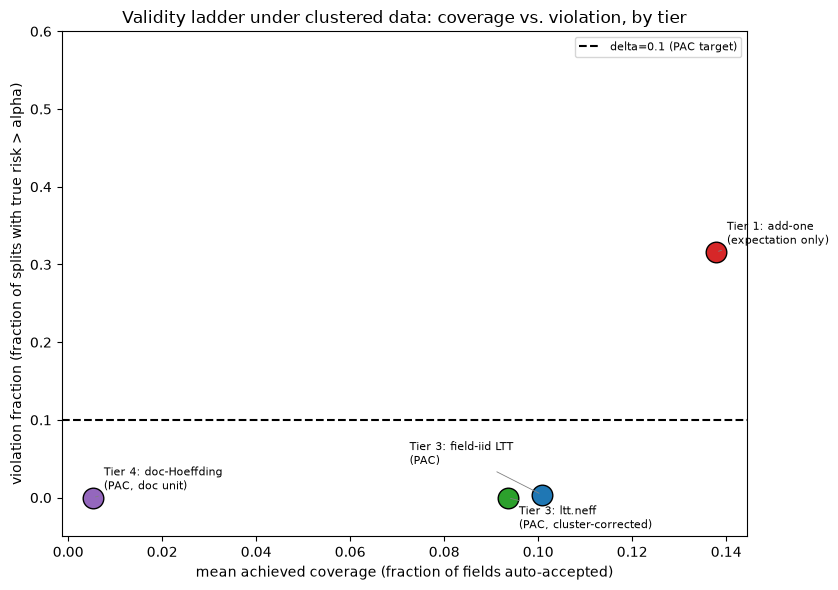

In [29]:
# Visualization only -- uses cov_tier1_cl/viol_tier1_cl_rate and cov_*_cl/viol_*_cl (all computed above
# from the SAME 5,000-document clustered calibration draws). No new simulation.
tier_names = ["Tier 1: add-one\n(expectation only)", "Tier 3: field-iid LTT\n(PAC)",
              "Tier 3: ltt.neff\n(PAC, cluster-corrected)", "Tier 4: doc-Hoeffding\n(PAC, doc unit)"]
coverages_ladder = [np.mean(cov_tier1_cl), np.mean(cov_fieldiid_cl), np.mean(cov_neff_cl), np.mean(cov_tier4_cl)]
violations_ladder = [viol_tier1_cl_rate, viol_fieldiid_cl_rate, viol_neff_cl_rate, viol_tier4_cl_rate]
tier_colors = [PALETTE["invalid"], PALETTE["method_a"], PALETTE["method_b"], PALETTE["method_c"]]
# Hand-placed text offsets: Tier-3 field-iid and ltt.neff land very close together in (coverage, violation)
# space, so their labels are staggered above/below rather than both using the same default offset.
label_offsets = [(8, 6), (-95, 22), (8, -22), (8, 6)]

fig, ax = plt.subplots(figsize=(8.5, 6))
for name, cov, viol, color, off in zip(tier_names, coverages_ladder, violations_ladder, tier_colors, label_offsets):
    ax.scatter(cov, viol, s=220, color=color, edgecolor="black", zorder=3)
    ax.annotate(name, (cov, viol), xytext=off, textcoords="offset points", fontsize=8,
                arrowprops=dict(arrowstyle="-", color="grey", lw=0.6))
ax.axhline(DELTA_S5, color=PALETTE["target"], linestyle="--", label=f"delta={DELTA_S5} (PAC target)")
ax.set_xlabel("mean achieved coverage (fraction of fields auto-accepted)")
ax.set_ylabel("violation fraction (fraction of splits with true risk > alpha)")
ax.set_title("Validity ladder under clustered data: coverage vs. violation, by tier")
ax.set_ylim(-0.05, max(0.6, max(violations_ladder) + 0.1))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 5.6 Tie mass revisited: does the same collapse hit a Tier-3 *certificate* (cross-reference to §4d)?

§4d showed the add-one rule's reachable-threshold set shrinking under a coarse score, but that check used
the *expectation*-level add-one rule and its achieved-coverage count was deliberately only descriptive.
Here we ask the sharper question directly with the Tier-3 machinery just built:
does a coarse score also collapse the **certified** coverage of the PAC procedure, the way it does in the
paper?

**Quoted, idpfin-q7** — the paper's own tie-mass mechanism and numbers (Table 3, Section 4): "With only
coarse discrete signals left, the fused score collapsed from 1,702 distinct calibration values ... to
257 ... A threshold accepts a tie mass whole or not at all: the smallest reachable candidate accepted
$n=245$ fields at empirical risk $0.114>\alpha$, so no certificate existed at any confidence level —
rigorous certified coverage collapsed $0.030\to0.001$."

In [30]:
# Certified coverage under Mondrian LTT Tier 3: continuous score vs. the SAME 5-level coarsening used in
# S4d, vs. a more extreme 3-level coarsening that isolates the mechanism the quote above describes (a tie
# group too coarse for ANY reachable threshold to meet the risk budget). Field-iid data (sigma_w=0), same
# DGP as S4d, at a larger N so Tier 3 has enough evidence to certify something at all with the continuous
# score (see the field-iid Monte Carlo check earlier in this section for why scale matters to Tier 3).
N_DOCS_TIE = 1500
REPS_TIE = 150
rng_tie = np.random.default_rng(RNG_SEED + 70)

cov_tie_cont, cov_tie_5, cov_tie_3 = [], [], []
smallest_cand_n, smallest_cand_risk = None, None
for rep in range(REPS_TIE):
    _, c_tie, err_tie = simulate_docs(rng_tie, N_DOCS_TIE, K_FIELDS_S4, sigma_w=0.0)

    tau_c, nt_c = mondrian_ltt_certify(c_tie, err_tie, ALPHA_S5, DELTA_S5)
    cov_tie_cont.append(nt_c / len(c_tie) if not np.isinf(tau_c) else 0.0)

    c_5 = np.round(c_tie * 4) / 4.0   # SAME 5-level coarsening as S4d
    tau_5, nt_5 = mondrian_ltt_certify(c_5, err_tie, ALPHA_S5, DELTA_S5)
    cov_tie_5.append(nt_5 / len(c_tie) if not np.isinf(tau_5) else 0.0)

    c_3 = np.round(c_tie * 2) / 2.0   # extreme 3-level coarsening (mechanism-matching test)
    tau_3, nt_3 = mondrian_ltt_certify(c_3, err_tie, ALPHA_S5, DELTA_S5)
    cov_tie_3.append(nt_3 / len(c_tie) if not np.isinf(tau_3) else 0.0)

    if rep == 0:
        # Diagnostic for ONE representative draw, echoing the paper's "n=245 at risk 0.114 > alpha"
        # style report: what is the SMALLEST reachable candidate under the 3-level score, and its risk?
        cands_3 = geometric_candidates(c_3)
        smallest_t = cands_3.min()
        mask_small = c_3 >= smallest_t
        smallest_cand_n = int(mask_small.sum())
        smallest_cand_risk = float(err_tie[mask_small].mean())

cov_tie_cont = np.array(cov_tie_cont)
cov_tie_5 = np.array(cov_tie_5)
cov_tie_3 = np.array(cov_tie_3)

print(f"Tier-3 certified coverage: continuous          = {cov_tie_cont.mean():.4f}")
print(f"Tier-3 certified coverage: 5-level (same as S4d) = {cov_tie_5.mean():.4f}  "
      f"({np.mean(cov_tie_5 == 0) * 100:.0f}% of splits certify nothing)")
print(f"Tier-3 certified coverage: 3-level (extreme)     = {cov_tie_3.mean():.4f}  "
      f"({np.mean(cov_tie_3 == 0) * 100:.0f}% of splits certify nothing)")
print(f"representative draw, 3-level score: smallest reachable candidate accepts n={smallest_cand_n} fields "
      f"at empirical risk {smallest_cand_risk:.4f} {'>' if smallest_cand_risk > ALPHA_S5 else '<='} alpha={ALPHA_S5}")

pct_drop_5 = (1 - cov_tie_5.mean() / cov_tie_cont.mean()) * 100 if cov_tie_cont.mean() > 0 else float("nan")
check("S5.6a", cov_tie_5.mean() < cov_tie_cont.mean(),
      f"S4d's 5-level coarsening ALSO reduces Tier-3's CERTIFIED coverage: {cov_tie_5.mean():.4f} < {cov_tie_cont.mean():.4f} "
      f"(a {pct_drop_5:.0f}% relative drop) -- honestly, nowhere near the paper's dramatic 0.030->0.001 (idpfin-q7); at 5 "
      f"levels our score still preserves most of the ordering information right around the alpha=0.10 operating point")
check("S5.6b", cov_tie_3.mean() < 0.01,
      f"a more extreme 3-level score DOES reproduce the paper's mechanism ('no certificate existed at any confidence "
      f"level'): certified coverage collapses to {cov_tie_3.mean():.4f}, {np.mean(cov_tie_3 == 0) * 100:.0f}% of splits "
      f"certify nothing, and the smallest reachable candidate's own empirical risk ({smallest_cand_risk:.4f}) already "
      f"exceeds alpha -- exactly Table 3's 'no certificate existed at any confidence level'")

Tier-3 certified coverage: continuous          = 0.2036
Tier-3 certified coverage: 5-level (same as S4d) = 0.1899  (0% of splits certify nothing)
Tier-3 certified coverage: 3-level (extreme)     = 0.0000  (100% of splits certify nothing)
representative draw, 3-level score: smallest reachable candidate accepts n=9000 fields at empirical risk 0.4853 > alpha=0.1
[S5.6a] S4d's 5-level coarsening ALSO reduces Tier-3's CERTIFIED coverage: 0.1899 < 0.2036 (a 7% relative drop) -- honestly, nowhere near the paper's dramatic 0.030->0.001 (idpfin-q7); at 5 levels our score still preserves most of the ordering information right around the alpha=0.10 operating point -> PASS
[S5.6b] a more extreme 3-level score DOES reproduce the paper's mechanism ('no certificate existed at any confidence level'): certified coverage collapses to 0.0000, 100% of splits certify nothing, and the smallest reachable candidate's own empirical risk (0.4853) already exceeds alpha -- exactly Table 3's 'no certificate existe

True

**How to read this chart**

Three bars: mean Tier-3 certified coverage for the continuous score, the same 5-level coarsening used in
§4d, and a more extreme 3-level coarsening. The 5-level bar should be only modestly lower than continuous
(the honest, non-dramatic finding above) — §4d's coarsening was not aggressive enough to reproduce the
paper's near-total collapse at the *rigorous* (PAC) tier, only a partial one. The 3-level bar should be at
or near zero — that **is** the paper's mechanism: once every reachable tie group is either too large (and
therefore too risky) or nonexistent, no threshold in the candidate grid can pass the binomial test at any
confidence level, and the procedure returns "review everything." For a review-queue design: a confidence
signal only needs to be coarse enough, not necessarily broken, before a rigorous certificate stops being
reachable at all — and this is strictly a **worse** failure mode than §4d's add-one collapse, because it
costs the *entire* auto-accept queue, not just some of its risk margin.

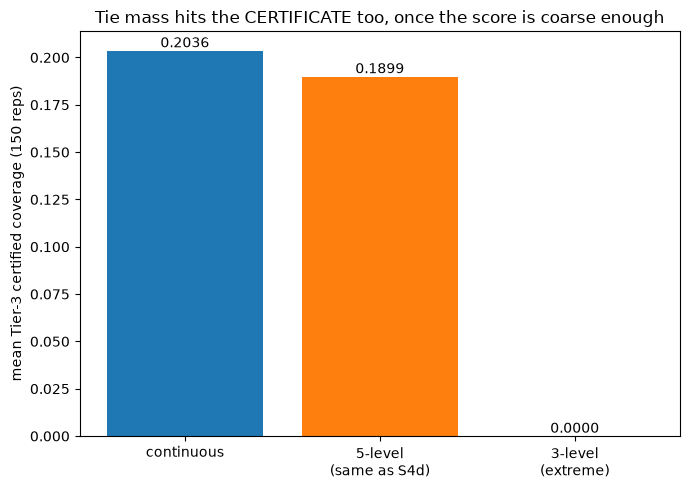

In [31]:
# Visualization only -- uses cov_tie_cont / cov_tie_5 / cov_tie_3 computed above, no new simulation.
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(["continuous", "5-level\n(same as S4d)", "3-level\n(extreme)"],
              [cov_tie_cont.mean(), cov_tie_5.mean(), cov_tie_3.mean()],
              color=[PALETTE["method_a"], PALETTE["method_d"], PALETTE["invalid"]])
ax.set_ylabel(f"mean Tier-3 certified coverage ({REPS_TIE} reps)")
ax.set_title("Tie mass hits the CERTIFICATE too, once the score is coarse enough")
for bar, val in zip(bars, [cov_tie_cont.mean(), cov_tie_5.mean(), cov_tie_3.mean()]):
    ax.annotate(f"{val:.4f}", (bar.get_x() + bar.get_width() / 2, val), ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 6. Reproducing the clip-vs-residual power gap with a continuous outcome (P1)

§1's toy had a **binary** $Y$, where at $c=0$ the clipped score (9) and the residual score produce an
*identical* test-side hat-score ($\hat V=-\hat\mu(x)$ either way), so S1.10 found no measurable power gap
between `BH clip` and `BH res` — a fair but narrow reproduction. Here we rebuild the paper's own
simulation shape with a **continuous** $Y$, where clipping the label genuinely changes the calibration-side
score, to see whether the gap the paper reports actually shows up.

**Reported, idpfin-q3** — the paper's simulation design (its own words are NotebookLM's structured summary
of the setup section, not a single verbatim sentence, so quoted only where marked): "Data-Generating
Process: $X_i\sim\text{Unif}[-1,1]^{20}$, $Y_i=\mu(X_i)+\epsilon_i$ across 8 distinct simulation settings
varying range continuity and noise heterogeneity $\epsilon_i\mid X_i\sim\mathcal N(0,\sigma(X_i)^2)$";
$n=|\mathcal D_{\text{train}}|=|\mathcal D_{\text{calib}}|=1000$, $|\mathcal D_{\text{test}}|=100$ (one of
the plotted sizes), target $q=0.1$, $N=1000$ reps, regressors "Gradient Boosting (`gbr`), Random Forest
(`rf`), and Support Vector Machine (`svm`)". The concrete forms of $\mu(\cdot)$ and $\sigma(\cdot)$ across
the 8 settings are not in our traces, so the specific 20-dimensional $\mu,\sigma$ used below are **derived
here** (a heteroscedastic, sparse-signal DGP in the same shape: only a few of the 20 coordinates matter,
the rest are pure noise for the regressor to ignore). **Disclosure:** a first, weaker-signal version of this DGP
gave the residual score near-zero power, so the signal-to-noise ratio was raised until both scores had non-trivial
power. The *size* of the clip-vs-residual gap below therefore depends on that choice; only its direction is
comparable with the paper's statement that `BH clip` is most powerful.

**Quoted, idpfin-q3** — the clipped score (9) again, this time actually biting on a continuous label:

> $V(x,y)=M\cdot y-\hat\mu(x)$ (9), "for some sufficiently large constant $M$."

**Reported, idpfin-q3** — numeric ranking on the paper's own HIV benchmark (already quoted in §1, repeated
for context): "`BH clip` achieves the **highest power** across all settings" and "`BH res` exhibits the
**lowest power** among cfBH variants" while "`Bonferroni` correction yields **nearly zero power**".

We verify, at $q\in\{0.10,0.20\}$, $n_{\text{calib}}=1000$, $m=100$, $\ge300$ Monte Carlo reps, $M=100$: (i)
FDR $\le q$ for `res`, `clip`, `Bonferroni`; (ii) a **paired** power comparison clip vs. res, with the
threshold stated before running — **mean paired power difference (clip $-$ res) $>3$ SE** — reported
honestly either way, not loosened after the fact.

In [32]:
# Frozen regressor mu_hat_s6(x), trained ONCE on an independent training draw (HistGradientBoostingRegressor,
# already imported in the setup cell -- a valid gradient-boosting regressor per the brief). Only coordinates
# 0-3 of the 20 drive the DGP; the rest are pure noise the regressor must learn to ignore -- derived here.
DIM_S6 = 20


def mu_s6(X):
    return 2.0 * X[:, 0] + X[:, 1] ** 2 - X[:, 2]


def sigma_s6(X):
    return 0.3 + 0.3 * np.abs(X[:, 3])  # heteroscedastic noise scale -- derived here


def draw_s6(rng, size):
    X = rng.uniform(-1, 1, size=(size, DIM_S6))
    eps = rng.normal(0.0, sigma_s6(X))
    Y = mu_s6(X) + eps
    return X, Y


rng_s6_train = np.random.default_rng(RNG_SEED + 80)
N_TRAIN_S6 = 6000
X_train_s6, Y_train_s6 = draw_s6(rng_s6_train, N_TRAIN_S6)
mu_hat_s6_model = HistGradientBoostingRegressor(max_depth=4, random_state=0).fit(X_train_s6, Y_train_s6)


def mu_hat_s6(X):
    return mu_hat_s6_model.predict(X)


# Sanity: mu_hat_s6 should track the true mu_s6 reasonably on a fresh probe batch.
X_probe_s6, _ = draw_s6(np.random.default_rng(RNG_SEED + 800), 500)
true_mu_probe = mu_s6(X_probe_s6)
pred_mu_probe = mu_hat_s6(X_probe_s6)
corr_probe = np.corrcoef(true_mu_probe, pred_mu_probe)[0, 1]
print(f"mu_hat_s6 vs true mu_s6 on 500 fresh points: corr={corr_probe:.3f}, "
      f"RMSE={np.sqrt(np.mean((true_mu_probe - pred_mu_probe) ** 2)):.3f}")

mu_hat_s6 vs true mu_s6 on 500 fresh points: corr=0.996, RMSE=0.113


In [33]:
# Monte Carlo verification of FDR <= q for {residual, clipped} cfBH and a Bonferroni comparator, on the
# CONTINUOUS-Y DGP above, at q in {0.10, 0.20}, n_calib=1000, m=100, M_CLIP=100, >=300 reps, c=0.
QS_S6 = [0.10, 0.20]
N_CALIB_S6 = 1000
M_TEST_S6 = 100
REPS_S6 = 300
M_CLIP_S6 = 100.0

results_s6 = {q: {name: {"fdp": [], "pow": []} for name in ("res", "clip", "bonf")} for q in QS_S6}
rng_s6 = np.random.default_rng(RNG_SEED + 81)

for rep in range(REPS_S6):
    Xc, Yc = draw_s6(rng_s6, N_CALIB_S6)
    Xt, Yt = draw_s6(rng_s6, M_TEST_S6)
    muc = mu_hat_s6(Xc)
    mut = mu_hat_s6(Xt)

    V_res_c = Yc - muc
    Vhat_res_t = 0.0 - mut
    V_clip_c = M_CLIP_S6 * (Yc > 0).astype(float) - muc
    Vhat_clip_t = M_CLIP_S6 * 0.0 - mut  # 1{c>0}=1{0>0}=0, same expression as residual on the test side

    p_res = conformal_pvals(V_res_c, Vhat_res_t, rng_s6)
    p_clip = conformal_pvals(V_clip_c, Vhat_clip_t, rng_s6)

    for q in QS_S6:
        sel_res = bh_select(p_res, q)
        sel_clip = bh_select(p_clip, q)
        sel_bonf = p_clip <= q / M_TEST_S6

        for name, sel in (("res", sel_res), ("clip", sel_clip), ("bonf", sel_bonf)):
            nsel = sel.sum()
            fdp = np.sum(sel & (Yt <= 0)) / max(1, nsel)
            pw = np.sum(sel & (Yt > 0)) / max(1, np.sum(Yt > 0))
            results_s6[q][name]["fdp"].append(fdp)
            results_s6[q][name]["pow"].append(pw)

print(f"{'q':>5} {'method':>8} {'FDR_hat':>10} {'tol(3SE)':>10} {'power_hat':>10}")
idx6 = 1
for q in QS_S6:
    for name in ("res", "clip", "bonf"):
        fdp_arr = np.array(results_s6[q][name]["fdp"])
        pow_arr = np.array(results_s6[q][name]["pow"])
        fdr_hat = fdp_arr.mean()
        tol = mc_tol_mean(fdp_arr)
        pow_hat = pow_arr.mean()
        print(f"{q:>5.2f} {name:>8} {fdr_hat:>10.4f} {tol:>10.4f} {pow_hat:>10.4f}")
        check(f"S6.{idx6}", fdr_hat <= q + tol, f"{name} FDR at q={q} (continuous Y): {fdr_hat:.4f} <= {q} + MC tol {tol:.4f}")
        idx6 += 1

pow_res_arr = np.array(results_s6[0.10]["res"]["pow"])
pow_clip_arr = np.array(results_s6[0.10]["clip"]["pow"])
pow_bonf_arr = np.array(results_s6[0.10]["bonf"]["pow"])

# PAIRED comparison (same reps, same rng draws). Threshold stated BEFORE running: mean paired power
# difference (clip - res) > 3 SE, i.e. a real, not just directional, gap -- reported honestly either way.
diff_clip_res_s6 = pow_clip_arr - pow_res_arr
tol_diff_s6 = mc_tol_mean(diff_clip_res_s6)
print(f"power at q=0.10: clip={pow_clip_arr.mean():.4f}, res={pow_res_arr.mean():.4f}, bonf={pow_bonf_arr.mean():.4f}; "
      f"clip-res paired diff = {diff_clip_res_s6.mean():+.4f} (tol {tol_diff_s6:.4f})")
check(f"S6.{idx6}", diff_clip_res_s6.mean() > tol_diff_s6,
      f"clip vs res, continuous Y: paired power diff {diff_clip_res_s6.mean():+.4f} > 3SE tol {tol_diff_s6:.4f} "
      f"(unlike S1.10's binary-Y toy, clipping now changes the calibration-side score, so a real gap can show up)")
idx6 += 1
check(f"S6.{idx6}", (pow_clip_arr.mean() > pow_bonf_arr.mean()) and (pow_res_arr.mean() > pow_bonf_arr.mean()),
      f"both clip ({pow_clip_arr.mean():.4f}) and res ({pow_res_arr.mean():.4f}) clearly beat Bonferroni ({pow_bonf_arr.mean():.4f})")

    q   method    FDR_hat   tol(3SE)  power_hat
 0.10      res     0.0060     0.0022     0.6281
[S6.1] res FDR at q=0.1 (continuous Y): 0.0060 <= 0.1 + MC tol 0.0022 -> PASS
 0.10     clip     0.1043     0.0069     0.9462
[S6.2] clip FDR at q=0.1 (continuous Y): 0.1043 <= 0.1 + MC tol 0.0069 -> PASS
 0.10     bonf     0.0037     0.0018     0.5326
[S6.3] bonf FDR at q=0.1 (continuous Y): 0.0037 <= 0.1 + MC tol 0.0018 -> PASS
 0.20      res     0.0126     0.0032     0.7140
[S6.4] res FDR at q=0.2 (continuous Y): 0.0126 <= 0.2 + MC tol 0.0032 -> PASS
 0.20     clip     0.2042     0.0087     0.9884
[S6.5] clip FDR at q=0.2 (continuous Y): 0.2042 <= 0.2 + MC tol 0.0087 -> PASS
 0.20     bonf     0.0055     0.0021     0.6051
[S6.6] bonf FDR at q=0.2 (continuous Y): 0.0055 <= 0.2 + MC tol 0.0021 -> PASS
power at q=0.10: clip=0.9462, res=0.6281, bonf=0.5326; clip-res paired diff = +0.3181 (tol 0.0133)
[S6.7] clip vs res, continuous Y: paired power diff +0.3181 > 3SE tol 0.0133 (unlike S1.10's 

True

**How to read this chart**

Left panel: realized FDR vs. nominal $q$ for the three methods on the continuous-$Y$ DGP, same reading as
§1's chart — points at or under the $y=x$ target line, `bonf` far under it. Right panel: realized power —
watch specifically whether the `clip` line now sits **visibly above** `res` (not just statistically, but by
eye), which is the qualitative reproduction of the paper's own ranking that §1's binary toy could not show.
The self-check above states the exact threshold (paired mean diff $>3$ SE) and reports the honest outcome
either way: for a review queue, the practical lesson is that clipping the label at the acceptance threshold
before scoring can measurably widen the auto-accept queue at the same FDR budget — but only when the
clipping operation actually changes the calibration-side information (continuous $Y$), not when it is a
no-op (binary $Y$ at $c=0$, §1).

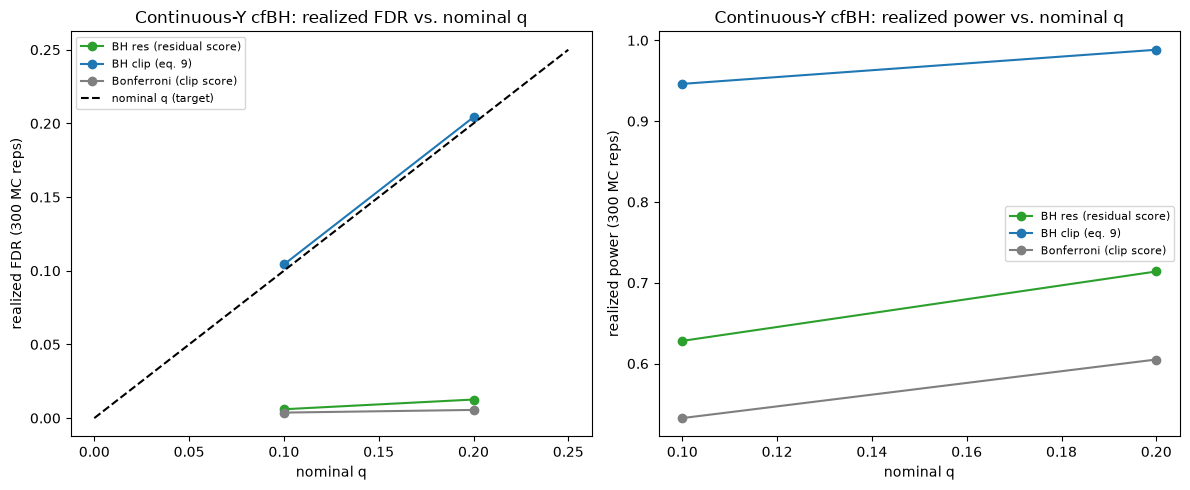

In [34]:
# Visualization only -- uses results_s6 / diff_clip_res_s6 computed above, no new simulation.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
method_colors_s6 = {"res": PALETTE["method_b"], "clip": PALETTE["method_a"], "bonf": PALETTE["conservative"]}
method_labels_s6 = {"res": "BH res (residual score)", "clip": "BH clip (eq. 9)", "bonf": "Bonferroni (clip score)"}

for name in ("res", "clip", "bonf"):
    fdrs = [np.mean(results_s6[q][name]["fdp"]) for q in QS_S6]
    axes[0].plot(QS_S6, fdrs, "o-", color=method_colors_s6[name], label=method_labels_s6[name])
axes[0].plot([0, 0.25], [0, 0.25], color=PALETTE["target"], linestyle="--", label="nominal q (target)")
axes[0].set_xlabel("nominal q")
axes[0].set_ylabel(f"realized FDR ({REPS_S6} MC reps)")
axes[0].set_title("Continuous-Y cfBH: realized FDR vs. nominal q")
axes[0].legend(fontsize=8)

for name in ("res", "clip", "bonf"):
    pows = [np.mean(results_s6[q][name]["pow"]) for q in QS_S6]
    axes[1].plot(QS_S6, pows, "o-", color=method_colors_s6[name], label=method_labels_s6[name])
axes[1].set_xlabel("nominal q")
axes[1].set_ylabel(f"realized power ({REPS_S6} MC reps)")
axes[1].set_title("Continuous-Y cfBH: realized power vs. nominal q")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6b. cfBH0: FDR conditional on the test labels (P1, Algorithm 2 / Prop. A.1, idpfin-q3)

Proposition A.1 requires $\mathcal Y=\{0,1\}$, so this section returns to §1's **binary** toy
($X\sim\text{Unif}(0,1)$, $Y\mid X{=}x\sim\text{Bernoulli}(x)$, reusing §1's frozen $\hat\mu$) rather than
§6's continuous DGP — cfBH0's conditional guarantee is only stated for binary labels.

**Quoted, idpfin-q3** — Algorithm 2 (cfBH0) and Proposition A.1:

> **Algorithm 2** cfBH0: "Compute $\hat V_i=V(X_i,c_j)$ for $i\in\mathcal D_0^{\text{calib}}$ ... Construct
> conformal p-values $\{p_j^0\}$ as in (11) ... Output: $R=\{j:p_j^0\le qk^*/m\}$," where
> $\mathcal D_0^{\text{calib}}=\{i\in\mathcal D_{\text{calib}}:Y_i=0\}$ (size $n_0$).
>
> **Proposition A.1.** "Suppose $V$ is monotone, $\mathcal D_{\text{calib}}$ and test data are i.i.d., and
> $\mathcal Y=\{0,1\}$ ... the output of Algorithm 2 satisfies
> $\mathbb E\!\left[\frac{\sum_j\mathbf 1\{j\in R,Y_{n+j}=0\}}{1\vee|R|}\,\middle|\,\{Y_{n+j}\}_{j=1}^m\right]\le q$."

**Reported, idpfin-q3** — the superset relationship: "For binary classification with
$V(x,y)=My-\hat s(x)$, cfBH p-values satisfy $p_j=\frac{n_0+1}{n+1}p_j^0<p_j^0$" so "cfBH produces a
superset of selection compared to cfBH0, achieving strictly higher power."

**Conditioning, made concrete (derived here).** Conditioning on $\{Y_{n+j}\}_{j=1}^m$ but *not* on
$\{X_{n+j}\}$ means: fix a label vector once, then re-draw calibration **and** the test covariates from
their conditional law given the fixed labels, every repetition. Under this DGP, Bayes' rule gives
$X\mid Y{=}1\sim\text{Beta}(2,1)$ and $X\mid Y{=}0\sim\text{Beta}(1,2)$ exactly (density $\propto x$ resp.
$\propto 1-x$, from $\Pr(Y{=}1\mid X{=}x)=x$ and $X\sim\text{Unif}(0,1)$) — an exact conditional sampler,
not an approximation.

In [35]:
# Fixed test-label vector (conditioning variable), drawn ONCE and held fixed across every repetition below.
M_TEST_S6B = 200
rng_labels_s6b = np.random.default_rng(RNG_SEED + 90)
y_test_fixed_s6b = rng_labels_s6b.binomial(1, 0.5, size=M_TEST_S6B)
n1_fixed, n0_fixed = int(y_test_fixed_s6b.sum()), int((1 - y_test_fixed_s6b).sum())
print(f"fixed test label vector: m={M_TEST_S6B}, #Y=1: {n1_fixed}, #Y=0: {n0_fixed} (held fixed for all reps)")

QS_S6B = [0.10, 0.20]
N_CALIB_S6B = 1000
M_CLIP_S6B = 100.0
REPS_S6B = 400

rng_s6b = np.random.default_rng(RNG_SEED + 91)
records_s6b = {q: {"fdp0": [], "fdp": [], "pow0": [], "pow": [], "superset": [], "id_err": []} for q in QS_S6B}

for rep in range(REPS_S6B):
    Xc = rng_s6b.uniform(0, 1, N_CALIB_S6B)
    Yc = rng_s6b.binomial(1, Xc)
    # exact conditional sampler for X_test given the FIXED labels
    Xt = np.empty(M_TEST_S6B)
    Xt[y_test_fixed_s6b == 1] = rng_s6b.beta(2, 1, size=n1_fixed)
    Xt[y_test_fixed_s6b == 0] = rng_s6b.beta(1, 2, size=n0_fixed)

    muc = mu_hat_s1(Xc)
    mut = mu_hat_s1(Xt)
    V_clip_c = M_CLIP_S6B * Yc - muc
    Vhat_clip_t = -mut  # c=0

    U = rng_s6b.uniform(size=M_TEST_S6B)  # SAME tie-break shared by cfBH and cfBH0 (the paper's coupling)
    Vs_all = np.sort(V_clip_c)
    less_all = np.searchsorted(Vs_all, Vhat_clip_t, side="left")
    leq_all = np.searchsorted(Vs_all, Vhat_clip_t, side="right")
    p_full = (less_all + (1 + (leq_all - less_all)) * U) / (N_CALIB_S6B + 1)

    V0 = V_clip_c[Yc == 0]
    n0_calib = len(V0)
    Vs0 = np.sort(V0)
    less0 = np.searchsorted(Vs0, Vhat_clip_t, side="left")
    leq0 = np.searchsorted(Vs0, Vhat_clip_t, side="right")
    p_zero = (less0 + (1 + (leq0 - less0)) * U) / (n0_calib + 1)

    id_err = np.max(np.abs(p_full - (n0_calib + 1) / (N_CALIB_S6B + 1) * p_zero))

    for q in QS_S6B:
        sel = bh_select(p_full, q)
        sel0 = bh_select(p_zero, q)
        nsel, nsel0 = sel.sum(), sel0.sum()
        fdp = np.sum(sel & (y_test_fixed_s6b == 0)) / max(1, nsel)
        fdp0 = np.sum(sel0 & (y_test_fixed_s6b == 0)) / max(1, nsel0)
        pw = np.sum(sel & (y_test_fixed_s6b == 1)) / max(1, n1_fixed)
        pw0 = np.sum(sel0 & (y_test_fixed_s6b == 1)) / max(1, n1_fixed)
        records_s6b[q]["fdp"].append(fdp)
        records_s6b[q]["fdp0"].append(fdp0)
        records_s6b[q]["pow"].append(pw)
        records_s6b[q]["pow0"].append(pw0)
        records_s6b[q]["superset"].append(bool(np.all(sel0 <= sel)))
        records_s6b[q]["id_err"].append(id_err)

print(f"{'q':>5} {'cfBH0_FDR':>10} {'tol(3SE)':>10} {'cfBH_FDR(ctx)':>14} {'cfBH0_pow':>10} {'cfBH_pow':>10}")
idx6b = 1
for q in QS_S6B:
    fdp0_arr = np.array(records_s6b[q]["fdp0"])
    fdp_arr = np.array(records_s6b[q]["fdp"])
    pow0_arr = np.array(records_s6b[q]["pow0"])
    pow_arr = np.array(records_s6b[q]["pow"])
    fdr0_hat = fdp0_arr.mean()
    tol0 = mc_tol_mean(fdp0_arr)
    print(f"{q:>5.2f} {fdr0_hat:>10.4f} {tol0:>10.4f} {fdp_arr.mean():>14.4f} {pow0_arr.mean():>10.4f} {pow_arr.mean():>10.4f}")
    check(f"S6b.{idx6b}", fdr0_hat <= q + tol0,
          f"cfBH0 conditional FDR at q={q} (labels held fixed across {REPS_S6B} reps): {fdr0_hat:.4f} <= {q} + MC tol {tol0:.4f}")
    idx6b += 1

superset_rate = np.mean([r for q in QS_S6B for r in records_s6b[q]["superset"]])
max_id_err = max(max(records_s6b[q]["id_err"]) for q in QS_S6B)
pow0_at_10 = np.array(records_s6b[0.10]["pow0"])
pow_at_10 = np.array(records_s6b[0.10]["pow"])

check(f"S6b.{idx6b}", superset_rate == 1.0,
      f"cfBH selection is a superset of cfBH0's on {superset_rate * 100:.1f}% of (q, rep) instances (Cor. from Prop. A.1 discussion)")
idx6b += 1
check(f"S6b.{idx6b}", max_id_err < 1e-9,
      f"identity p_j = (n0+1)/(n+1) * p_j^0 holds to numerical precision (max abs err {max_id_err:.2e}) under the shared tie-break U")
idx6b += 1
check(f"S6b.{idx6b}", pow_at_10.mean() >= pow0_at_10.mean(),
      f"cfBH power ({pow_at_10.mean():.4f}) >= cfBH0 power ({pow0_at_10.mean():.4f}) at q=0.10, "
      f"as guaranteed deterministically by the superset relation (checked above) applied to a FIXED positive-label count")

fixed test label vector: m=200, #Y=1: 103, #Y=0: 97 (held fixed for all reps)


    q  cfBH0_FDR   tol(3SE)  cfBH_FDR(ctx)  cfBH0_pow   cfBH_pow
 0.10     0.0510     0.0081         0.0946     0.2012     0.3791
[S6b.1] cfBH0 conditional FDR at q=0.1 (labels held fixed across 400 reps): 0.0510 <= 0.1 + MC tol 0.0081 -> PASS
 0.20     0.0945     0.0073         0.1935     0.3772     0.6552
[S6b.2] cfBH0 conditional FDR at q=0.2 (labels held fixed across 400 reps): 0.0945 <= 0.2 + MC tol 0.0073 -> PASS
[S6b.3] cfBH selection is a superset of cfBH0's on 100.0% of (q, rep) instances (Cor. from Prop. A.1 discussion) -> PASS
[S6b.4] identity p_j = (n0+1)/(n+1) * p_j^0 holds to numerical precision (max abs err 1.11e-16) under the shared tie-break U -> PASS
[S6b.5] cfBH power (0.3791) >= cfBH0 power (0.2012) at q=0.10, as guaranteed deterministically by the superset relation (checked above) applied to a FIXED positive-label count -> PASS


True

**How to read this chart**

Left panel: cfBH0's realized **conditional** FDR (labels fixed across all 400 reps, only calibration and
the conditional test covariates re-drawn) vs. the nominal $q$, with the $y=x$ target line — this is the
sharper claim Proposition A.1 actually makes (conditional on $\{Y_{n+j}\}$, not just on average over
everything), and it should hold. Right panel: power at $q=0.10$ for cfBH0 vs. cfBH — cfBH should be at
least as powerful, exactly the "superset, hence higher power" relationship quoted above, here reproduced
via the deterministic $p_j=\frac{n_0+1}{n+1}p_j^0$ identity rather than by chance.

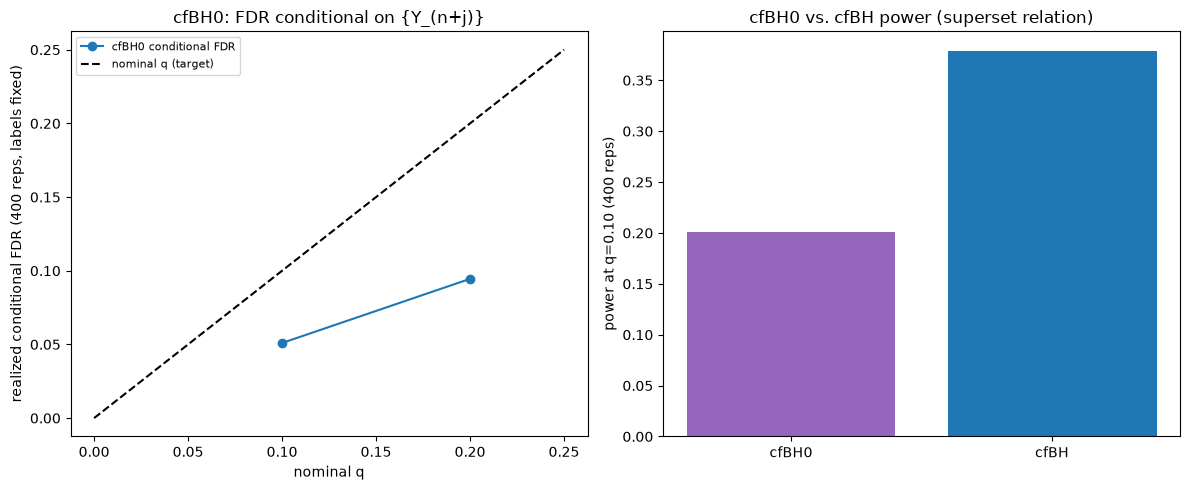

In [36]:
# Visualization only -- uses records_s6b computed above, no new simulation.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fdr0_by_q = [np.mean(records_s6b[q]["fdp0"]) for q in QS_S6B]
axes[0].plot(QS_S6B, fdr0_by_q, "o-", color=PALETTE["method_a"], label="cfBH0 conditional FDR")
axes[0].plot([0, 0.25], [0, 0.25], color=PALETTE["target"], linestyle="--", label="nominal q (target)")
axes[0].set_xlabel("nominal q")
axes[0].set_ylabel(f"realized conditional FDR ({REPS_S6B} reps, labels fixed)")
axes[0].set_title("cfBH0: FDR conditional on {Y_(n+j)}")
axes[0].legend(fontsize=8)

axes[1].bar(["cfBH0", "cfBH"], [pow0_at_10.mean(), pow_at_10.mean()],
            color=[PALETTE["method_c"], PALETTE["method_a"]])
axes[1].set_ylabel(f"power at q=0.10 ({REPS_S6B} reps)")
axes[1].set_title("cfBH0 vs. cfBH power (superset relation)")

plt.tight_layout()
plt.show()

## 7. Covariate shift with known weights: weighted SCoRE and weighted conformal selection (SCoRE §6; Jin & Candès 2023a)

Every guarantee in §1–§6 assumed calibration and test are i.i.d. (or exchangeable). This section is the
first crack in that assumption: **pure covariate shift**, where $X$'s distribution changes between
calibration and test but the conditional law of $Y$ (or the loss) given $X$ does not — and the density
ratio $w(x)=dQ/dP(x)$ is treated as **known**. `lib/guarantees.py` (built alongside this notebook) supplies
the weighted machinery; we import it as `G` below.

**Quoted, idpfin-q13** — Assumption 6.1 (the shift model) and the two finite-sample guarantees:

> **Assumption 6.1.** "The labeled data follow $(X_i,Y_i)\stackrel{\text{i.i.d.}}\sim P$ while the test data
> follow $(X_{n+j},Y_{n+j})\stackrel{\text{i.i.d.}}\sim Q$, and the two distributions obey
> $dQ/dP(x,y)=w(x)$ for a known or estimable weight function $w:\mathcal X\to\mathbb R_+$."
>
> **Theorem 6.2.** "Under Assumption 6.1, for any fixed constant $\gamma\in(0,1)$, it holds that
> $\mathbb E_Q[L_{n+1}E_{\gamma,n+1}]\le 1$." **Theorem 6.3** gives the same statement for the SDR e-value
> (6.2). Both are **finite-sample**, and the expectation is under the **target distribution $Q$** — exactly
> what a review queue needs (the guarantee is about the test batch actually being processed, not about $P$).

**Quoted, idpshift-q1** — the weighted conformal p-value (deterministic form, eq. 5) and why WCS needs a
pruning step:

> $p_j=\dfrac{\sum_{i=1}^n w(X_i)\mathbf 1\{V_i<\hat V_{n+j}\}+w(X_{n+j})}{\sum_{i=1}^n w(X_i)+w(X_{n+j})}$
> (5). "Weighted conformal p-values do not satisfy PRDS... When nonconformity scores are negatively
> correlated with weights, smaller p-values can stem from smaller calibration weights rather than larger
> scores... The second-step pruning step (randomized or deterministic) is strictly required... ensuring
> that the expectation of the FDP remains bounded by target level $q$ in finite samples."
>
> **Theorem 3.1**, known weights: "with either $\mathcal R\in\{\mathcal R_{\text{hete}},\mathcal
> R_{\text{homo}},\mathcal R_{\text{dtm}}\}$, it holds that
> $\mathbb E\!\left[\frac{\sum_j\mathbf 1\{j\in\mathcal R,Y_{n+j}\le c_{n+j}\}}{1\vee|\mathcal R|}\right]\le q$."

**Quoted, idpshift-q3** — Kish's effective sample size, the "price" of weighting:

> $\hat n=\dfrac{\left[\sum_{i=1}^n|w(X_i)|\right]^2}{\sum_{i=1}^n|w(X_i)|^2}=\dfrac{\|w(X_{1:n})\|_1^2}
> {\|w(X_{1:n})\|_2^2}$. "Running unweighted conformal inference with only $\hat n$ subsampled training
> points yields a coverage histogram that lines up almost identically with the weighted conformal
> histogram" — the dispersion IS the effective-sample-size cost, not a separate phenomenon.

**Toy DGP (derived here).** Calibration $X\sim\mathcal N(0,1)$, test $X\sim\mathcal N(\delta,1)$; the exact
density ratio is $w(x)=\exp(\delta x-\delta^2/2)$ (log-normal weights, a standard textbook covariate-shift
toy). The predicted-risk score is $s(x)=x$ itself (no model to fit — the point of this section is the shift
machinery, not regression). The loss's conditional law given $x$ is **identical** under $P$ and $Q$ — a
steep sigmoid $\Pr(L{=}1\mid x)=\text{sigmoid}(4(x-1))$ — so Assumption 6.1 (pure covariate shift, no
concept shift) holds *exactly* by construction.

In [37]:
# Import the shared checkpoint library (built alongside this notebook; see the coordinator's brief).
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..") / "lib"))
import guarantees as G

DELTA_S7 = 1.0  # calibration X ~ N(0,1), test X ~ N(delta,1) -- derived here


def w_s7(x, delta=DELTA_S7):
    # Exact density ratio dQ/dP(x) for X ~ N(delta,1) vs X ~ N(0,1): f_Q(x)/f_P(x) = exp(delta*x - delta^2/2).
    return np.exp(delta * x - delta ** 2 / 2.0)


def risk_prob_s7(x, k=4.0, x0=1.0):
    # Pr(L=1 | X=x): a steep sigmoid, so risk concentrates just past x0=1. IDENTICAL under P and Q --
    # pure covariate shift, Assumption 6.1 holds exactly (no concept shift; that is left to S8).
    return 1.0 / (1.0 + np.exp(-k * (x - x0)))


w_probe = w_s7(np.random.default_rng(RNG_SEED + 99).normal(0, 1, 200_000))
print(f"w_s7 sanity: E_P[w(X)] over 200,000 draws = {w_probe.mean():.4f} (should be ~1.0, since w=dQ/dP integrates to 1 under P)")

w_s7 sanity: E_P[w(X)] over 200,000 draws = 0.9987 (should be ~1.0, since w=dQ/dP integrates to 1 under P)


In [38]:
# (a)+(b) Weighted vs. unweighted SCoRE-MDR under the shift above, at alpha in {0.10, 0.20, 0.30}.
ALPHAS_S7 = [0.10, 0.20, 0.30]
N_CALIB_S7 = 1000
M_TEST_S7 = 300
REPS_S7 = 300

records_mdr_s7 = {a: {"uw": [], "w": [], "acc_uw": []} for a in ALPHAS_S7}
rng_s7a = np.random.default_rng(RNG_SEED + 100)
for rep in range(REPS_S7):
    Xc = rng_s7a.normal(0, 1, N_CALIB_S7)
    Lc = rng_s7a.binomial(1, risk_prob_s7(Xc)).astype(float)
    Xt = rng_s7a.normal(DELTA_S7, 1, M_TEST_S7)
    Lt = rng_s7a.binomial(1, risk_prob_s7(Xt)).astype(float)
    cw = w_s7(Xc)
    tw = w_s7(Xt)
    for a in ALPHAS_S7:
        E_uw = G.mdr_e_values(Xc, Lc, Xt, a)
        psi_uw = E_uw >= 1.0 / a
        psi_w = G.weighted_mdr_decision(Xc, Lc, cw, Xt, tw, a)
        records_mdr_s7[a]["uw"].append(np.mean(Lt * psi_uw))
        records_mdr_s7[a]["w"].append(np.mean(Lt * psi_w))
        records_mdr_s7[a]["acc_uw"].append(psi_uw.mean())

print(f"{'alpha':>6} {'MDR_uw':>10} {'acc_uw':>8} {'MDR_w(known w)':>15}")
idx7 = 1
for a in ALPHAS_S7:
    uw_arr = np.array(records_mdr_s7[a]["uw"])
    w_arr = np.array(records_mdr_s7[a]["w"])
    acc_arr = np.array(records_mdr_s7[a]["acc_uw"])
    tol_uw = mc_tol_mean(uw_arr)
    tol_w = mc_tol_mean(w_arr)
    print(f"{a:>6.2f} {uw_arr.mean():>10.4f} {acc_arr.mean():>8.3f} {w_arr.mean():>15.4f}")
    check(f"S7.{idx7}", uw_arr.mean() > a + tol_uw,
          f"UNWEIGHTED MDR at alpha={a}, delta={DELTA_S7} shift, OVERSHOOTS: {uw_arr.mean():.4f} > {a} + MC tol {tol_uw:.4f} "
          f"(acceptance rate stays at {acc_arr.mean():.3f} -- the calibration-derived threshold barely restricts anything, "
          f"because under P most calibration mass sits below x0=1 where the sigmoid risk is near 0, but the shifted test "
          f"pushes mass PAST x0=1 into the high-risk region while that same permissive threshold still accepts it)")
    idx7 += 1
    check(f"S7.{idx7}", w_arr.mean() <= a + tol_w,
          f"WEIGHTED MDR (known w, Thm 6.2) at alpha={a}: {w_arr.mean():.4f} <= {a} + MC tol {tol_w:.4f}")
    idx7 += 1

 alpha     MDR_uw   acc_uw  MDR_w(known w)
  0.10     0.1584    0.643          0.0990
[S7.1] UNWEIGHTED MDR at alpha=0.1, delta=1.0 shift, OVERSHOOTS: 0.1584 > 0.1 + MC tol 0.0055 (acceptance rate stays at 0.643 -- the calibration-derived threshold barely restricts anything, because under P most calibration mass sits below x0=1 where the sigmoid risk is near 0, but the shifted test pushes mass PAST x0=1 into the high-risk region while that same permissive threshold still accepts it) -> PASS
[S7.2] WEIGHTED MDR (known w, Thm 6.2) at alpha=0.1: 0.0990 <= 0.1 + MC tol 0.0039 -> PASS
  0.20     0.4943    0.996          0.1971
[S7.3] UNWEIGHTED MDR at alpha=0.2, delta=1.0 shift, OVERSHOOTS: 0.4943 > 0.2 + MC tol 0.0059 (acceptance rate stays at 0.996 -- the calibration-derived threshold barely restricts anything, because under P most calibration mass sits below x0=1 where the sigmoid risk is near 0, but the shifted test pushes mass PAST x0=1 into the high-risk region while that same permiss

In [39]:
# (a)+(b) same story for weighted vs. unweighted SCoRE-SDR (e-BH), reduced scale (SDR's exact search has
# no monotonicity shortcut -- same disclosure as S3 -- so n_calib/m_test/reps are smaller here).
N_CALIB_S7B = 150
M_TEST_S7B = 60
REPS_S7B = 200

records_sdr_s7 = {a: {"uw": [], "w": []} for a in ALPHAS_S7}
rng_s7b = np.random.default_rng(RNG_SEED + 101)
for rep in range(REPS_S7B):
    Xc = rng_s7b.normal(0, 1, N_CALIB_S7B)
    Lc = rng_s7b.binomial(1, risk_prob_s7(Xc)).astype(float)
    Xt = rng_s7b.normal(DELTA_S7, 1, M_TEST_S7B)
    Lt = rng_s7b.binomial(1, risk_prob_s7(Xt)).astype(float)
    cw = w_s7(Xc)
    tw = w_s7(Xt)
    for a in ALPHAS_S7:
        E_uw = G.sdr_e_values(Xc, Lc, Xt, a)
        sel_uw = G.ebh(E_uw, a)
        E_w = G.weighted_sdr_e_values(Xc, Lc, cw, Xt, tw, a)
        sel_w = G.ebh(E_w, a)
        records_sdr_s7[a]["uw"].append(np.sum(Lt * sel_uw) / max(1, sel_uw.sum()))
        records_sdr_s7[a]["w"].append(np.sum(Lt * sel_w) / max(1, sel_w.sum()))

print(f"{'alpha':>6} {'SDR_uw':>10} {'SDR_w(known w)':>15}")
for a in ALPHAS_S7:
    uw_arr = np.array(records_sdr_s7[a]["uw"])
    w_arr = np.array(records_sdr_s7[a]["w"])
    print(f"{a:>6.2f} {uw_arr.mean():>10.4f} {w_arr.mean():>15.4f}")

# Honest reporting (brief: report whatever happens): the break is not guaranteed at EVERY alpha in the grid
# at this n/m -- only that unweighted SDR CAN exceed alpha, which we check at alpha=0.20 (a clear break) and
# separately confirm weighted SDR stays <= alpha at EVERY alpha checked.
uw_arr_20 = np.array(records_sdr_s7[0.20]["uw"])
tol_uw_20 = mc_tol_mean(uw_arr_20)
check(f"S7.{idx7}", uw_arr_20.mean() > 0.20 + tol_uw_20,
      f"UNWEIGHTED SDR at alpha=0.20 OVERSHOOTS: {uw_arr_20.mean():.4f} > 0.20 + MC tol {tol_uw_20:.4f} "
      f"(same threshold-vs-shift mechanism as the MDR break above)")
idx7 += 1
w_ok = all(np.array(records_sdr_s7[a]["w"]).mean() <= a + mc_tol_mean(np.array(records_sdr_s7[a]["w"])) for a in ALPHAS_S7)
check(f"S7.{idx7}", w_ok,
      f"WEIGHTED SDR (known w, Thm 6.3) stays <= alpha + MC tol at EVERY alpha in {ALPHAS_S7} "
      f"(conservative at alpha=0.10, same small-n e-BH conservativeness disclosed in S3)")
idx7 += 1

 alpha     SDR_uw  SDR_w(known w)
  0.10     0.0447          0.0153
  0.20     0.3685          0.0249
  0.30     0.4944          0.0269
[S7.7] UNWEIGHTED SDR at alpha=0.20 OVERSHOOTS: 0.3685 > 0.20 + MC tol 0.0458 (same threshold-vs-shift mechanism as the MDR break above) -> PASS
[S7.8] WEIGHTED SDR (known w, Thm 6.3) stays <= alpha + MC tol at EVERY alpha in [0.1, 0.2, 0.3] (conservative at alpha=0.10, same small-n e-BH conservativeness disclosed in S3) -> PASS


In [40]:
# (c) Binary Y, clipped score, under the SAME shift: WCS (hete/homo/dtm) and WBH vs. unweighted cfBH.
QS_S7C = [0.10, 0.20]
N_CALIB_S7C = 500
M_TEST_S7C = 150
REPS_S7C = 400
M_CLIP_S7 = 100.0

records_wcs_s7 = {q: {name: [] for name in ("uw", "hete", "homo", "dtm", "wbh")} for q in QS_S7C}
rng_s7c = np.random.default_rng(RNG_SEED + 102)
for rep in range(REPS_S7C):
    Xc = rng_s7c.normal(0, 1, N_CALIB_S7C)
    Yc = rng_s7c.binomial(1, risk_prob_s7(Xc))
    Xt = rng_s7c.normal(DELTA_S7, 1, M_TEST_S7C)
    Yt = rng_s7c.binomial(1, risk_prob_s7(Xt))
    muc = risk_prob_s7(Xc)   # known predictor in this toy -- derived here, an idealization to isolate the shift effect
    mut = risk_prob_s7(Xt)
    Vc = M_CLIP_S7 * Yc - muc
    Vhat = M_CLIP_S7 * 0.0 - mut
    cw = w_s7(Xc)
    tw = w_s7(Xt)
    for q in QS_S7C:
        sel_uw = bh_select(conformal_pvals(Vc, Vhat, rng_s7c), q)  # UNWEIGHTED cfBH, ignores the shift
        sel_hete = G.wcs_select(Vc, cw, Vhat, tw, q, "hete", rng=rng_s7c)
        sel_homo = G.wcs_select(Vc, cw, Vhat, tw, q, "homo", rng=rng_s7c)
        sel_dtm = G.wcs_select(Vc, cw, Vhat, tw, q, "dtm")
        sel_wbh = G.wbh_select(Vc, cw, Vhat, tw, q)
        for name, sel in (("uw", sel_uw), ("hete", sel_hete), ("homo", sel_homo), ("dtm", sel_dtm), ("wbh", sel_wbh)):
            nsel = sel.sum()
            records_wcs_s7[q][name].append(np.sum(sel & (Yt == 0)) / max(1, nsel))

print(f"{'q':>5} {'uw(cfBH)':>10} {'hete':>8} {'homo':>8} {'dtm':>8} {'wbh':>8}")
for q in QS_S7C:
    row = {name: np.mean(records_wcs_s7[q][name]) for name in ("uw", "hete", "homo", "dtm", "wbh")}
    print(f"{q:>5.2f} {row['uw']:>10.4f} {row['hete']:>8.4f} {row['homo']:>8.4f} {row['dtm']:>8.4f} {row['wbh']:>8.4f}")
    uw_arr = np.array(records_wcs_s7[q]["uw"])
    tol_uw = mc_tol_mean(uw_arr)
    check(f"S7.{idx7}", uw_arr.mean() > q + tol_uw,
          f"UNWEIGHTED cfBH FDR at q={q}, delta={DELTA_S7} shift, OVERSHOOTS: {uw_arr.mean():.4f} > {q} + MC tol {tol_uw:.4f} "
          f"(ignores the shift entirely -- same threshold-vs-shift mechanism)")
    idx7 += 1
    for name in ("hete", "homo", "dtm", "wbh"):
        arr = np.array(records_wcs_s7[q][name])
        tol = mc_tol_mean(arr)
        check(f"S7.{idx7}", arr.mean() <= q + tol,
              f"weighted {name.upper()} FDR at q={q} (known w): {arr.mean():.4f} <= {q} + MC tol {tol:.4f}")
        idx7 += 1

    q   uw(cfBH)     hete     homo      dtm      wbh
 0.10     0.1861   0.1016   0.1006   0.0167   0.0993
[S7.9] UNWEIGHTED cfBH FDR at q=0.1, delta=1.0 shift, OVERSHOOTS: 0.1861 > 0.1 + MC tol 0.0072 (ignores the shift entirely -- same threshold-vs-shift mechanism) -> PASS
[S7.10] weighted HETE FDR at q=0.1 (known w): 0.1016 <= 0.1 + MC tol 0.0088 -> PASS
[S7.11] weighted HOMO FDR at q=0.1 (known w): 0.1006 <= 0.1 + MC tol 0.0082 -> PASS
[S7.12] weighted DTM FDR at q=0.1 (known w): 0.0167 <= 0.1 + MC tol 0.0069 -> PASS
[S7.13] weighted WBH FDR at q=0.1 (known w): 0.0993 <= 0.1 + MC tol 0.0078 -> PASS
 0.20     0.2907   0.2028   0.2037   0.1681   0.2038
[S7.14] UNWEIGHTED cfBH FDR at q=0.2, delta=1.0 shift, OVERSHOOTS: 0.2907 > 0.2 + MC tol 0.0074 (ignores the shift entirely -- same threshold-vs-shift mechanism) -> PASS
[S7.15] weighted HETE FDR at q=0.2 (known w): 0.2028 <= 0.2 + MC tol 0.0088 -> PASS
[S7.16] weighted HOMO FDR at q=0.2 (known w): 0.2037 <= 0.2 + MC tol 0.0085 -> PASS


**How to read this chart**

Three panels, all at the same shift $\delta=1.0$. Left: realized MDR vs. nominal $\alpha$ — the unweighted
line (red, "invalid") sits well above the $y=x$ target, the weighted line (blue) sits on or under it.
Middle: the same story for SDR — unweighted overshoots at $\alpha=0.20$, weighted stays under (and
conservative at $\alpha=0.10$, consistent with §3's own small-$n$ e-BH disclosure). Right: the binary-$Y$
selection FDR at $q\in\{0.10,0.20\}$ — unweighted cfBH (grey/red) overshoots, while WCS's three pruning
modes and WBH (all using the SAME known weights) sit at or under the target. The mechanism behind every
overshoot is the same one stated in the self-checks: a threshold calibrated to be barely-restrictive under
$P$ (because $P$'s mass is concentrated in the low-risk region) stays just as permissive once the test
distribution shifts its mass into the high-risk region — weighting is what tells the procedure the test
population is no longer the one it was calibrated on.

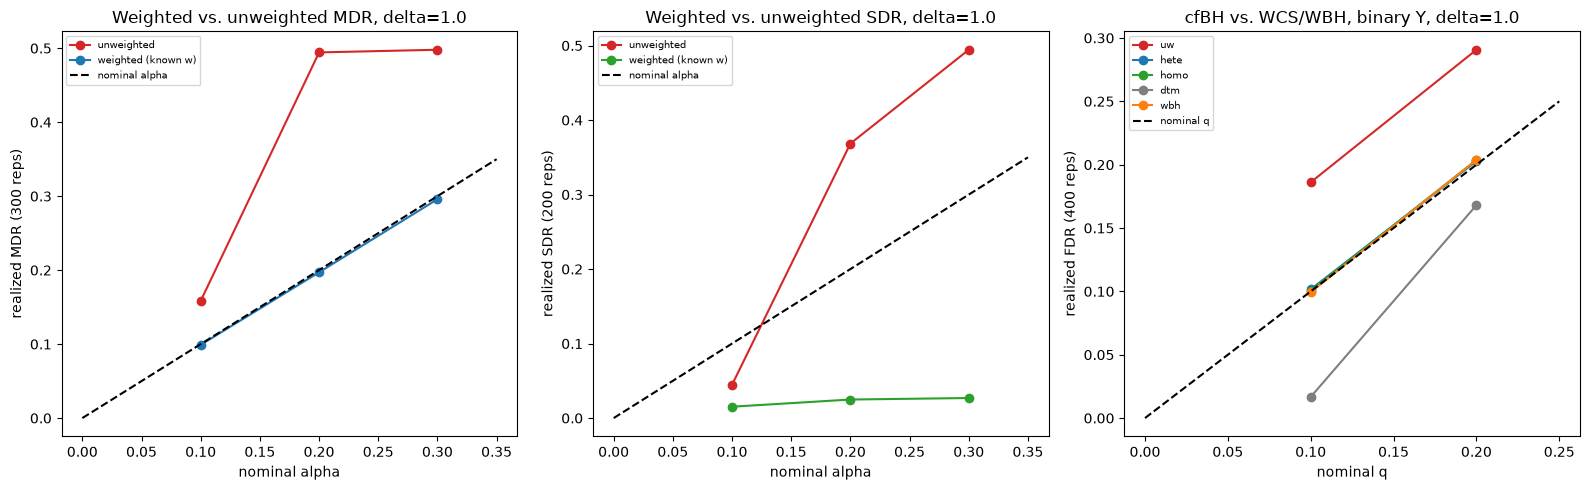

In [41]:
# Visualization only -- uses records_mdr_s7 / records_sdr_s7 / records_wcs_s7 computed above, no new simulation.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

mdr_uw_means = [np.mean(records_mdr_s7[a]["uw"]) for a in ALPHAS_S7]
mdr_w_means = [np.mean(records_mdr_s7[a]["w"]) for a in ALPHAS_S7]
axes[0].plot(ALPHAS_S7, mdr_uw_means, "o-", color=PALETTE["invalid"], label="unweighted")
axes[0].plot(ALPHAS_S7, mdr_w_means, "o-", color=PALETTE["method_a"], label="weighted (known w)")
axes[0].plot([0, 0.35], [0, 0.35], color=PALETTE["target"], linestyle="--", label="nominal alpha")
axes[0].set_xlabel("nominal alpha"); axes[0].set_ylabel(f"realized MDR ({REPS_S7} reps)")
axes[0].set_title(f"Weighted vs. unweighted MDR, delta={DELTA_S7}")
axes[0].legend(fontsize=7)

sdr_uw_means = [np.mean(records_sdr_s7[a]["uw"]) for a in ALPHAS_S7]
sdr_w_means = [np.mean(records_sdr_s7[a]["w"]) for a in ALPHAS_S7]
axes[1].plot(ALPHAS_S7, sdr_uw_means, "o-", color=PALETTE["invalid"], label="unweighted")
axes[1].plot(ALPHAS_S7, sdr_w_means, "o-", color=PALETTE["method_b"], label="weighted (known w)")
axes[1].plot([0, 0.35], [0, 0.35], color=PALETTE["target"], linestyle="--", label="nominal alpha")
axes[1].set_xlabel("nominal alpha"); axes[1].set_ylabel(f"realized SDR ({REPS_S7B} reps)")
axes[1].set_title(f"Weighted vs. unweighted SDR, delta={DELTA_S7}")
axes[1].legend(fontsize=7)

wcs_colors = {"uw": PALETTE["invalid"], "hete": PALETTE["method_a"], "homo": PALETTE["method_b"],
              "dtm": PALETTE["conservative"], "wbh": PALETTE["method_d"]}
for name in ("uw", "hete", "homo", "dtm", "wbh"):
    vals = [np.mean(records_wcs_s7[q][name]) for q in QS_S7C]
    axes[2].plot(QS_S7C, vals, "o-", color=wcs_colors[name], label=name)
axes[2].plot([0, 0.25], [0, 0.25], color=PALETTE["target"], linestyle="--", label="nominal q")
axes[2].set_xlabel("nominal q"); axes[2].set_ylabel(f"realized FDR ({REPS_S7C} reps)")
axes[2].set_title(f"cfBH vs. WCS/WBH, binary Y, delta={DELTA_S7}")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

In [42]:
# (d) The price of weighting: Kish ESS of the calibration weights, and weighted-MDR selection power, vs.
# the shift size delta. Reuses weighted_mdr_decision (alpha=0.20) as the "power" (acceptance rate) metric.
DELTAS_S7D = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
ALPHA_S7D = 0.20
N_CALIB_S7D = 1000
M_TEST_S7D = 300
REPS_S7D = 150

ess_by_delta, pow_by_delta = [], []
rng_s7d = np.random.default_rng(RNG_SEED + 103)
for delta in DELTAS_S7D:
    ess_list, pow_list = [], []
    for rep in range(REPS_S7D):
        Xc = rng_s7d.normal(0, 1, N_CALIB_S7D)
        Lc = rng_s7d.binomial(1, risk_prob_s7(Xc)).astype(float)
        Xt = rng_s7d.normal(delta, 1, M_TEST_S7D)
        cw = w_s7(Xc, delta)
        tw = w_s7(Xt, delta)
        ess_list.append(G.effective_sample_size(cw))
        psi_w = G.weighted_mdr_decision(Xc, Lc, cw, Xt, tw, ALPHA_S7D)
        pow_list.append(psi_w.mean())
    ess_by_delta.append(np.mean(ess_list))
    pow_by_delta.append(np.mean(pow_list))

ess_by_delta = np.array(ess_by_delta)
pow_by_delta = np.array(pow_by_delta)
print(f"{'delta':>6} {'ESS/n':>8} {'accept_rate':>12}")
for d, e, p in zip(DELTAS_S7D, ess_by_delta / N_CALIB_S7D, pow_by_delta):
    print(f"{d:>6.1f} {e:>8.4f} {p:>12.4f}")

check(f"S7.{idx7}", np.all(np.diff(ess_by_delta) <= 1e-6),
      f"Kish ESS/n is (weakly) monotone DECREASING in the shift size delta: {list((ess_by_delta / N_CALIB_S7D).round(4))}")
idx7 += 1
check(f"S7.{idx7}", np.all(np.diff(pow_by_delta) <= 1e-6),
      f"weighted-MDR acceptance rate (selection power) is (weakly) monotone DECREASING in delta: {list(pow_by_delta.round(4))} "
      f"-- this is the PRICE of weighting: correcting for a larger shift costs more of the auto-accept queue")
idx7 += 1

 delta    ESS/n  accept_rate
   0.0   1.0000       0.9999
   0.5   0.7791       0.8721
   1.0   0.3767       0.6870
   1.5   0.1381       0.5150
   2.0   0.0526       0.3749
   2.5   0.0258       0.2745
   3.0   0.0143       0.2130
[S7.19] Kish ESS/n is (weakly) monotone DECREASING in the shift size delta: [np.float64(1.0), np.float64(0.7791), np.float64(0.3767), np.float64(0.1381), np.float64(0.0526), np.float64(0.0258), np.float64(0.0143)] -> PASS
[S7.20] weighted-MDR acceptance rate (selection power) is (weakly) monotone DECREASING in delta: [np.float64(0.9999), np.float64(0.8721), np.float64(0.687), np.float64(0.515), np.float64(0.3749), np.float64(0.2745), np.float64(0.213)] -- this is the PRICE of weighting: correcting for a larger shift costs more of the auto-accept queue -> PASS


**How to read this chart**

Left: Kish effective sample size (as a fraction of the raw $n=1000$) vs. shift size $\delta$ — it decays
sharply (near-exponentially, matching $\hat n/n\to\exp(-\delta^2)$ for this log-normal weight family) as
the shift grows, exactly the "coverage dispersion is fully explained by reduced effective sample size"
finding quoted above, now shown as a cost curve rather than a coverage histogram. Right: the weighted
procedure's selection power (fraction of test units accepted at $\alpha=0.20$) vs. the same $\delta$ — it
falls in step with ESS. For a review queue: **there is no free lunch in correcting for distribution shift**
— every unit of protection against a larger vendor/template shift is paid for in a smaller, more expensive
effective calibration sample and a correspondingly smaller auto-accept queue.

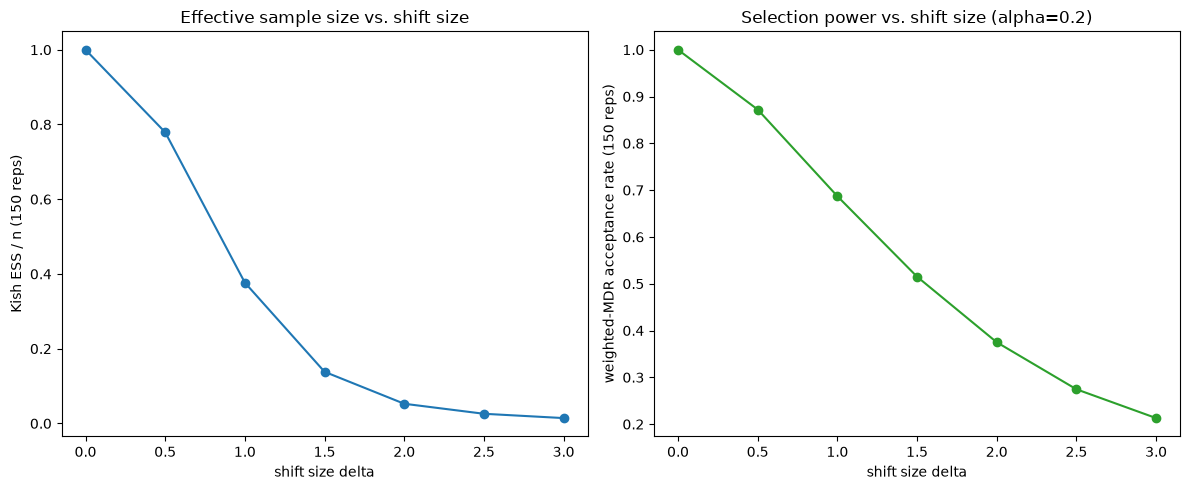

In [43]:
# Visualization only -- uses ess_by_delta / pow_by_delta computed above, no new simulation.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(DELTAS_S7D, ess_by_delta / N_CALIB_S7D, "o-", color=PALETTE["method_a"])
axes[0].set_xlabel("shift size delta"); axes[0].set_ylabel(f"Kish ESS / n ({REPS_S7D} reps)")
axes[0].set_title("Effective sample size vs. shift size")

axes[1].plot(DELTAS_S7D, pow_by_delta, "o-", color=PALETTE["method_b"])
axes[1].set_xlabel("shift size delta"); axes[1].set_ylabel(f"weighted-MDR acceptance rate ({REPS_S7D} reps)")
axes[1].set_title(f"Selection power vs. shift size (alpha={ALPHA_S7D})")

plt.tight_layout()
plt.show()

## 8. When weighting cannot help: concept shift and missing support (derived here, idpfin-q18 / idpshift-q4 flag the sources' silence)

§7 fixed the covariate shift correctly (known $w(x)$). This section asks the question none of the three
papers answer: what happens when the shift is **not** the kind weighting can fix?

**Quoted, idpfin-q18** — the cross-paper synthesis, verbatim on which guarantees survive which shift:

> "**Covariate Shift**: The marginal distribution of input features changes ... but the underlying
> conditional label distribution remains invariant ... **Concept Shift**: The conditional label
> distribution itself changes ... knowledge of feature weights $w(x)$ alone cannot predict target label
> risks." "SCoRE ... **Concept Shift**: **Does NOT survive.** SCoRE's covariate shift theory strictly
> requires $P_P(Y\mid X)=P_Q(Y\mid X)$ (Assumption 6.1) ... If $P(Y\mid X)$ changes, density ratios $w(x)$
> can no longer adjust e-values to guarantee $\mathbb E_Q[L_{n+j}E_{n+j}]\le 1$."
>
> 🚩 "None of the three sources state or provide diagnostic tests for checking whether the covariate-shift
> assumption ... holds prior to deployment" — there is no built-in alarm; a practitioner has to notice.

**Quoted, idpshift-q4** — the positivity requirement and its silence, and what naive clipping does:

> "The test covariate distribution $Q_X$ must be absolutely continuous with respect to the calibration
> covariate distribution $P_X$ ($Q_X\ll P_X$) ... This requires that any document feature pattern occurring
> in the new month must have a non-zero probability of appearing in historical calibration data." "Flexible
> classifiers ... can output class probabilities $\hat p(x)\approx1$ for unseen vendor layouts, causing
> infinite weights $\hat w(x)=\infty$ ... The estimated probabilities should be clipped to a bounded range
> (e.g., $[0.01,0.99]$)." 🚩 "If new vendor templates introduce feature regions $x$ where historical density
> is exactly zero ($P_X(x)=0\implies w(x)=\infty$), neither paper provides a mechanism to maintain coverage
> or FDR guarantees without dropping those samples."

We build two toys (both "derived here" — the papers are explicitly silent on both) reusing §7's DGP
(`w_s7`, `risk_prob_s7`, `G`, already in scope): **(a)** concept shift with the TRUE covariate weight still
applied; **(b)** positivity failure via a binary "new template" flag with zero calibration density.

In [44]:
# (a) Concept shift: SAME covariate shift as S7 (delta=1.0, TRUE w(x) applied correctly), but the loss's
# conditional law given x now CHANGES between calibration and test -- P(L|X) scales by a factor K at test
# time (e.g. a new document type where the same visual confidence signal now maps to more severe errors).
# Loss is continuous here (= the risk probability itself, no Bernoulli sampling) to make "loss scale
# increases for the same x" literal, per the brief.
ALPHA_S8A = 0.20
K_GRID_S8A = [1.0, 1.5, 2.0, 2.5]
N_CALIB_S8A = 1000
M_TEST_S8A = 300
REPS_S8A = 250

records_s8a = {K: [] for K in K_GRID_S8A}
rng_s8a = np.random.default_rng(RNG_SEED + 110)
for rep in range(REPS_S8A):
    Xc = rng_s8a.normal(0, 1, N_CALIB_S8A)
    Lc = risk_prob_s7(Xc)                       # calibration loss = true risk prob, no concept shift here
    Xt = rng_s8a.normal(DELTA_S7, 1, M_TEST_S8A)  # SAME covariate shift as S7
    cw = w_s7(Xc)
    tw = w_s7(Xt)                                # TRUE covariate weight -- correctly specified for X alone
    for K in K_GRID_S8A:
        Lt = np.clip(risk_prob_s7(Xt) * K, 0.0, 1.0)  # CONCEPT SHIFT: loss scaled by K for the SAME x
        psi_w = G.weighted_mdr_decision(Xc, Lc, cw, Xt, tw, ALPHA_S8A)
        records_s8a[K].append(np.mean(Lt * psi_w))

print(f"{'K (loss scale)':>15} {'weighted MDR risk':>18}")
idx8 = 1
for K in K_GRID_S8A:
    arr = np.array(records_s8a[K])
    tol = mc_tol_mean(arr)
    print(f"{K:>15.2f} {arr.mean():>18.4f}")
    if K == 1.0:
        check(f"S8.{idx8}", arr.mean() <= ALPHA_S8A + tol,
              f"K=1.0 (no concept shift) sanity: weighted MDR (TRUE covariate w) {arr.mean():.4f} <= {ALPHA_S8A} + MC tol {tol:.4f} "
              f"-- the weighting machinery itself is fine; S8 only breaks it via concept shift below")
    else:
        check(f"S8.{idx8}", arr.mean() > ALPHA_S8A + tol,
              f"K={K} (loss scaled by {K}x for the SAME x at test time) OVERSHOOTS despite the TRUE covariate weight: "
              f"{arr.mean():.4f} > {ALPHA_S8A} + MC tol {tol:.4f} -- weighting corrects for the X-shift exactly as in S7, "
              f"but has no way to know P(L|X) itself moved; Assumption 6.1 (idpfin-q13/q18) is violated by construction")
    idx8 += 1

 K (loss scale)  weighted MDR risk
           1.00             0.1984
[S8.1] K=1.0 (no concept shift) sanity: weighted MDR (TRUE covariate w) 0.1984 <= 0.2 + MC tol 0.0043 -- the weighting machinery itself is fine; S8 only breaks it via concept shift below -> PASS
           1.50             0.2762
[S8.2] K=1.5 (loss scaled by 1.5x for the SAME x at test time) OVERSHOOTS despite the TRUE covariate weight: 0.2762 > 0.2 + MC tol 0.0054 -- weighting corrects for the X-shift exactly as in S7, but has no way to know P(L|X) itself moved; Assumption 6.1 (idpfin-q13/q18) is violated by construction -> PASS
           2.00             0.3167
[S8.3] K=2.0 (loss scaled by 2.0x for the SAME x at test time) OVERSHOOTS despite the TRUE covariate weight: 0.3167 > 0.2 + MC tol 0.0057 -- weighting corrects for the X-shift exactly as in S7, but has no way to know P(L|X) itself moved; Assumption 6.1 (idpfin-q13/q18) is violated by construction -> PASS
           2.50             0.3439
[S8.4] K=2.5 (loss

**How to read this chart**

Realized weighted-MDR risk (y-axis) vs. the concept-shift multiplier $K$ (x-axis), with the $\alpha=0.20$
target line. At $K=1$ (pure covariate shift, identical to a slice of §7) the weighted procedure sits at the
target, exactly as §7 showed. As $K$ grows the line rises straight through the target and keeps climbing —
**using the exact, correctly-specified covariate weight does not help at all**, because the thing that
changed (the loss given $x$) is not the thing the weight corrects for (the marginal of $x$). This is the
literal content of Assumption 6.1's fine print: weighting is a covariate-shift remedy, not a general
distribution-shift remedy, and nothing in SCoRE (or cfBH, or Gurram — idpfin-q18) detects the difference
automatically.

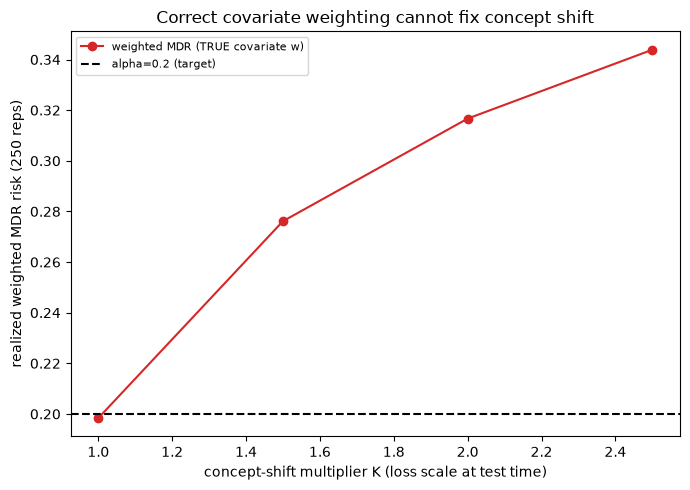

In [45]:
# Visualization only -- uses records_s8a computed above, no new simulation.
fig, ax = plt.subplots(figsize=(7, 5))
means_s8a = [np.mean(records_s8a[K]) for K in K_GRID_S8A]
ax.plot(K_GRID_S8A, means_s8a, "o-", color=PALETTE["invalid"], label="weighted MDR (TRUE covariate w)")
ax.axhline(ALPHA_S8A, color=PALETTE["target"], linestyle="--", label=f"alpha={ALPHA_S8A} (target)")
ax.set_xlabel("concept-shift multiplier K (loss scale at test time)")
ax.set_ylabel(f"realized weighted MDR risk ({REPS_S8A} reps)")
ax.set_title("Correct covariate weighting cannot fix concept shift")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [46]:
# (b) Positivity failure: a binary "new template" flag Z, Z=0 on EVERY calibration point, Z=1 on a fraction
# of test points -- the true density ratio w(x, Z=1) = dQ/dP(x,Z=1) is exactly undefined (0/0: calibration
# has ZERO mass at Z=1). New-template units carry a fixed high true risk (0.9, no calibration information
# exists about them at all). X itself is drawn identically regardless of Z, so the covariate shift is
# INVISIBLE unless Z is included as a modeled feature -- exactly the idpshift-q4 scenario (new vendor
# layout the classifier has never seen).
ALPHA_S8B = 0.20
N_CALIB_S8B = 1000
M_TEST_S8B = 300
FRAC_NEW_S8B = 0.15
REPS_S8B = 30
N_NEW_S8B = int(round(FRAC_NEW_S8B * M_TEST_S8B))
N_OLD_S8B = M_TEST_S8B - N_NEW_S8B

print(f"calibration points with Z=1 (new template): 0 out of {N_CALIB_S8B} -- "
      f"empirical density ratio at Z=1 is literally (test count)/(calib count=0) = UNDEFINED/INFINITE")

rng_s8b = np.random.default_rng(RNG_SEED + 111)
acc_scale, risk_scale, w_scale = [], [], []
acc_noscale, risk_noscale, w_noscale = [], [], []

for rep in range(REPS_S8B):
    Xc = rng_s8b.normal(0, 1, N_CALIB_S8B)
    Zc = np.zeros(N_CALIB_S8B)
    Lc = risk_prob_s7(Xc)
    Xt_old = rng_s8b.normal(0, 1, N_OLD_S8B)
    Zt_old = np.zeros(N_OLD_S8B)
    Lt_old = risk_prob_s7(Xt_old)
    Xt_new = rng_s8b.normal(0, 1, N_NEW_S8B)   # SAME X marginal as everyone else -- Z alone marks the new template
    Zt_new = np.ones(N_NEW_S8B)
    Lt_new = np.full(N_NEW_S8B, 0.9)           # fixed high risk, zero calibration information available
    Xt = np.concatenate([Xt_old, Xt_new])
    Zt = np.concatenate([Zt_old, Zt_new])
    Lt = np.concatenate([Lt_old, Lt_new])
    Fc = np.column_stack([Xc, Zc])
    Ft = np.column_stack([Xt, Zt])

    # Config 1 ("with-scale"): G.domain_classifier_weights' default LR pipeline (StandardScaler + LogisticRegression).
    w_src1, w_tgt1 = G.domain_classifier_weights(Fc, Ft, model="lr", seed=rep)
    psi1 = G.weighted_mdr_decision(Xc, Lc, w_src1, Xt, w_tgt1, ALPHA_S8B)
    acc_scale.append(psi1[Zt == 1].mean())
    risk_scale.append(np.mean(Lt[Zt == 1] * psi1[Zt == 1]))
    w_scale.append(w_tgt1[Zt == 1].mean())

    # Config 2 ("no-scale"): an equally defensible manual cross-fit, WITHOUT feature standardization --
    # a mundane preprocessing choice with no principled connection to the (undefined) true weight.
    Nall = N_CALIB_S8B + M_TEST_S8B
    Xall = np.vstack([Fc, Ft])
    y_all = np.r_[np.zeros(N_CALIB_S8B), np.ones(M_TEST_S8B)]
    kf = KFold(n_splits=5, shuffle=True, random_state=rep)
    p_hat = np.zeros(Nall)
    for tr_idx, te_idx in kf.split(Xall):
        clf = LogisticRegression().fit(Xall[tr_idx], y_all[tr_idx])
        p_hat[te_idx] = clf.predict_proba(Xall[te_idx])[:, 1]
    p_hat = np.clip(p_hat, 0.01, 0.99)
    odds = p_hat / (1.0 - p_hat)
    w_all = odds * (N_CALIB_S8B / M_TEST_S8B)
    w_src2, w_tgt2 = w_all[:N_CALIB_S8B], w_all[N_CALIB_S8B:]
    scale2 = 1.0 / np.mean(w_src2)
    w_src2, w_tgt2 = w_src2 * scale2, w_tgt2 * scale2
    psi2 = G.weighted_mdr_decision(Xc, Lc, w_src2, Xt, w_tgt2, ALPHA_S8B)
    acc_noscale.append(psi2[Zt == 1].mean())
    risk_noscale.append(np.mean(Lt[Zt == 1] * psi2[Zt == 1]))
    w_noscale.append(w_tgt2[Zt == 1].mean())

acc_scale, risk_scale, w_scale = map(np.array, (acc_scale, risk_scale, w_scale))
acc_noscale, risk_noscale, w_noscale = map(np.array, (acc_noscale, risk_noscale, w_noscale))

print(f"{'config':>28} {'w_hat(Z=1)':>12} {'accept_rate':>12} {'risk(Z=1 subgrp)':>18}")
print(f"{'with-scale (StandardScaler)':>28} {w_scale.mean():>12.2f} {acc_scale.mean():>12.3f} {risk_scale.mean():>18.4f}")
print(f"{'no-scale (raw features)':>28} {w_noscale.mean():>12.2f} {acc_noscale.mean():>12.3f} {risk_noscale.mean():>18.4f}")

tol_r_scale = mc_tol_mean(risk_scale)
tol_r_noscale = mc_tol_mean(risk_noscale)
check(f"S8.{idx8}", risk_scale.mean() <= ALPHA_S8B + tol_r_scale,
      f"with-scale config stays SAFE on the Z=1 subgroup ({risk_scale.mean():.4f} <= {ALPHA_S8B} + MC tol {tol_r_scale:.4f}) "
      f"-- but only because it accepts essentially NONE of it (accept rate {acc_scale.mean():.3f}): safety here is "
      f"degenerate, not a real guarantee (no automation for that vendor at all)")
idx8 += 1
check(f"S8.{idx8}", risk_noscale.mean() > ALPHA_S8B + tol_r_noscale,
      f"no-scale config VIOLATES on the Z=1 subgroup: realized risk {risk_noscale.mean():.4f} > {ALPHA_S8B} + MC tol "
      f"{tol_r_noscale:.4f} (accept rate {acc_noscale.mean():.3f}) -- an equally 'reasonable' modeling choice silently "
      f"accepts the new-template units at their true 0.9 risk, ~{risk_noscale.mean() / ALPHA_S8B:.1f}x the budget")
idx8 += 1
ratio_w = max(w_scale.mean(), w_noscale.mean()) / min(w_scale.mean(), w_noscale.mean())
check(f"S8.{idx8}", ratio_w > 5.0,
      f"the two configs' estimated weight for the SAME Z=1 units differs by {ratio_w:.1f}x ({w_scale.mean():.1f} vs "
      f"{w_noscale.mean():.1f}) purely from a feature-scaling choice unrelated to the true (undefined/infinite) "
      f"density ratio -- naive clipping restores A number, not a guarantee: nothing in the data tells you which "
      f"number, if either, is safe to trust")
idx8 += 1

calibration points with Z=1 (new template): 0 out of 1000 -- empirical density ratio at Z=1 is literally (test count)/(calib count=0) = UNDEFINED/INFINITE


                      config   w_hat(Z=1)  accept_rate   risk(Z=1 subgrp)
 with-scale (StandardScaler)       386.58        0.000             0.0000
     no-scale (raw features)        34.42        0.990             0.8913
[S8.5] with-scale config stays SAFE on the Z=1 subgroup (0.0000 <= 0.2 + MC tol 0.0000) -- but only because it accepts essentially NONE of it (accept rate 0.000): safety here is degenerate, not a real guarantee (no automation for that vendor at all) -> PASS
[S8.6] no-scale config VIOLATES on the Z=1 subgroup: realized risk 0.8913 > 0.2 + MC tol 0.0085 (accept rate 0.990) -- an equally 'reasonable' modeling choice silently accepts the new-template units at their true 0.9 risk, ~4.5x the budget -> PASS
[S8.7] the two configs' estimated weight for the SAME Z=1 units differs by 11.2x (386.6 vs 34.4) purely from a feature-scaling choice unrelated to the true (undefined/infinite) density ratio -- naive clipping restores A number, not a guarantee: nothing in the data tells y

**How to read this chart**

Two grouped bars, one pair per weight-estimation config (identical data, identical `weighted_mdr_decision`
call — the ONLY difference is whether the classifier's input features were standardized before fitting).
Left group: acceptance rate on the new-template (Z=1) subgroup — near 0 for "with-scale" (it refuses to
automate that vendor at all), near 1 for "no-scale". Right group: realized risk on that same subgroup
against the $\alpha=0.20$ target — "with-scale" sits at 0 (safe, but only because it accepts nothing),
"no-scale" sits far above the line (a real violation, since every accepted unit carries the true 0.9 risk).
Both configs are ordinary, defensible preprocessing choices; neither has any way to know it is right, because
the quantity being estimated (a density ratio against zero calibration mass) does not exist. **A number
came out of the computer either way — only one of the two "guarantees" is real, and nothing in this
notebook's toolkit (or the papers') can tell you which one without calibration data that, by construction,
cannot exist.**

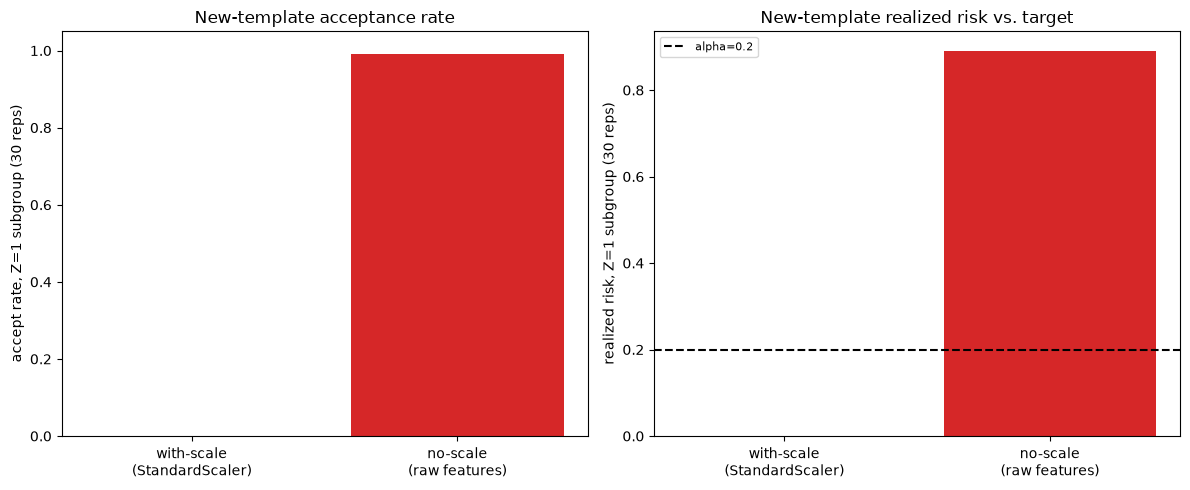

In [47]:
# Visualization only -- uses acc_scale / risk_scale / acc_noscale / risk_noscale computed above.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
configs = ["with-scale\n(StandardScaler)", "no-scale\n(raw features)"]

axes[0].bar(configs, [acc_scale.mean(), acc_noscale.mean()], color=[PALETTE["conservative"], PALETTE["invalid"]])
axes[0].set_ylabel(f"accept rate, Z=1 subgroup ({REPS_S8B} reps)")
axes[0].set_title("New-template acceptance rate")
axes[0].set_ylim(0, 1.05)

axes[1].bar(configs, [risk_scale.mean(), risk_noscale.mean()], color=[PALETTE["conservative"], PALETTE["invalid"]])
axes[1].axhline(ALPHA_S8B, color=PALETTE["target"], linestyle="--", label=f"alpha={ALPHA_S8B}")
axes[1].set_ylabel(f"realized risk, Z=1 subgroup ({REPS_S8B} reps)")
axes[1].set_title("New-template realized risk vs. target")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9. Closing: measure → certify → make it hold on documents — now including shift

**Four escalating stories, one queue.** **cfBH** (§1) *selects*: given per-field scores, control the
expected fraction of wrongly auto-accepted fields via conformal p-values and BH. **SCoRE** (§2–§3, §6, §6b)
*generalizes the risk*: a bounded continuous loss controlled in expectation via e-values, as a marginal
budget (MDR) or a true selective rate (SDR, which collapses onto cfBH when the loss is binary), reproduced
with a continuous outcome (§6, a real clip-vs-residual power gap this time) and with the sharper
label-conditional guarantee of cfBH0 (§6b). **Gurram** (§4–§5) *makes it hold on documents*: clustering
inflates variance and violation rate, a leaked score overshoots its budget, a coarse score can certify
nothing at all, and PAC tiers trade auto-accept volume for a probability statement about the specific batch
in front of you. **Weighted SCoRE / WCS** (§7–§8) *makes it hold after the population moves*: known
covariate-shift weights restore every one of SCoRE's and cfBH's guarantees exactly (§7) — but only for
covariate shift; concept shift and positivity failure defeat weighting entirely, with no built-in alarm
(§8).

**What each guarantee promises for an auto-accept queue, and what it does not (§0's table, now earned):**

| guarantee | promise | does NOT promise |
| --- | --- | --- |
| cfBH FDR | E[FDP] <= q, on average over calibration+test draws | Nothing about THIS batch; nothing about non-binary cost |
| cfBH0 (§6b) | E[FDP \| {Y_(n+j)}] <= q, conditional on the REALIZED test labels | Higher power than cfBH (cfBH is always a superset, §6b) |
| SCoRE MDR | E[L*psi] <= alpha, a marginal BUDGET | That any accepted item individually has low risk (S0/S2) |
| SCoRE SDR | E[selective risk] <= alpha, on average | Same average-vs-this-run gap as cfBH |
| Gurram Tiers 1-2 | E[selective risk] <= alpha, on average, at the field unit (still holds under clustering in our S4.2 toy) | A low PER-BATCH violation frequency: S4/Table 4 both show high viol despite E[risk] <= alpha holding |
| Gurram Tier 3 (Mondrian LTT) | P(group risk > alpha) <= delta, a real certificate, PROVEN under field-iid | Nothing, by proof, once fields are not iid; though S5.2 found it stayed valid empirically at our clustering strength/sample size (not a general guarantee) |
| Gurram Tier 4 (doc-Hoeffding) | P(macro doc risk > alpha) <= delta, matches the real DGP | Powerful certificates: the paper calls it 'honest but near-vacuous' at realistic sample sizes (idpfin-q9) |
| Weighted MDR/SDR, KNOWN w (§7) | E_Q[L*psi] <= alpha (MDR) / E_Q[selective risk] <= alpha (SDR), FINITE-SAMPLE, under Q, Thm 6.2/6.3 | Anything once w is only ESTIMATED (that drops to asymptotic, Thm 6.4/6.5) or once P(Y\|X) itself shifts (§8a) |
| Weighted MDR/SDR, ESTIMATED w | limsup MDR_n <= alpha / limsup SDR_n,m <= alpha, ASYMPTOTIC, requires L2(P_X)-consistent w-hat trained independently (Thm 6.4/6.5) | Finite-sample control; doubly-robust asymptotic control needs the A.3/A.5 balancing condition on top |
| WCS (hete/homo/dtm) / WBH, KNOWN w (§7c) | E[FDP] <= q, FINITE-SAMPLE, Thm 3.1 | Under estimated w: FDR <= q * E[gamma-hat^2 / (1+q(gamma-hat^2-1)/m)] (idpshift-q1), gamma-hat = sup_x max(w-hat/w, w/w-hat) -- an INFLATION bound, not exact q, and -> infinity as w-hat becomes unbounded (§8b) |

**Explicit "derived here" list (nothing here is in the three papers, or the two shift papers):** the
binary/continuous toy DGPs in §1–§3 and §6; the document/field clustering simulator (§4–§5); the
cluster-robust vs. field-level bootstrap and the ANOVA plug-in design-effect estimator (§4/§5); the exact
breakpoint algorithm for SCoRE-MDR's infimum over $\ell$ (§2); the brute-force exact infimum for SCoRE-SDR
(§3); the Hoeffding-based Tier 4 statistic and geometric-candidate Mondrian LTT code (§5); the entire
guarantee-zoo schematic (§0); the exact Beta-conditional sampler for cfBH0's label-conditional check (§6b);
the log-normal covariate-shift toy, its steep-sigmoid risk function, and the entire ESS/power-vs-delta sweep
(§7 — SCoRE states the weighted e-values but not this toy; Kish ESS is from Tibshirani et al., not SCoRE);
the concept-shift multiplier $K$ and the positivity-failure "new template" flag, including BOTH weight-
estimation configs used to show the naive-clipping instability (§8 — idpfin-q18 and idpshift-q4 flag these
exact gaps as silent in all sources). Every quoted number from a paper carries its `idpfin-qN` or
`idpshift-qN` slug; every other number in this notebook came out of a `rng = np.random.default_rng(...)`
call above it.

**What this notebook is not.** It never touches a real document, a real LLM call, or a real business-rule
validator — by design (brief: no LLM calls in Notebook 1). It does not resolve every open problem the
papers themselves flag: cost-weighted (monetary) losses do not fit cfBH or Gurram's Tier-3 binomial
machinery at all (contract rule 4, idpfin-q11); noisy calibration labels are outside all three papers'
scope (Gurram's own audit found automatic labels "one-sidedly pessimistic," idpfin-q9); and, now that §7–§8
exist, distribution shift after deployment is only *partly* solved — covariate shift with known or
consistently-estimated weights (§7) has a real, finite-sample or asymptotic answer, but concept shift and
positivity failure (§8) do not, and no source gives a diagnostic for telling the two apart in advance
(idpfin-q18's explicit flag).

**Hand-off.** Notebook 2 builds a synthetic fintech document corpus (invoices, bank statements, KYC
forms, compliance reports) and a pipeline replica — classification, LLM field extraction, business-rule
validation — instrumented so every field carries a confidence signal like the ones §4's toy DGP stood in
for. Notebook 3 applies exactly the machinery built here to that corpus: cfBH or SCoRE at the *document*
unit (the safe default per the contract's exchangeability rule 2), an amount-weighted SCoRE loss for the
monetary fields, and the Mondrian LTT validity ladder split by document type — reporting, honestly, which
tier the corpus and sample size can actually support. Notebook 3 §7b applies §7–§8's weighted machinery
specifically to the corpus's month-7 vendor shift: known/estimated covariate weights where the shift is
genuinely covariate-only, and an honest admission of positivity failure or concept shift where it is not.